# Taylor-based Explainer - v1.2

In [1]:
import sys

In [ ]:
!{sys.executable} -m pip install xgboost
#!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install nbimporter
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install captum
!{sys.executable} -m pip install shap

#!git clone https://github.com/AI4LIFE-GROUP/OpenXAI.git
!{sys.executable} -m pip install -e OpenXAI

In [3]:
import time
import numpy as np
import pandas as pd
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.sparse.linalg import eigs

import xgboost as xgb
#from catboost import CatBoostClassifier

import lime
import lime.lime_tabular

import shap
shap.initjs()

# Data preprocessing methods

In [4]:
# save a pd.DataFrame dataset in a csv file

def save_dataset(df, file_name='SVD_synth_data.csv'):

    lines= df.shape[0]
    colls= df.shape[1]

    f= open(file_name, 'w')

    line= str(df.columns[0])

    for i in range((colls-1)):
        line= line+','+str(df.columns[(i+1)])

    line= line+'\n'
    f.write(line)

    df_array= np.asarray(df)
    line= str(df.columns[0])

    for i in range(lines):
        elements= df_array[i]
        line= str(elements[0])

        for j in range((colls-1)):
            line= line+','+str(elements[(j+1)])

        line= line+'\n'
        f.write(line)

    f.close()

In [21]:
# receive numerical features: fill nan's with median/mean/mode/zeros
# num_cols list indicating the columns names from df are numerical
# num_type defines the fill type - mode/mean/median/zeros

# RETURN df without nan's on num_cols

def pre_proc_fillna_num_fts(df, num_cols, num_type='mean'):
    df_train= df.copy()

    if(num_type=='median'):
        for col in num_cols:
            ft_median= df_train[col].median()
            df_train[col]= df_train[col].fillna(ft_median)
    elif(num_type=='mode'):
        for col in num_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)
    elif(num_type=='zeros'):
        for col in num_cols:
            ft_zero= 0
            df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in num_cols:
            ft_mean= df_train[col].mean()
            df_train[col]= df_train[col].fillna(ft_mean)

    return df_train

In [22]:
# receive categorical features: fill nan's with mode/mean/median/zeros
# cat_cols list indicating the columns names from df are numerical
# cat_type defines the fill type - mode/mean/median/zeros

# RETURN df without nan's on cat_cols

def pre_proc_fillna_cat_fts(df, cat_cols, cat_type='mode'):
    df_train= df.copy()
    
    if(cat_type!='mode' and type(df_train[cat_cols[0]].value_counts().index[0])!=type('str')):
        if(cat_type=='mean'):
            for col in cat_cols:
                ft_mean= df_train[col].mean()
                df_train[col]= df_train[col].fillna(ft_mean)
        elif(cat_type=='median'):
            for col in cat_cols:
                ft_median= df_train[col].median()
                df_train[col]= df_train[col].fillna(ft_median)
        elif(cat_type=='zeros'):
            for col in num_cols:
                ft_zero= 0
                df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in cat_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)

    return df_train

In [23]:
# selected_cols list refering only to df's columns with values to be normalized
# if selected_cols is not defined as argument, all df columns will be normalized

# RETURN df with selected_cols normalized

def normalize_selected(df, selected_cols=[]):
    result= df.copy()
    
    if (len(selected_cols)== 0):
        selected_cols= df.columns
    
    for col in selected_cols:
        max_value= df[col].max()
        min_value= df[col].min()
        result[col]= (df[col]- min_value)/ (max_value - min_value)
        
    return result

In [5]:
# return a DataFrame with replaced values (mean/median/mode/zeros/none to categorical and numeric) 
# to fill train cols. df is post-processed (cat_cols encoded)

def replace_values(df,num_cols,num_type='mean',cat_type='none'):
    cat_values= None
    num_values= None
    
    if (cat_type=='mean'):
        cat_values= df.mean(axis=0).to_frame().T
    elif (cat_type=='median'):
        cat_values= df.median(axis=0).to_frame().T
    elif (cat_type=='mode'):
        cat_values= df.mode(axis=0)
    elif (cat_type=='zeros'):
        cat_values= df.loc[0:0,:].copy()
        cat_values.loc[:,:]= 0
    
    if (num_type=='mode'):
        num_values= df.mode(axis=0)
    elif (num_type=='median'):
        num_values= df.median(axis=0).to_frame().T
    elif (num_type=='mean'):
        num_values= df.mean(axis=0).to_frame().T
    elif (num_type=='zeros'):
        num_values= df.loc[0:0,:].copy()
        num_values.loc[:,:]= 0

    if(cat_type!='none'):
        cat_values[num_cols]= num_values[num_cols]
        return cat_values
    
    return num_values

In [137]:
# check for null values on a DataFrame
# text_info True returns a textual message about the null checking

# RETURN True if there are some missing values in df or False if there are no missing values in df

def check_null_values(df, text_info=False):

    null_values= df.isnull().values.any()
    
    if not text_info:
        return null_values

    if (null_values == True):
        print("There are some missing values in the dataset")
    else:
        print("There are no missing values in the dataset")

In [140]:
from sklearn.preprocessing import MinMaxScaler

# df contains categorical features previously one-hot-encoded
# cat_cols list indicating the categorical columns 
# delta is the displacement parameter to simulate real-valued features to OHE categorical features

# RETURN df with the cat_cols perturbed to +/- delta

def ohe_cat_to_numetical_simulator(df, cat_cols, delta=0.5):
    
    if (delta>= 1 or delta<= 0):
        raise ValueError("delta parameter should be a value between (0,1) !")
        
    n_instances= df.shape[0]
    n_cat_att= np.asarray(cat_cols).shape[0]
    
    num_df= df.copy()
    
    np.random.seed(0)
    # random.rand return random floats in the half-open interval [0.0, 1.0)
    # we use (b - a) * random_sample() + a, b > a, to get [a, b) in which a= -delta and b=delta
    # in order to get [-delta, delta) range
    replace= (delta - (-delta)) * np.random.random_sample(n_instances) + (-delta)
    
    # using a scaler to get [-delta, delta] range
    #replace= np.random.random_sample(n_instances)
    #scaler= MinMaxScaler(feature_range=(-delta, delta))
    #replace= (scaler.fit_transform(replace.reshape(-1, 1))).ravel()
    
    for i in range(n_instances):
        for j in range(n_cat_att):
            
            # if zero, keep the zero as value. if 1, replace by 1 + rand([-delta, delta])
            num_df[cat_cols[j]].iloc[i]= num_df[cat_cols[j]].iloc[i] * (1 + replace[i])
        
        
    return num_df

# Synthetic data loading and preprocessing. Model trainings

In [6]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

In [7]:
#save_dataset(synth, 'datasets/SVD_Exp_synth_data.csv')
synth= pd.read_csv('datasets/SVD_Exp_synth_data.csv')

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.297434,1.480258,-1.047823,-1.235156
1,-2.255077,1.190942,-0.573914,-3.008057
2,-3.336307,3.258936,-0.030324,-0.361786
3,0.672172,1.928683,-0.456206,-3.051892
4,-1.106266,3.345063,-3.481175,-1.105859


In [8]:
print(np.round(synth.memory_usage().sum() / 10**6, 2), "MB")

0.04 MB


In [9]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

# All dataset is numeric
scaler= MinMaxScaler(feature_range=(0, 1))
norm_x_syn= scaler.fit_transform(np.asarray(x_syn))
norm_x_syn= pd.DataFrame(norm_x_syn, columns=x_syn.columns)

norm_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.425977,0.626863,0.368465,0.345838
1,0.359321,0.603430,0.427822,0.123927
2,0.284062,0.770929,0.495906,0.455156
3,0.563072,0.663184,0.442565,0.118440
4,0.439284,0.777905,0.063690,0.362022


In [10]:
# Standarization
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler().fit(np.asarray(x_syn))
# realiza a padronização (média= 0, variância= 1)
stand_x_syn= scaler.transform(np.asarray(x_syn))
stand_x_syn= pd.DataFrame(stand_x_syn, columns=x_syn.columns)

stand_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-0.103626,0.267269,-0.428075,-0.498028
1,-0.577271,0.116797,-0.225488,-1.265198
2,-1.112041,1.192347,0.006886,-0.120102
3,0.870530,0.500491,-0.175170,-1.284166
4,-0.009076,1.237141,-1.468284,-0.442078


In [11]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(norm_x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

In [12]:
# the instance to be explained (from train dataset)

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
255,0.473301,0.653833,0.871313,0.940102


In [13]:
# Set and train a ML model

xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 0.1,
                               subsample= 0.9,
                               objective= 'binary:logistic',
                               eval_metric='logloss')

eval_set= [(train, labels_train), (test, labels_test)]

xgb_model.fit(train, labels_train, eval_set=eval_set, verbose=False)

acc_all= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_all

0.96

In [14]:
target_labl

,target
255,1.0


In [15]:
xgb_model.predict_proba(target_inst)

array([[0.49500138, 0.5049986 ]], dtype=float32)

In [16]:
# Categorical data

cat_synth= syn.cat_synthetic_data_generator(n=500,p=0.9,df=True)
cat_synth

,cat_core_1,cat_core_2,cat_core_3,noise_1,noise_2,target
0,1.0,0.0,0.0,2.908204,1.918252,1.0
1,1.0,0.0,0.0,-2.011894,-0.135504,1.0
2,1.0,0.0,0.0,-2.701053,-1.940017,1.0
3,1.0,0.0,0.0,-1.417021,-3.166413,1.0
4,1.0,0.0,0.0,2.773405,-2.795072,1.0
...,...,...,...,...,...,...
995,0.0,1.0,0.0,3.997092,2.193652,1.0
996,0.0,0.0,1.0,0.016295,1.137450,1.0
997,0.0,0.0,1.0,-3.865462,-3.809538,1.0
998,0.0,0.0,1.0,-3.796335,3.103531,1.0


In [19]:
#save_dataset(cat_synth, 'datasets/texp_cat_synth_data.csv')
cat_synth= pd.read_csv('datasets/texp_cat_synth_data.csv')

# split synth into features (x) and target (y)
x_cat_syn= cat_synth.loc[:,cat_synth.columns[0:5]]
y_cat_syn= cat_synth.loc[:,cat_synth.columns[5:6]]

x_cat_syn.head()

,cat_core_1,cat_core_2,cat_core_3,noise_1,noise_2
0,1.0,0.0,0.0,2.908204,1.918252
1,1.0,0.0,0.0,-2.011894,-0.135504
2,1.0,0.0,0.0,-2.701053,-1.940017
3,1.0,0.0,0.0,-1.417021,-3.166413
4,1.0,0.0,0.0,2.773405,-2.795072


In [24]:
numeric_columns= ['noise_1','noise_2']
categor_columns= list(filter(lambda x:x not in numeric_columns,x_cat_syn.columns))

categor_columns

['cat_core_1', 'cat_core_2', 'cat_core_3']

In [144]:
# normalize the numeric columns of the dataframe with each value between 0 and 1

norm_x_cat_syn= normalize_selected(x_cat_syn, numeric_columns)

norm_x_cat_syn.head()

,cat_core_1,cat_core_2,cat_core_3,noise_1,noise_2
0,1.0,0.0,0.0,0.863816,0.739845
1,1.0,0.0,0.0,0.248474,0.482727
2,1.0,0.0,0.0,0.162283,0.256813
3,1.0,0.0,0.0,0.322873,0.103276
4,1.0,0.0,0.0,0.846957,0.149766


In [143]:
norm_x_cat_syn_numsim= ohe_cat_to_numetical_simulator(norm_x_cat_syn, categor_columns, delta=0.5)

norm_x_cat_syn_numsim

,cat_core_1,cat_core_2,cat_core_3,noise_1,noise_2
0,1.048814,0.000000,0.000000,0.863816,0.739845
1,1.215189,0.000000,0.000000,0.248474,0.482727
2,1.102763,0.000000,0.000000,0.162283,0.256813
3,1.044883,0.000000,0.000000,0.322873,0.103276
4,0.923655,0.000000,0.000000,0.846957,0.149766
...,...,...,...,...,...
995,0.000000,0.597676,0.000000,1.000000,0.774323
996,0.000000,0.000000,1.014922,0.502134,0.642093
997,0.000000,0.000000,1.438412,0.016654,0.022761
998,0.000000,0.000000,0.728647,0.025300,0.888235


# Explainers Auxiliar Methods

In [16]:
# convert probabilities to log odds
# eps is a small positive value to prevent division by zero

def pred_proba_to_log_odds(p, eps=1e-9):
    
    p_clipped= np.clip(p, eps, 1-eps)
    
    return np.log(p_clipped/(1-p_clipped))

In [192]:
pred_proba_to_log_odds(np.asarray([[1.00000000e+00, 9.02727073e-23]]))

array([[ 20.72326586, -20.72326584]])

In [17]:
# convert log odds values to predicted classes in a binary classification problem

def log_odds_to_binary_class(lodds):
    
    p= np.exp(lodds) / (1 + np.exp(lodds))
    
    return 0 if (p< 0.5) else 1

In [18]:
pred_test= xgb_model.predict(target_inst)

print(pred_test)
print(log_odds_to_binary_class(pred_test))

[1]
1


In [19]:
# get the mean predicted probability, considering the informed class labels
# receive x_data dataset and y_data label dataset

# RETURN the mean predicted probability of x_data belonging to the y_data class

def get_avg_pred_proba(model, x_data, y_data):
    
    p_x= model.predict_proba(x_data)
        
    assert len(y_data)== len(p_x), "Same size parameters expected to x and y"
    
    tam= len(p_x)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[i][y_data[i]]
        
    avg_pred= pred/ tam

    return pred_proba_to_log_odds(avg_pred)

In [20]:
# Expected value can be understood as the average model output across the training set, and the true labels
# SHAP paper mention a dataset "would be predicted if we did not know any features"

# The 'absence of features' or better 'not knowing the feature' needs to be defined/considered carefully. 
# In the context of SHAP it doesn't meant that Xi=0 but it means that we do not know the value of Xi
# but we still may know the distribution of potential values of Xi or we could estimate this distribution 
# based on the data, in practice, a mean value is considered, and then, we average over this predicted 
# probs to each label.

# Receive one instance x_mean from train dataset mean and y_train, the entire labels_train

# RETURN the mean probability of x_mean belonging to the in y_train classes

def expected_value_x_mean(model, x_mean, y_train):
    
    # Expected value over the mean from train data
    p_x= model.predict_proba(x_mean)

    tam= len(y_train)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[0][y_train[i].astype(int)]
        
    avg_pred= pred/ tam
    
    return pred_proba_to_log_odds(avg_pred)

In [23]:
expected_value_x_mean(xgb_model, replace_values(train,4), labels_train.values.ravel())

-0.00019730567996119994

In [21]:
# data is the training dataset and labels is the labels dataset
# RETURN n, the number of features in data
#        m, the number of unique classes in labels

def get_n_m_sizes(data, labels):
    
    n= data.shape[1]
    
    m= np.asarray(labels.nunique())[0]
    
    return n, m

In [20]:
get_n_m_sizes(train, labels_train)

(4, 2)

In [22]:
from scipy.spatial import distance_matrix

# data is a Pandas DataFrame -- model's training data

# RETURN the minimum Euclidean distance value among all the data instances

def get_minimum_distance(data):
    
    mtx_data= np.asarray(data)
    
    mtx_dist= distance_matrix(mtx_data, mtx_data, p=2)
    
    mtx_dist= mtx_dist + np.identity(data.shape[0])
    
    return np.min(mtx_dist)

In [50]:
get_minimum_distance(train)

0.02529567635543857

In [23]:
# normalize a numpy.ndarray into a 0-1 range
# x: numpy.ndarray

# RETURN a normalized numpy.ndarray

def normalize(x):
    
    normalized= (x- np.min(x))/ (np.max(x)- np.min(x))
        
    return normalized

In [24]:
from numpy.linalg import matrix_rank

# a singular matrix refers to a matrix whose determinant is zero furthermore, such a matrix has no inverse
# if the matrix M is m x n, assume wlog, that m ≤ n, and compute all determinants of m by m submatrices.
# if one of them is non-zero, the matrix has full-rank 

# M is a numpy.ndarray m x n matrix

# RETURN TRUE if M is singular

def singular_matrix(M):
    
    if not (np.linalg.cond(M) < 1/sys.float_info.epsilon):
        return True
                                # a non-square matrix is called "full-rank" instead of "nonsingular" or
    m, n= M.shape               # "invertible" and "rank-deficient" when the square equivalent is "singular".
                                # any m x n matrix M with real coefficients can be characterized by so-called
    if (n!=m):                  # "singular values" which number j=min{m,n} correspond to the eigenvalues of
                                # S, where S ∈ R^{j x j} is the smallest in size between M∗ M ∈ R^{m x m} and
        j= np.min([m,n])        # MM∗ ∈ R^{n x n}. a singular value σ and an eigenvalue λ are related by
                                # σ=√λ after noting that the eigenvalues of S are all nonnegative real numbers,
        if (matrix_rank(M)< j): # because it is positive semidefinite (i.e., v∗Sv≥0 for any v). It is now an
            return True         # exercise to show that if rank(M)<j (i.e., M is rank-deficient) if and only
                                # if S has 0 as eigenvalue (i.e., S is singular) to which corresponds a 0
    return False                # singular value of M

In [24]:
A= np.asarray([[2, 32, 12],
               [0, 0, 0],
               [23, 6, 9]])

print(singular_matrix(A))

B= np.asarray([[3, 4, 18],
               [9, 18, 1],
               [2, 3, 5]])

print(singular_matrix(B))

C= np.asarray([[2, 32, 12, 18],
               [0, 0, 0, 0],
               [23, 6, 9, 5]])

print(singular_matrix(C))

D= np.asarray([[3, 4, 18, 0],
               [9, 18, 1, 0],
               [2, 3, 5, 0]])

print(singular_matrix(D))

True
False
True
False


In [25]:
# x is a n-dimensional data instance in pandas DataFrame format
# h is the magnitude of the neighborhood perturbation

# RETURN a dataset (np.ndarray) with n instances and n features per instance, such that
#        the instance i will be x perturbed by h in the feature i

def perturb_neighborhood(x, h=1e-4):
    
    x_np= np.asarray(x).flatten()

    size= len(x_np)

    pert_ds= []

    for i in range(size):
        pert= np.zeros(size)
        pert[i]= h

        pert_ds.append((x_np + pert))

    pert_ds= np.asarray(pert_ds)

    return pert_ds

In [28]:
perturb_neighborhood(target_inst, 1)

array([[1.47330104, 0.65383311, 0.87131331, 0.94010178],
       [0.47330104, 1.65383311, 0.87131331, 0.94010178],
       [0.47330104, 0.65383311, 1.87131331, 0.94010178],
       [0.47330104, 0.65383311, 0.87131331, 1.94010178]])

In [26]:
from sklearn.neighbors import NearestNeighbors

# find the size nearest neighbors from a x instance

# data is a n-dimensional dataset in pandas DataFrame format (train set) 
# x is a n-dimensional data instance in pandas DataFrame format (x is in data)
# size is number of nearest elements to be returned

# RETURN a size elements datset (np.ndarray) based on knn from x and the each element distance from x

def knn_neighborhood(data, x, size:int=7):
    
    if (size>= data.shape[0]):
        raise ValueError("size parameter cannot be greater than data size!")
    
    knn= NearestNeighbors(n_neighbors= size+1) # x is an instance of data
    knn.fit(np.asarray(data))
    
    knn_index= knn.kneighbors(np.asarray(x), return_distance=True)
    
    dists= knn_index[0][:,1:size+1]
    
    knn_index= knn_index[1][:,1:size+1]        # remove x from the neighbors list
    
    x_neighborhood= data.loc[data.index[knn_index[0]]]

    return np.asarray(x_neighborhood), dists

In [631]:
near_elements= knn_neighborhood(train, target_inst, size=5)

near_elements

(array([[0.53459938, 0.62732243, 0.91062923, 0.98601456],
        [0.45209397, 0.7216623 , 0.92884036, 0.97612273],
        [0.5494448 , 0.59445987, 0.83503333, 0.93100176],
        [0.4186854 , 0.68149252, 0.96939266, 0.92207686],
        [0.41280023, 0.64249563, 0.92596313, 0.85177681]]),
 array([[0.09007789, 0.09827212, 0.10354758, 0.11701439, 0.12073438]]))

In [27]:
# clip values near to zero in v replacing by eps

# v is a single value (float) or a numpy.ndarray with (n,) shape
# eps is a small number of tolerance limiting what is a small value

# RETURN v clipped

def clip_small_values(v, eps=1e-6):
    
    v_aux= v.copy()
    
    if (type(v_aux)== np.ndarray):
        elements= v_aux.shape[0]

        for i in range(elements):

            if (v_aux[i]< 0 and np.abs(v_aux[i])< eps):
                v_aux[i]= -eps
            elif (v_aux[i]> 0 and v_aux[i]< eps):
                v_aux[i]= eps
    else:
        if (v_aux< 0 and np.abs(v_aux)< eps):
            v_aux[i]= -eps
        elif (v_aux> 0 and v_aux< eps):
            v_aux= eps
                        
    return v_aux

In [30]:
clip_small_values(np.asarray([6.01780e-05, 3.99814e-03, -2.60157e-18, -2.60500e-18]))

array([ 6.01780e-05,  3.99814e-03, -1.00000e-06, -1.00000e-06])

In [28]:
# returns the square of the difference of any two quantities v1 and v2.

def square_difference(v1, v2):
    
    # arrays can be flattened, so long as ordering is preserved
    v1_flat= np.asarray(v1).flatten()
    v2_flat= np.asarray(v2).flatten()
    
    dif_flat= (v1_flat - v2_flat)
    
    return np.power(dif_flat, 2)

In [29]:
# returns the Lp norm of the difference between v1 and v2.
# normalizes the difference between v1 and v2 by v1 (adapted; Agarwal, Chirag, et al., 2022)

def lp_norm_dif(v1, v2, p_norm=2, eps=1e-6, norm:bool=True):
    
    # arrays can be flattened, so long as ordering is preserved
    v1_flat= np.asarray(v1).flatten()
    v2_flat= np.asarray(v2).flatten()
    
    dif_flat= (v1_flat - v2_flat)
    
    #if (norm==True): print('dif before div', dif_flat)
    
    if (norm==True):
        #v1_flat= np.clip(v1_flat, eps, None)
        v1_flat= clip_small_values(v1_flat, eps)
        
        dif_flat= np.divide(dif_flat, v1_flat, out=np.zeros_like(v1_flat), where=v1_flat!=0)
        
        #v2_flat= clip_small_values(v2_flat, eps)
        #dif_flat= 1 - np.divide(v2_flat, v1_flat, out=np.zeros_like(v1_flat), where=v1_flat!=0)
        
    #if (norm==True): print('dif afterr div', dif_flat)

    return np.linalg.norm(dif_flat, ord=p_norm)

In [30]:
a= np.asarray([ 1.1895e-03, -1.2232e-16, -1.2300e-16, -1.1865e-16])
b= np.asarray([ 1.1895e-03, -1.1583e-16, -1.1770e-16, -1.2279e-16])

In [31]:
# sollution -- (v1 - v2)/v1 -- clip v1

lp_norm_dif(a, b, p_norm=2, eps=1e-6, norm=True)

9.346106141062182e-12

In [270]:
# sollution -- 1 - v2/v1 -- clip v1

lp_norm_dif(a, b, p_norm=2, eps=1e-6, norm=True)

1.732050807363156

In [272]:
# sollution -- 1 - (v1/v2) -- clip v1 and v2

lp_norm_dif(a, b, p_norm=2, eps=1e-6, norm=True)

0.0

In [30]:
# transform our explainers' information into SHAP explanation data

def to_sh_exp(explain_vals, base_prob, inst_vals, ft_names):

    sh_exp= shap.Explanation(values=explain_vals, base_values=(base_prob), 
                             data=inst_vals, 
                             feature_names= np.asarray(ft_names).tolist())

    return sh_exp

In [31]:
# defining the main function
# model is a m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# x is a n-dimensional data instance (DataFrame with column names if model was trained with feature names)

# RETURN p(x), where each p_i(x) accounts for the probability of x belonging to the class i

def ML(model, x):
    
    return pred_proba_to_log_odds(np.squeeze(model.predict_proba(x)))
    
    # n=2, m=2 -- test based on https://www.youtube.com/watch?v=G25sGOWkOuQ
    #a= x[0][0]
    #b= x[0][1]
    #return np.asarray([(a*a-b-1), (a-b*b+1)])
    
    # n=2, m=3 -- test based on https://rh8liuqy.github.io/Finite_Difference.html
    #a= x[0][0]
    #b= x[0][1]
    #return np.asarray([a**2, b**2, a*b])
    
    # test using n=4 and m=2
    #a= x[0][0]
    #b= x[0][1]
    #c= x[0][2]
    #d= x[0][3]
    #return np.asarray([(a*a-b-c*c-d-1), (a-b*b+c+d*d+1)])

In [26]:
ML(xgb_model, target_inst)

array([-0.01999519,  0.0199952 ], dtype=float32)

# Partial Derivative Approximation Methods

In [32]:
# First-order or forward difference approximation of f'(x) -- the error is proportional to h^1

# we approximate the Jacobian using Finite Difference Method for systems of nonlinear equations
# when using finite differences, we don't need to know the M definition. We just need to call it 
# a couple of times with different parameters

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> f is differentiable in x with xp a point close to x
# f(x + h) ~ f(x) + Jf(x).h         --> x + h = xp  -->  h = xp - x

# model is a m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a n-dimensional data instance in pandas DataFrame format
# labels is a 1-dimensional value in pandas DataFrame format represeting the data true classe
# dimensions represent the number of features in train data (n) and the number of classes (m)
# h is a small number representing the magnitude of neighborhood perturbation. If it is too big, 
#   we will get big truncation errors. If it is too small, we will get big roundoff errors
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration of generalized finite difference method

# RETURN an m x n matrix Jf(x) approximating the jacobian of model

def get_jacobian_matrix(model, data, label, dimensions, h=1e-3, eps=1e-4, max_itr=1):
    
    if not (h> 0):
        raise ValueError("h parameter must be greater than zero!")
    else:
        xn= np.asarray(data)
        ncol, mrow= dimensions
    
        j_matrix= np.zeros((mrow, ncol))

        in_loop= True
        itr= 0

        while (in_loop== True):   # Jacobian is the partial derivatives of every variable in M (model) 
            itr= itr + 1          # against every function in M
                                  # Jacobian describes how a local change to the input changes the output
            #fxn= ML(model, xn)
            fxn= ML(model, pd.DataFrame(data=xn, columns=data.columns))

            # Jf(xn) ~ [f(xp) - f(xn)]/h
            xp= perturb_neighborhood(xn, h)

            for i in range(ncol):
                #fxp= ML(model, np.asarray([xp[i]]))
                fxp= ML(model, pd.DataFrame(data=np.asarray([xp[i]]), columns=data.columns))

                j_fxn= (fxp - fxn)/ h

                j_matrix[:, i]= j_fxn


            if (not (itr< max_itr)):
                in_loop= False
            elif (lp_norm_dif(fxn, np.zeros(fxn.shape), norm=False)< eps):
                in_loop= False
            else:
                xn_1= xn - (np.linalg.pinv(j_matrix)).dot(fxn.T)
                
                if (lp_norm_dif(xn_1, xn, norm=False)< eps):
                    in_loop= False
                else:
                    xn= xn_1.copy()

        return j_matrix

In [33]:
# Second-order or centered difference approximation of f'(x) -- the error is proportional to h^2
# based on the combining of different Taylor series expansions

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> f is differentiable in x with xp a point close to x
# f(x + h) ~ f(x) + Jf(x).h         --> x + h = xp  -->  h = xp - x

# inputs and outputs are similar to get_jacobian_matrix

def get_jacobian_matrix_v2(model, data, label, dimensions, h=1e-3, eps=1e-4, max_itr=1):
       
    if not (h> 0):
        raise ValueError("h parameter must be greater than zero!")
    else:
        xn= np.asarray(data)
        ncol, mrow= dimensions

        j_matrix= np.zeros((mrow, ncol))
        
        in_loop= True
        itr= 0
        
        while (in_loop== True):   # Jacobian is the partial derivatives of every variable in M (model) 
            itr= itr + 1          # against every function in M
                                  # Jacobian describes how a local change to the input changes the output           
            #fxn= ML(model, xn)
            fxn= ML(model, pd.DataFrame(data=xn, columns=data.columns))
            
            xpp= perturb_neighborhood(xn, +h)
            xpn= perturb_neighborhood(xn, -h)
            
            for i in range(ncol):
                #fxpp= ML(model, np.asarray([xpp[i]]))
                fxpp= ML(model, pd.DataFrame(data=np.asarray([xpp[i]]), columns=data.columns))
                         
                #fxpn= ML(model, np.asarray([xpn[i]]))
                fxpn= ML(model, pd.DataFrame(data=np.asarray([xpn[i]]), columns=data.columns))

                dij= (fxpp - fxpn) / (2*h)

                j_matrix[:, i]= dij
                
                
            if (not (itr< max_itr)):
                in_loop= False
            elif (lp_norm_dif(fxn, np.zeros(fxn.shape), norm=False)< eps):
                in_loop= False
            else:
                xn_1= xn - (np.linalg.pinv(j_matrix)).dot(fxn.T)
                
                if (lp_norm_dif(xn_1, xn, norm=False)< eps):
                    in_loop= False
                else:
                    xn= xn_1.copy()

        return j_matrix

In [2747]:
# test based on https://rh8liuqy.github.io/Finite_Difference.html

dim= (2,3)

get_jacobian_matrix(xgb_model, [[1,2]], target_labl, dim, 
                    h=1e-1, eps=1e-5, max_itr=1)

array([[2.1, 0. ],
       [0. , 4.1],
       [2. , 1. ]])

In [2750]:
get_jacobian_matrix_v2(xgb_model, [[1,2]], target_labl, dim,
                       h=1e-1, eps=1e-5, max_itr=1)

array([[2., 0.],
       [0., 4.],
       [2., 1.]])

In [2752]:
# test based on https://www.youtube.com/watch?v=G25sGOWkOuQ

dim= (2,2)

E= np.asarray([[1,2]])

(get_jacobian_matrix(xgb_model, E, target_labl, dim, 
                          h=1e-1, eps=1e-5, max_itr=1000))

array([[ 3.33607069, -1.        ],
       [ 1.        , -3.33607044]])

In [2753]:
(get_jacobian_matrix_v2(xgb_model, E, target_labl, dim, 
                             h=1e-4, eps=1e-5, max_itr=1000))

array([[ 3.23606799, -1.        ],
       [ 1.        , -3.23606798]])

In [37]:
get_jacobian_matrix(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                    h=1e-1, eps=1e-5, max_itr=1)

array([[ 0.17729256,  0.00020068,  0.        ,  0.00397243],
       [-0.17729211, -0.000201  ,  0.        , -0.0039725 ]])

In [38]:
get_jacobian_matrix_v2(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                       h=1e-1, eps=1e-5, max_itr=1)

array([[ 0.08867121, -0.12288065,  0.        ,  0.00198621],
       [-0.08867118,  0.12288028,  0.        , -0.00198625]])

In [34]:
from scipy.linalg import lstsq

# NEW VERSION of a differentiation method to approximate the jacobian of black-boxes functions
# based on polynomial approximation and least-squares (lspfd - least squares polynomial finite difference)

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> f is differentiable in x with xp a point close to x
# f(x + h) ~ f(x) + Jf(x).h         --> x + h = xp  -->  h = xp - x

# inputs and outputs are similar to get_jacobian_matrix

def get_jacobian_matrix_lspfd(model, data, label, dimensions, h=1e-3, eps=1e-4, max_itr=1):
       
    if not (h> 0):
        raise ValueError("h parameter must be greater than zero!")
    else:
        xn= np.asarray(data)
        
        ncol, mrow= dimensions

        j_matrix= np.zeros((mrow, ncol))
        
        n_points= 3
        
        in_loop= True
        itr= 0
        
        while (in_loop== True):   # Jacobian is the partial derivatives of every variable in M (model) 
            itr= itr + 1          # against every function in M
                                  # Jacobian describes how a local change to the input changes the output
            fxn= ML(model, pd.DataFrame(data=xn, columns=data.columns))
            #fxn_class= (model.predict(xn))[0]
            
            xpp= perturb_neighborhood(xn, +h)
            xpn= perturb_neighborhood(xn, -h)
            
            for i in range(ncol):
                fxpp= ML(model, pd.DataFrame(data=np.asarray([xpp[i]]), columns=data.columns))
                fxpn= ML(model, pd.DataFrame(data=np.asarray([xpn[i]]), columns=data.columns))
                
                A= np.zeros((n_points, n_points))
                f= np.zeros(n_points)
                
                for j in range(n_points): # here we approximate the model function f using a quadratic 
                    A[j][0]= 1            # polynomial, that is f(a1, ..., x, ..., an) ~ a0 + a1x + a2(x^2)
                                          # which means dfx/dx = a1 + 2*a2*x
                
                A[0][1]= xpn[i][i]        # then we need to estimate the coefficients a0 + a1x +a2(x^2)
                A[0][2]= (xpn[i][i])**2   # given by
                                          #              A                a            f
                A[1][1]= xn[0][i]         # | 1  (xi - h)  (xi - h)^2 | | a0 |   | f(xi - h) |
                A[1][2]= (xn[0][i])**2    # | 1  ( xi )      ( xi )^2 |*| a1 | = | f( xi )   |
                                          # | 1  (xi + h)  (xi + h)^2 | | a2 |   | f(xi + h) |
                A[2][1]= xpp[i][i]
                A[2][2]= (xpp[i][i])**2   # to each partial derivative dfx_i/dx_i 
                                          # the solution can be simple calculated using AT.A.a = AT.f or 
                                          # computing least-squares solution to equation Aa = f
                for j in range(mrow):  
                    f[0]= fxpn[j]         # the reason to this procedure is because finite difference methods
                    f[1]= fxn[j]          # can be unstable when operating with instances in a decision 
                    f[2]= fxpp[j]         # boundary (local of a function's discontinuity) 
                                          # then we calculate df/dx aproximating it to a well-known polynomial
                    try:                  # function which its derivative we know how to calculate
                        a, res, rnk, s= lstsq(A, f)
                                          # that is: dfx_i/dx_i ~ a1_i + 2*a2_i*x_i to each x_i in x
                        df_xi= a[1] + 2*a[2]*xn[0][i]
                    
                        j_matrix[j][i]= df_xi  # with this procedure we have a more (numerically) robust 
                                          # and stable method to approximate the partial derivatives 
                                          # required by the jacobian of a machine learning model
                    except:
                        j_matrix[j][i]= get_jacobian_matrix_v2(model, data, label, dimensions, h=h, eps=eps, 
                                                               max_itr=max_itr)[j][i]
                    
            if (not (itr< max_itr)):
                in_loop= False
            elif (lp_norm_dif(fxn, np.zeros(fxn.shape), norm=False)< eps):
                in_loop= False
            else:
                xn_1= xn - (np.linalg.pinv(j_matrix)).dot(fxn.T)
                
                if (lp_norm_dif(xn_1, xn, norm=False)< eps):
                    in_loop= False
                else:
                    xn= xn_1.copy()
        
        return j_matrix

In [341]:
target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

print(get_jacobian_matrix_lspfd(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                                h=0.02529567635543857, eps=1e-5, max_itr=1))

[[ 4.20455403e-05 -2.34902396e-02 -7.19480034e-17 -4.14751813e-17]
 [-4.15669133e-05  2.34917491e-02  6.85991257e-17  4.85462441e-17]]


In [342]:
# center diff fin. instance= 2, h = 0.02529567635543857

print(get_jacobian_matrix_v2(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                             h=0.02529567635543857, eps=1e-5, max_itr=1))

[[ 4.20455399e-05 -2.34902389e-02  0.00000000e+00  0.00000000e+00]
 [-4.15669128e-05  2.34917495e-02  0.00000000e+00  0.00000000e+00]]


# --- SVD-Explainer Methods ---

In [35]:
from scipy.linalg import svd

# j_matrix is the jacobian m x n matrix (ndarray)

# RETURN U, an m x m matrix. The columns of the U matrix hold the left-singular vectors of j_matrix
#        Sigma, an m x n diagonal matrix with the singular values of the original j_matrix
#        VT, the transpose of an n x n matrix. The columns of V hold the right-singular vectors of j_matrix

# U and V are orthogonal matrices and Sigma is a diagonal matrix whose diagonal elements are non-negative 
# values called singular values

def svd_decomposition(j_matrix):
    
    m, n= j_matrix.shape

    U, Sigma_v, VT= svd(j_matrix)   # singular-value decomposition
                                    # the elements returned from the svd() cannot be multiplied directly
    Sigma= np.zeros((m, n))         # Sigma_v is a vector that must be converted into a diagonal matrix
    
    Sigma[:n, :m]= np.diag(Sigma_v)
    
    #print(U.dot(Sigma.dot(VT)))    # test - this eq. must be equal to j_matrix
    
    return U, Sigma, VT

In [33]:
A= np.array([[1, 2, 3, 4], 
             [5, 6, 7, 8]])

svd_decomposition(A)

(array([[-0.37616823,  0.92655138],
        [-0.92655138, -0.37616823]]),
 array([[14.22740741,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  1.25732984,  0.        ,  0.        ]]),
 array([[-0.35206169, -0.44362578, -0.53518987, -0.62675396],
        [-0.75898127, -0.3212416 ,  0.11649807,  0.55423774],
        [-0.40008743,  0.25463292,  0.69099646, -0.54554195],
        [-0.37407225,  0.79697056, -0.47172438,  0.04882607]]))

In [36]:
from sklearn.decomposition import TruncatedSVD

# here we use the Truncated SVD method from scikit-learn package, a more efficient approach to handle 
# high-dimensional data
# Truncated SVD factorized data matrix where the number of columns is equal to the truncation. It drops 
# the digits after the decimal place for shorting the value of float digits mathematically. For example, 
# 2.498 can be truncated to 2.5
# Truncated SVD generates the matrices with the specified number of columns, whereas SVD outputs n 
# columns of matrices. It decreases the number of output and better works on the sparse matrices for 
# features output

# j_matrix is the jacobian m x n matrix (ndarray)

# RETURN U. The columns of the U matrix hold the left-singular vectors of the input data
#        Sigma, m x m diagonal matrix with the singular values of the original input data
#        VT. The columns of V hold the right-singular vectors of of the input data

# U and V are orthogonal matrices and Sigma is a diagonal matrix whose diagonal elements are non-negative 
# values called singular values

def tsvd_decomposition(j_matrix):
    
    m, n= j_matrix.shape
    
    j= np.min([m,n])
    
    svd= TruncatedSVD(n_components=j, n_iter=10, random_state=5)
 
    U_x_Sigma= svd.fit_transform(j_matrix)  # svd.fit_transform() generates U * Sigma
    
    Sigma= np.diag(svd.singular_values_)
    U= U_x_Sigma.dot(np.linalg.inv(Sigma))  # U * Sigma * Sigma^(-1) = U * I = U
    VT= svd.components_
    
    #print(U.dot(Sigma.dot(VT)))    # test - this eq. must be equal to j_matrix

    return U, Sigma, VT

In [35]:
A= np.array([[1, 2, 3, 4], 
             [5, 6, 7, 8]])

tsvd_decomposition(A)

(array([[ 0.37616823,  0.92655138],
        [ 0.92655138, -0.37616823]]),
 array([[14.22740741,  0.        ],
        [ 0.        ,  1.25732984]]),
 array([[ 0.35206169,  0.44362578,  0.53518987,  0.62675396],
        [-0.75898127, -0.3212416 ,  0.11649807,  0.55423774]]))

In [37]:
from sklearn.utils.extmath import randomized_svd

# here we use the Randomized SVD method from scikit-learn package. This algorithm finds a (usually very good) 
# approximated Truncated SVD using matrix-vector products with standard Gaussian vectors
# Truncated SVD suffers from a problem called "sign indeterminacy". The randomized_svd() has flip_sign 
# argument (with default True value) with the algorithm for sign determination

# j_matrix is the jacobian m x n matrix (ndarray)

# RETURN U. The columns of the U matrix hold the left-singular vectors of the input data
#        Sigma, m x m diagonal matrix with the singular values of the original input data
#        VT. The columns of V hold the right-singular vectors of of the input data

# U and V are orthogonal matrices and Sigma is a diagonal matrix whose diagonal elements are non-negative 
# values called singular values

def rsvd_decomposition(j_matrix):
    
    m, n= j_matrix.shape
    
    j= np.min([m,n])
    
    U, Sigma, VT= randomized_svd(j_matrix, n_components=j, flip_sign=True, random_state=5)
    
    Sigma= np.diag(Sigma)
    
    #print(U.dot(Sigma.dot(VT)))    # test - this eq. must be equal to j_matrix

    return U, Sigma, VT

In [37]:
A= np.array([[1, 2, 3, 4], 
             [5, 6, 7, 8]])

rsvd_decomposition(A)

(array([[ 0.37616823,  0.92655138],
        [ 0.92655138, -0.37616823]]),
 array([[14.22740741,  0.        ],
        [ 0.        ,  1.25732984]]),
 array([[ 0.35206169,  0.44362578,  0.53518987,  0.62675396],
        [-0.75898127, -0.3212416 ,  0.11649807,  0.55423774]]))

In [38]:
# x is a n-dimensional data instance (ndarray)
# U, S, VT are the outputs from svd_decomposition() (ndarray)

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> x + h = xp  -->  h = xp - x
# f(x + h) ~ f(x) + Jf(x).h^T       f is differentiable in x with xp a point close to x

# RETURN Eq. (2)  ->  Jf(x) · x

# the linear map Jf(x).h is known as the derivative or the differential of f at x

def interpret_svd_coords(x, U, S, VT):
    
    n= x.shape[0]
    m= S.shape[0]
    j= np.min([m,n])
    
    UT= U.T   # we need the columns of U and V, then we use the transpose U. V is transposed in VT

    s= np.diag(S[0:j])  # s are the singular values in Sigma
    
    j_mx_x= []
    
    for i in range(j):
                     # u_i and v_i denoting the columns of U and V respectively
        u_i= UT[i]   # m-dimensional vector
        v_i= VT[i]   # n-dimensional vector
        s_i= s[i]
        
        #print(u_i)
        #print(v_i)
        #print(s_i)
        
        j_mx_x.append((s_i * (v_i).dot(x.T)) * u_i)  # Eq. (2)
        
    j_mx_x= np.sum(np.asarray(j_mx_x), axis=0)
    
    #print(x)
    #print(VT.dot(x.T))
    #print(U.dot(S.dot(VT.dot(x.T))))    # test - this eq. must be equal to j_mx_x
        
    return j_mx_x

In [384]:
U, S, VT= svd_decomposition(A)

interpret_svd_coords(np.asarray(target_inst).flatten(), U, S, VT)

array([-0.0083793 ,  0.00837874])

In [39]:
# calculating the loss or cost

# y_true= y (original values)
# y_pred= y'
# cost_type mse (mean squared error), rmse (root mean squared error), mae (mean absolute error)

def cost_function(y_true, y_pred, cost_type='mse'):
    cost= 1
     
    if (cost_type=='absdif'):   # mean absolute difference
        cost= np.abs(np.subtract(y_true, y_pred)).mean()
    elif (cost_type=='rmse'):   # root mean squared error
        cost= np.sqrt(np.square(np.subtract(y_true, y_pred)).mean())
    elif (cost_type=='mae'):    # mean absolute error
        cost= np.abs(np.subtract(y_true, y_pred)).mean()
    else:                       # mean squared error
        cost= np.square(np.subtract(y_true, y_pred)).mean()
    
    return cost

In [45]:
y_true= np.asarray([1.1,2,1.7])
y_pred= np.asarray([1,1.7,1.5])

cost_function(y_true, y_pred, cost_type='mse')

0.04666666666666667

In [40]:
# If h is too big, we will get big truncation errors. If h is too small, we will get big roundoff errors

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).h   -->   f is differentiable in x with xp a point close to x
# then f(x) ~ f(xp) - Jf(x).h

# here we find an optimized value to h based on a binary search strategy
# similar parameters from get_jacobian_matrix
# pred is the predicted probabilities of the instance under explanation
# pred_class is the model predicted class of the instance under explanation
# h_max and h_min are small numbers representing the max and min range of neighborhood perturbation
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation
#                    =3 to use least squares polynomial finite difference

# RETURN an optimum h value (accordind to eps) and its related jacobian_matrix

def optimize_h(model, data, label, pred, pred_class, dimensions, h_min=1e-6, h_max=1, eps=1e-6, max_itr=100, 
               finite_diff_version=3, verbose:bool=False):
    
    C= 1/2
    #mim_f_type= 'absdif'
    mim_f_type= 'mse'
    
    h_left= h_min
    h_rght= h_max
    
    xn= np.asarray(data)
    fx= pred
    xn_zeros= np.zeros(xn.shape)
    fx_zeros= np.zeros(fx.shape)
    
    
    fx_j_h= []
    fx_j_m= []
    h_h= []
    h_m= []
    itrs = []
    
    
    h= 0
    j_matrix= []
    in_loop= True
    itr= 0
    
    previous_cost_r= 1
    previous_cost_m= 1
    
    while (in_loop== True):
        itr= itr + 1
        h_midd= (h_rght+h_left)/2   # we get the middle distance between h_min and h_max
        
        eps_local= C*(h_left**2)
        #eps_local= eps
        
        if (finite_diff_version==1):
            jac_rght= get_jacobian_matrix(model, data, label, dimensions, h=h_rght, eps=eps, 
                                          max_itr=1)
        elif (finite_diff_version==2):    # then use get_jacobian_matrix_v2
            jac_rght= get_jacobian_matrix_v2(model, data, label, dimensions, h=h_rght, eps=eps, 
                                             max_itr=1)
        else:                             # then use get_jacobian_matrix_lspfd
            jac_rght= get_jacobian_matrix_lspfd(model, data, label, dimensions, h=h_rght, eps=eps, 
                                                max_itr=1)
        
        xp= xn + h_rght
        fxp= ML(model, pd.DataFrame(data=xp, columns=data.columns))
        
        # Jf(x).h this linear map is known as the derivative or the differential of f at x
        jfxh= jac_rght.dot((xn_zeros+h_rght).T).T
        # f(x) ~ f(xp) - Jf(x).h
        fx_j= (fxp - jfxh).flatten()
        
        
        # calculating the h_max current cost
        current_cost_r= cost_function(fx[pred_class], fx_j[pred_class], cost_type=mim_f_type)
        # the function evaluation will always introduce some noise, the error is a combination of the 
        # approximation error and that noise
        
        
        if (lp_norm_dif(fx_zeros, jfxh, norm=False)== 0.0):   # if h_max is too small, jacobian_matrix is a 
            raise ValueError("h_max parameter is too small!") # matrix of zeros
            
        # if the change in cost is less than or equal to the stopping threshold we stop
        # the eps is the minimum change of loss between two successive iterations to stop the algorithm
        elif ((previous_cost_r<= eps_local) and (np.abs(previous_cost_r - current_cost_r)<= eps_local)):
            in_loop= False                             # we first check the h_max, if it accomplishes
            h= h_rght                                  # the minimum error, we finish the loop 
            j_matrix= np.asarray(jac_rght)             # returning h_max and its jacobian
            
        else:
                                                       # if h_max does not accomplishes, then we reduce
            if (finite_diff_version==1):               # the h interval in a binary search mode 
                jac_midd= get_jacobian_matrix(model, data, label, dimensions, h=h_midd, eps=eps, 
                                              max_itr=1)
            elif (finite_diff_version==2):    # then use get_jacobian_matrix_v2
                jac_midd= get_jacobian_matrix_v2(model, data, label, dimensions, h=h_midd, eps=eps, 
                                                 max_itr=1)
            else:                             # then use get_jacobian_matrix_lspfd
                jac_midd= get_jacobian_matrix_lspfd(model, data, label, dimensions, h=h_midd, eps=eps, 
                                                    max_itr=1)
                
                
            ###########
            #itrs.append(itr)
            #fx_j_h.append(fx[pred_class] - fx_j[pred_class])
            #h_h.append(h_rght)
            ###########
                
                
            xp= xn + h_midd
            fxp= ML(model, pd.DataFrame(data=xp, columns=data.columns))
            
            # Jf(x).h this linear map is known as the derivative or the differential of f at x
            jfxh= jac_midd.dot((xn_zeros+h_midd).T).T
            # f(x) ~ f(xp) - Jf(x).h
            fx_j= (fxp - jfxh).flatten()
            
            # calculating the h_midd current cost
            current_cost_m= cost_function(fx[pred_class], fx_j[pred_class], cost_type=mim_f_type)


            ###########
            #fx_j_m.append(fx[pred_class] - fx_j[pred_class])
            #h_m.append(h_midd)
            ###########

            
            if ((singular_matrix(jac_midd)==True) or # we need to avoid the jacobian as a singular matrix
                (lp_norm_dif(fx_zeros, jfxh, norm=False)== 0.0)):
                
                h_left= h_midd   # if h_midd is too small, then we will increase it by turning h_min = h_midd
                
                if not (itr< max_itr):
                    in_loop= False
                    h= h_rght
                    j_matrix= np.asarray(jac_rght)
                    
            # if the change in cost is less than or equal to the stopping threshold we stop
            # the eps is the minimum change of loss between two successive iterations to stop the algorithm
            elif ((previous_cost_m<= eps_local and np.abs(previous_cost_m - current_cost_m)<= eps_local) or 
                  (lp_norm_dif(h_rght, h_left, norm=False)< 1e-6)):
                
                h_left= h_midd  # h_midd is small but it may be not the optimum value, then we will increase
                                # it by turning h_min = h_midd
                if ((lp_norm_dif(h_rght, h_left, norm=False)< 1e-6) or (not (itr< max_itr))):
                    in_loop= False
                    h= h_midd                      # in this case, h_midd is an optimized value
                    j_matrix= np.asarray(jac_midd)
            else:
                h_rght= h_midd   # if none of the previous criteria, we then reduce h_max
                
                if not (itr< max_itr):
                    in_loop= False
                    h= h_midd
                    j_matrix= np.asarray(jac_midd)
        
        
        previous_cost_r= current_cost_r
        previous_cost_m= current_cost_m
        

    if (verbose== True):
        print("f(x) predicted value:")
        print(np.around(fx[fx_class], decimals=8))
        print("\nf(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :")
        print(np.around(fx_j[fx_class], decimals=8))
        print("\nJf(x).h, the differential of f at x :")
        print(np.around(jfxh[0][fx_class], decimals=8))
        print("\nError value defined to the approximation process:")
        print(np.around(eps_local, decimals=8))
        print("\nFinal cost minimized:")
        print(np.around(current_cost_m, decimals=8))
        print("\nNumber of iterations to get this approximation:")
        print(itr)
       
    
    """
    print('Iterations', itr)
    fig= plt.figure()
    fig.set_figwidth(15)
    fig.set_figheight(5)
    plt.plot(itrs, fx_j_h, label='h_max')
    plt.plot(itrs, fx_j_m, label='h_mid')
    plt.title('diff between fx and fx_aprox (h_max and h_mid)')
    plt.xlabel('itr')
    plt.ylabel('fx - fx_approx')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    fig= plt.figure()
    fig.set_figwidth(15)
    fig.set_figheight(5)
    plt.plot(itrs, h_h, label='h_max')
    plt.plot(itrs, h_m, label='h_mid')
    plt.title('h evolution (h_max and m_mid)')
    plt.xlabel('itr')
    plt.ylabel('h')
    plt.grid(True)
    plt.legend()
    plt.show()
    #"""
        
    return h, j_matrix

In [1829]:
# test based on https://rh8liuqy.github.io/Finite_Difference.html

dim= (2,3)

optimize_h(xgb_model, [[1,2]], target_labl, 0, dim, h_min=1e-15, h_max=1, eps=1e-5, max_itr=1000, 
           finite_diff_version=2)

(0.0031614303588877153,
 array([[2., 0.],
        [0., 4.],
        [2., 1.]]))

In [387]:
dimensions= get_n_m_sizes(train, labels_train)

target_pos= 2
target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

fx= ML(xgb_model, target_inst)
fx_class= (xgb_model.predict(target_inst))[0]

h_min_dist= get_minimum_distance(train)

optimize_h(xgb_model, target_inst, target_labl, fx, fx_class, dimensions, 
           h_min=h_min_dist, h_max=1, max_itr=50, finite_diff_version=2, verbose=True)

f(x) predicted value:
0.0199952

f(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :
0.01284264

Jf(x).h, the differential of f at x :
0.00163269

Error value defined to the approximation process:
0.00155432

Final cost minimized:
1.774e-05

Number of iterations to get this approximation:
6


(0.08621469658322367,
 array([[ 0.03910014, -0.06034201,  0.        ,  0.0023038 ],
        [-0.03910044,  0.06034175,  0.        , -0.00230384]]))

In [41]:
# here we compute Eq. 3 to measure importance phi_i of each attribute i
# x is a n-dimensional data instance (ndarray)
# pred_class is the predicted class of the instance under explanation
# U, S, VT are the outputs from svd_decomposition() (ndarray)

# RETURN the measured importance phi_i of each attribute i from x

def add_importance_attribution(x, pred_class, U, S, VT):
    
    n= x.shape[0]
    m= S.shape[0]
    j= np.min([m,n])
    
    s= np.diag(S[0:j])  # s are the singular values in Sigma, s1 ≥ s2 ≥ ... ≥ sj
    
    s1= s[np.argmax(s)]
    
    phi= np.zeros(n)
                        # vectors v_i=(v_1i,..., v_ni) give rise to an orthonormal basis for a j-dimensional 
    for i in range(n):  # subspace in R^n, with value v_ji interpreted as the importance of attrib j for v_i
                        # for this reason we transpose VT to get V, because each line i in V has the 
        vi= (VT.T)[i]   # importances of the attribute i we need to calculate phi_i

        for k in range(j):
            sk= s[k]    # the scalars (vtk.x) from VT account for the alignment of x with each basis vector 
            vtk= VT[k]  # and thus for the importance of the attributes in the mapping Jf(x)·x
            vik= vi[k]  # vik accounts for v_i=(v_ji,..., v_jn), a column from VT and a line of V
            
            phi[i]= phi[i] + (sk/s1) * (vtk.dot(x.T)) * (vik)  # Eq. 3
            # the fraction sk/s1 ensures that the attribute values given by the coordinates of v_1 are the 
            # most important, the values from v_2 are the second most important, and so on

    return phi

In [45]:
A= np.array([[1, 2, 3, 4], 
             [5, 6, 7, 8]])

U, S, VT= svd_decomposition(A)

print(add_importance_attribution(np.asarray(target_inst).flatten(), U, S, VT))

U, S, VT= tsvd_decomposition(A)

print(add_importance_attribution(np.asarray(target_inst).flatten(), U, S, VT))

[0.36540404 0.46165857 0.55791309 0.65416761]
[0.36540404 0.46165857 0.55791309 0.65416761]


In [42]:
# v is a ndarray vector
# RETURN the unit vector of the vector v (ndarray)

def unit_vector(v):
    
    norm= np.sqrt((v**2).sum())
    
    if (norm== 0.0):
        return v
        
    return v / norm

In [858]:
unit_vector(np.asarray([0.36540404, 0.46165857, 0.55791309, 0.65416761]))

array([0.35066161, 0.4430327 , 0.53540377, 0.62777485])

In [43]:
# v is a ndarray vector
# RETURN the length of a vector v (ndarray)

def vector_length(v):
    return np.sqrt(np.dot(v, v))


# v1 and v2 are two ndarray vectors
# RETURN a value in [-1,1] according to the angle between two vectors (ndarray)
#        small (large) angles in 1st and 4th quadrant receice values close to  1 (0)
#        small (large) angles in 2nd and 3rd quadrant receice values close to -1 (0)

def vector_angle(v1, v2):
    lv1= vector_length(v1)
    lv2= vector_length(v2)
    
    if ((lv1== 0.0) or (lv2== 0.0)):
        return 0
    
    angle= 180 * (np.arccos(np.dot(v1, v2) / (lv1 * lv2)) / np.pi)
    
    return ((90-angle)/90) if (angle<= 0.5) else (-(angle-90)/90)

In [42]:
v1= [1, 0, 0]
v2= [-1, 1, 0]

print(np.dot(v1, v2))
print(vector_angle(v1, v2))

-1
-0.5


In [44]:
# here we compute an angle-based NEW VERSION of Eq. 3 to measure importance phi_i of each attribute i
# x is a n-dimensional data instance (ndarray)
# pred_class is the predicted class of the instance under explanation
# U, S, VT are the outputs from the SVD Decomposition (ndarray)
# e_x when FALSE e_x(i)= 1, when TRUE e_x(i)= x(i), that is e_x is a vector of 1 or a vector with x values
# angle when FALSE uses dot product to compute the importances, when TRUE uses the angle value

# RETURN the measured importance phi_i of each attribute i from x

def add_importance_attribution_v2(x, pred_class, U, S, VT, e_x:bool=False, angle:bool=False):
    
    n= x.shape[0]
    m= S.shape[0]
    j= np.min([m,n])
    
    #UT= U.T   # we need the columns of U and V, then we use the transpose U. V is transposed in VT
    
    s= np.diag(S[0:j])     # s are the singular values in Sigma, s1 ≥ s2 ≥ ... ≥ sj
    
    s1= s[np.argmax(s)]
    
    phi= np.zeros(n)       #               i
    E= np.identity(n)      # e_i= (0, ..., 1, ..., 0)  canonical vector from features
    
    if (e_x== True):
        E= E * x

    for i in range(n):
        e_i= E[i]
        #vi = (VT.T)[i]
    
        for k in range(j):
            uk = U[pred_class][k]
            #utk= UT[pred_class][k]
            sk = s[k]
            vtk= VT[k]
            #vik= vi[k]
            
            if (angle==True):
                              # get the angle between vectors vtk and e_i
                phi[i]= phi[i] + (vector_angle(vtk, e_i)) * (sk/s1) * (uk)
            else:             # get the dot product between vectors vtk and e_i
                phi[i]= phi[i] + (np.dot(vtk, e_i.T)) * (sk/s1) * (uk)
    
    return phi

In [118]:
A= np.asarray([[ 0.00327691, -0.01531371, -0.00096196,  0.00143862],
               [-0.00327829,  0.01531357,  0.00096312, -0.00143805]])

U, S, VT= svd_decomposition(A)

print(U)
print('\n')
print(S)
print('\n')
print(VT)
print('\n')

print(add_importance_attribution_v2(np.asarray(target_inst).flatten(), U, S, VT))

U, S, VT= tsvd_decomposition(A)

print(add_importance_attribution_v2(np.asarray(target_inst).flatten(), U, S, VT))

[[-0.70710297 -0.70711059]
 [ 0.70711059 -0.70710297]]


[[2.22820790e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.33522589e-06 0.00000000e+00 0.00000000e+00]]


[[-0.20802486  0.97193612  0.06109112 -0.09128919]
 [ 0.71210833  0.16155737 -0.60881637 -0.31007028]
 [ 0.61723479  0.07619873  0.77962117 -0.07352407]
 [ 0.26200878  0.15307891 -0.13342163  0.94346008]]


[-0.09843819  0.63549035  0.05319772 -0.08583859]
[-0.09847858  0.63547769  0.05326129 -0.08580366]


In [45]:
# here we put the importance vector into appropriate scale according to E[f(X)] and f(x)
# e_fx is the E[f(X)]
# m_fx is the mean f(x) 
#  fx  is the f(x)
# importances is an (1 x n) numpy.ndarray with the ft importances

# RETURN the importances vector scaled

def rectified_feature_importances(e_fx, m_fx, p_class, fx, j_matrix, h, importances):
    
    xn_zeros= np.zeros(importances.shape)
    jfxh= (j_matrix.dot((xn_zeros+h).T).T)[p_class]
    
    #x_distance= np.abs(e_fx - fx)
    #m_distance= np.abs(e_fx - m_fx)
    
    # scale values from rect_importances into distance values accordind to e_fx and fx
    #fx_sum= np.abs(e_fx + np.sum(importances))
    #fx_sum= np.clip(fx_sum, 0.001, None)
    
    #d_ratio= np.abs(fx / (fx_sum))
    #d_ratio= np.clip(d_ratio, 0.001, np.log(1 + d_ratio))
    d_ratio= 1
    
    scale_importances= d_ratio * importances
    
    if (fx< 0 and jfxh> 0):    # here we have a prediction value greater than the expected value, then
                               # we need sum(importances)> 0 because features sum must increase to E[f(X)]
        if (np.sum(scale_importances)> 0):
            scale_importances= (-1)*scale_importances  # rectification step to fix a signal mismatch
        
    elif (fx> 0 and jfxh< 0):  # here we have a prediction value smaller than the expected value, then
                               # we need sum(importances)< 0 because features sum must decrease to E[f(X)]
        if (np.sum(scale_importances)< 0):
            scale_importances= (-1)*scale_importances  # rectification step to fix a signal mismatch
    
    return scale_importances

In [46]:
# model is a treined m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data true labels
# x_to_exp_data and x_to_exp_label are the instance to be explained and its label, both pd.DataFrame
# h is a small number representing the magnitude of neighborhood perturbation
#   h_min and h_max represent an h interval of calibration
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration to calibrate h
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation
#                    =3 to use least squares polynomial finite difference
# e_x when FALSE e_x(i)= 1, when TRUE e_x(i)= x(i), that is e_x is a vector of 1 or a vector with x values
# angle when FALSE uses dot product to compute the importances, when TRUE uses the angle value

# RETURN local feature importances of the instance x_to_exp_data relative to model classifier

def jsvd_explainer(model, data, labels, x_to_exp_data, x_to_exp_label, h_min=1e-6, h_max=1, 
                   eps=1e-4, max_itr=100, finite_diff_version=3, e_x:bool=False, angle:bool=False, 
                   verbose:bool=False):
    
    start= time.time()
    
    mean_inst= replace_values(data, data.columns, num_type='mean', cat_type='none')
    # e_fx can be understood as the average model output across the training set X when Xi is not known
    # for this reason, the data mean is used
    e_fx= expected_value_x_mean(model, mean_inst, labels.values.ravel())
    # m_fx is the mean of model probability outputs from the train dataset
    m_fx= 0 # get_avg_pred_proba(model, data, model.predict(data))
    
    # fx_p_class is the predicted class of the instance under explanation
    fx_p_class= ((model.predict(x_to_exp_data)).astype(int))[0]
    # fx is the predicted probabilities of the instance under explanation
    fx= ML(model, x_to_exp_data)
    # p_fx is the class predicted probability of the instance under explanation
    p_fx= fx[fx_p_class]
    
    n, m= get_n_m_sizes(data, labels)
    dimensions= (n, m)
    
    
    h_opt, j_matrix= optimize_h(model, x_to_exp_data, x_to_exp_label, fx, fx_p_class, dimensions, 
                                h_min=h_min, h_max=h_max, eps=eps, max_itr=max_itr, 
                                finite_diff_version=finite_diff_version) 
    
    #h_opt, j_matrix= optimize_h_v2(model, x_to_exp_data, x_to_exp_label, fx, fx_p_class, dimensions, 
    #                               h_min=h_min, h_max=h_max, max_itr=max_itr, 
    #                               finite_diff_version=finite_diff_version, verbose=False)
    
    
    x= np.asarray(x_to_exp_data).flatten()
    
    if (n<= 10):
        U, S, VT= svd_decomposition(j_matrix)  # for data with few features, we use the standard SVD
    else:                                      # for high-dimensional data, we use the Truncated SVD
        U, S, VT= tsvd_decomposition(j_matrix)

        
    #jsvd_phis= add_importance_attribution(x, pred_class, U, S, VT)
    
    jsvd_phis= add_importance_attribution_v2(x, fx_p_class, U, S, VT, e_x=e_x, angle=angle)

    
    #jsvd_phis= rectified_feature_importances(e_fx, m_fx, fx_p_class, p_fx, j_matrix, h_opt, jsvd_phis)
    
    jsvd_phis= derivative_adjustment_ft_imp(jsvd_phis, fx, fx_p_class, e_fx, j_matrix, h_opt)
    
    jsvd_ranking= pd.Series(jsvd_phis, index=x_to_exp_data.columns).sort_values(ascending=False)
    
    jsvd_sh_exp= to_sh_exp(jsvd_phis, e_fx, np.asarray(x_to_exp_data)[0], x_to_exp_data.columns)
    
    if (verbose==True):
        print("Target instance: ")
        print(x)
        print("\nPredicted class: ")
        print(fx_p_class)
        print("\nPredicted probabilities f(x): ")
        print(fx)
        print("\nExpected predicted value E[f(X)]: ")
        print(np.around(e_fx, decimals=6))
        print("\nJacobian Matrix Jf(x): ")
        print(j_matrix)
        print("\nh optimized: ")
        print(h_opt)
        print("\nDifferential of f at x, Jf(x)·h: ")
        print(j_matrix.dot((np.zeros(n)+h_opt).T).T)
        print("\nJacobian-SVD Feature Importances: ")
        print(np.around(jsvd_phis, decimals=6))
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))
    
    return jsvd_phis, jsvd_ranking, jsvd_sh_exp

    #jsvd_jfxh= (j_matrix.dot((h_opt+np.zeros(n)).T).T)[fx_p_class]
    #jsvd_jfxx= (j_matrix.dot(x.T).T)[fx_p_class]
    #jsvd_jfx1= (j_matrix.dot((1+np.zeros(n)).T).T)[fx_p_class]
    #fx_aprox = ML(xgb_model, (h_opt+np.asarray(x_to_exp_data)))[fx_p_class] - jsvd_jfxh
    #return jsvd_phis, jsvd_jfxh, jsvd_jfxx, jsvd_jfx1, fx_aprox, h_opt

Iterations 6


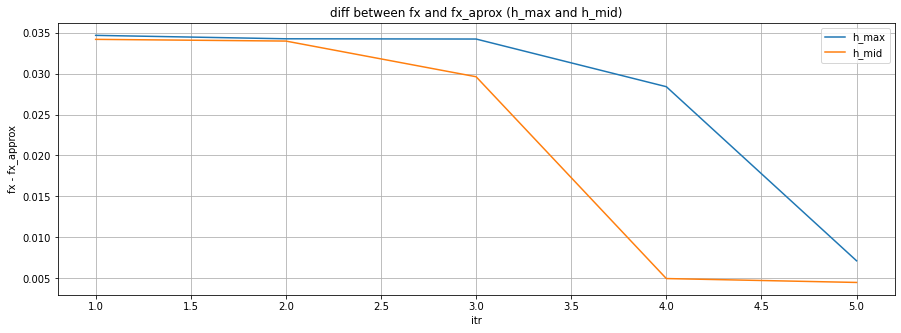

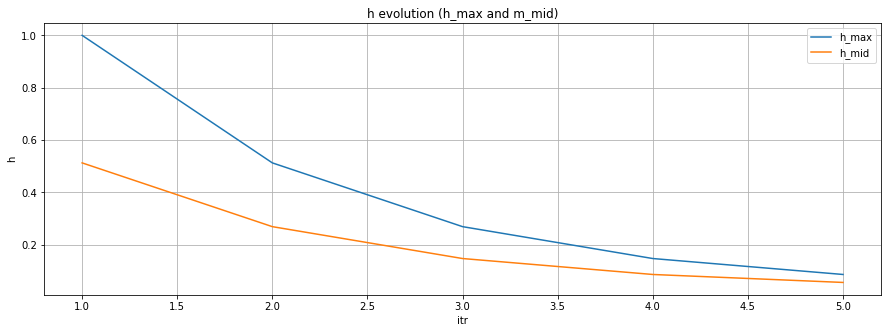

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 3.91001358e-02 -6.03420079e-02 -3.98999574e-17  2.30379866e-03]
 [-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Jacobian-SVD Feature Importances: 
[-0.258671  0.44793   0.       -0.014419]

--- 0.88 seconds ---


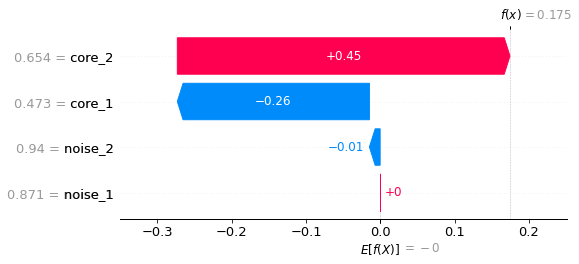

In [119]:
# angle between vectors -- optimize_h

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x=True, angle=True, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Iterations 6


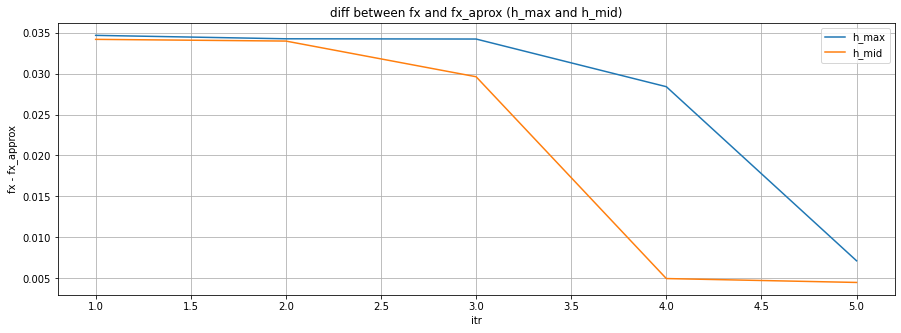

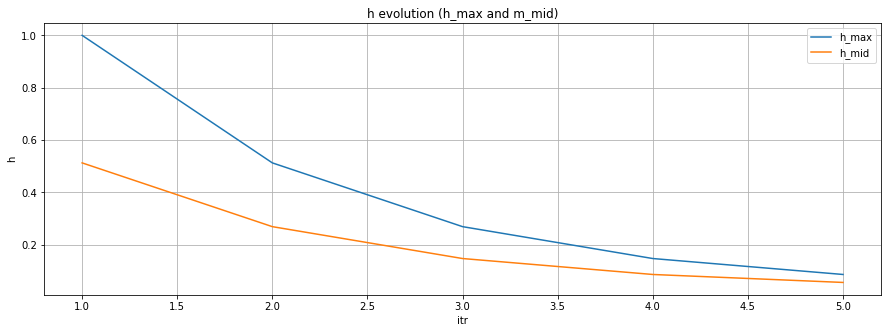

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 3.91001358e-02 -6.03420079e-02 -3.98999574e-17  2.30379866e-03]
 [-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Jacobian-SVD Feature Importances: 
[-0.258671  0.44793   0.       -0.014419]

--- 0.8 seconds ---


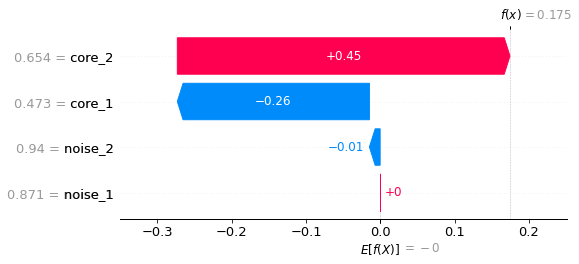

In [120]:
# dot product between vectors -- optimize_h

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x=True, angle=True, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

In [47]:
import matplotlib.pyplot as plt

# PLOT a beeswarm plot (SHAP-like) using jsvd_explainer explanations

# model is a treined m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data true labels
# h is a small number representing the magnitude of neighborhood perturbation
#   h_min and h_max represent an h interval of calibration
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration to calibrate h
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation
#                    =3 to use least squares polynomial finite difference

def jsvd_plots_sh_beeswarm(model, data, labels, h_min=1e-6, h_max=1, eps=1e-5, max_itr=100, 
                           finite_diff_version=3, e_x:bool=False, angle:bool=False, verbose:bool=False):
    
    start= time.time()

    size= data.shape[0]
    importance_values= []
    base_vector= []

    for i in range(size):
        #print(i)
        target_inst= data.iloc[i].to_frame().T
        target_labl= labels.iloc[i].to_frame().T

        j_phis, j_ft_rk, j_sh_exp= jsvd_explainer(model, data, labels, target_inst, target_labl,
                                                  h_min=h_min, h_max=h_max, eps=eps, max_itr=max_itr, 
                                                  finite_diff_version=finite_diff_version,
                                                  e_x=e_x, angle=angle, verbose=False)

        #shap.plots.waterfall(j_sh_exp)
        importance_values.append(j_phis)
        base_vector.append(j_sh_exp.base_values)

    j_exp= to_sh_exp(np.asarray(importance_values), np.asarray(base_vector), np.asarray(data), 
                        data.columns)

    shap.plots.beeswarm(j_exp, show=False)
    
    # get the current figure and axes objects
    fig, ax= plt.gcf(), plt.gca()
    # it is need to fix a bug between shap.plots and matplotlib on color_bar creation
    fig.axes[-1].set_aspect('auto')  # the handling of colorbar or box aspect ratio has 
    plt.tight_layout()               # been changed in matplotlib.pyplot version 3.5
    fig.axes[-1].set_box_aspect(50)
    # modifying main plot parameters
    ax.set_xlabel("SVD value (impact on model output)", fontsize=13)  # change from SHAP to SVD
    plt.show()
    
    if (verbose==True):
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 3.91001358e-02 -6.03420079e-02 -3.98999574e-17  2.30379866e-03]
 [-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Interpretation Jf(x)·x: 
[-0.01878166  0.01878131]

Jacobian-SVD Feature Importances: 
[-0.258671  0.44793   0.       -0.014419]

--- 0.37 seconds ---


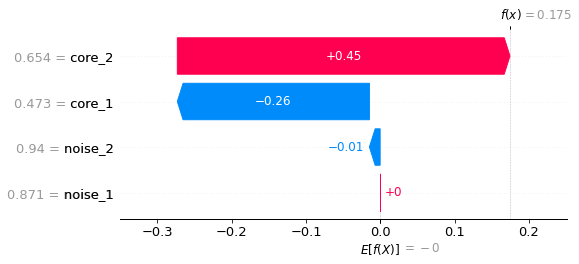

In [87]:
# angle between vectors -- optimize_h

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x= True, angle=True, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 3.91001358e-02 -6.03420079e-02 -3.98999574e-17  2.30379866e-03]
 [-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Interpretation Jf(x)·x: 
[-0.01878166  0.01878131]

Jacobian-SVD Feature Importances: 
[-0.181902  0.387796  0.       -0.021289]

--- 0.38 seconds ---


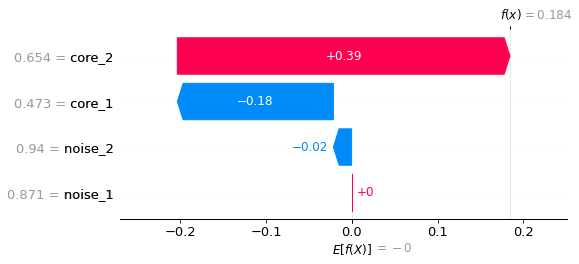

In [88]:
# dot product between vectors -- optimize_h -- e_x=True

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x= True, angle=False, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 3.91001358e-02 -6.03420079e-02 -3.98999574e-17  2.30379866e-03]
 [-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Interpretation Jf(x)·x: 
[-0.01878166  0.01878131]

Jacobian-SVD Feature Importances: 
[-0.384326  0.593111  0.       -0.022645]

--- 0.6 seconds ---


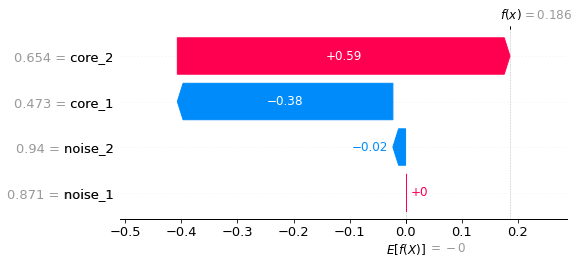

In [89]:
# dot product between vectors -- optimize_h -- e_x=False

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x= False, angle=False, 
                                                   verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 2.72967547e-03 -2.27859720e-02  1.05414260e-18 -5.64286944e-18]
 [-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Interpretation Jf(x)·x: 
[-0.01360626  0.01360549]

Jacobian-SVD Feature Importances: 
[-0.053693  0.653419  0.        0.      ]

--- 0.25 seconds ---


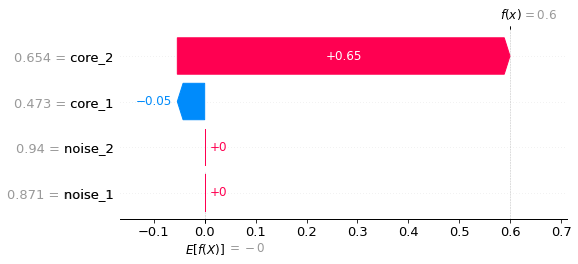

In [77]:
# angle between vectors -- optimize_h_v2

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x=True, angle=True, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 2.72967547e-03 -2.27859720e-02  1.05414260e-18 -5.64286944e-18]
 [-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Interpretation Jf(x)·x: 
[-0.01360626  0.01360549]

Jacobian-SVD Feature Importances: 
[-0.039821  0.459041 -0.        0.      ]

--- 0.24 seconds ---


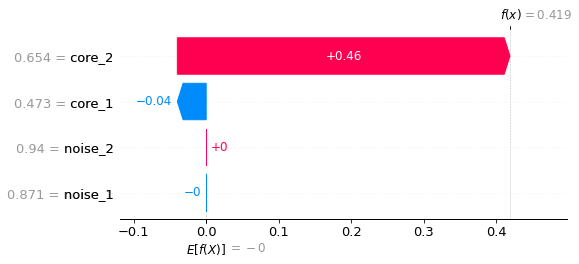

In [78]:
# dot product between vectors -- optimize_h_v2 -- e_x=True

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Expected predicted value E[f(X)]: 
-0.000197

Jacobian Matrix Jf(x): 
[[ 2.72967547e-03 -2.27859720e-02  1.05414260e-18 -5.64286944e-18]
 [-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Jacobian-SVD Feature Importances: 
[-0.084134  0.702076 -0.        0.      ]

--- 0.52 seconds ---


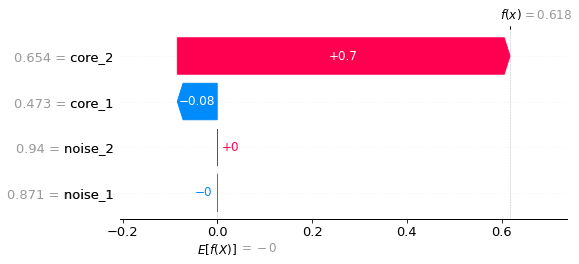

In [106]:
# dot product between vectors -- optimize_h_v2 -- e_x=False

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=h_min_dist, h_max=1, eps=1e-6, max_itr=50, 
                                                   finite_diff_version=3, e_x=False, angle=False, 
                                                   verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

In [ ]:
# h curve plots

# Tests using simplified model

In [988]:
# test using n=4 and m=2
# based on https://rh8liuqy.github.io/Finite_Difference.html

# f(a,b) = [a^2, b^2, a*b]

x_test= np.asarray([[1,2]])

x_test

array([[1, 2]])

In [989]:
# Jf(x)

dim= (2,3)

h_top, jac_test= optimize_h(xgb_model, x_test, target_labl, dim, h_min=1e-1, h_max=1e-1, eps=1e-3, 
                            max_itr=100, finite_diff_version=2)

print(jac_test)

[[2. 0.]
 [0. 4.]
 [2. 1.]]


In [905]:
h_top

0.1

In [906]:
xp_test= x_test + h_top

xp_test

array([[1.1, 2.1]])

In [907]:
# f(x)

fx_test= ML(xgb_model, x_test)

fx_test

array([1, 4, 2])

In [908]:
# f(xp)

fxp_test= ML(xgb_model, xp_test)

fxp_test

array([1.21, 4.41, 2.31])

In [909]:
# f(x) ~ f(xp) - Jf(x).h

fx_j= fxp_test - jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

fx_j

array([1.01, 4.01, 2.01])

In [910]:
# Jf(x).h

jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

array([0.2, 0.4, 0.3])

In [911]:
# Jf(x).h ~ f(xp) - f(x)

(fxp_test-fx_test)

array([0.21, 0.41, 0.31])

In [912]:
# Jf(x).x ~ f(x)

jac_test.dot(x_test.T).T

array([[2., 8., 4.]])

In [915]:
# Jf(x).x

U_test, S_test, VT_test= svd_decomposition(jac_test)

# Eq. 2
jfx_test= interpret_svd_coords(x_test.flatten(), U_test, S_test, VT_test)

jfx_test

array([2., 8., 4.])

In [913]:
# Jf(x).xp

jac_test.dot(xp_test.T).T

array([[2.2, 8.4, 4.3]])

In [914]:
# Jf(x).xp - Jf(x).x = Jf(x).h

jac_test.dot(xp_test.T).T - jac_test.dot(x_test.T).T

array([[0.2, 0.4, 0.3]])

In [512]:
S_test

array([[4.17425789, 0.        ],
       [0.        , 2.75237554],
       [0.        , 0.        ]])

In [513]:
# Eq. 3   ==>   need to adjust according to the pred class

add_importance_attribution(x_test, U_test, S_test, VT_test)

array([0.81239149, 2.03981324])

In [514]:
# Eq. 3   ==>   adjusted according to the pred class
# now f(x) = phi_0 + sum(phi(x))

rectified_feature_importances(0, fx_test[0], add_importance_attribution(x_test, U_test, S_test, VT_test))

array([0.2848293, 0.7151707])

In [992]:
# test using n=4 and m=2
# f(a,b,c,d) = [a*a-b-c*c-d-1, a-b*b+c+d*d+1]

x_test= np.asarray([[1,2,3,4]])
dim= (4,2)

h_top, jac_test= optimize_h(xgb_model, x_test, target_labl, dim, h_min=1e-9, h_max=1e-1, eps=1e-6, 
                            max_itr=100, finite_diff_version=2)

print(jac_test)

[[ 2. -1. -6. -1.]
 [ 1. -4.  1.  8.]]


In [993]:
h_top

0.1

In [994]:
# f(x)

fx_test= ML(xgb_model, x_test)
fx_test

array([-15,  17])

In [995]:
# Jf(x).x

jac_test.dot(x_test.T).T

array([[-22.,  28.]])

In [996]:
# Jf(x).xp

xp_test= x_test + h_top

jac_test.dot(xp_test.T).T

array([[-22.6,  28.6]])

In [997]:
# Jf(x).xp - Jf(x).x = Jf(x).h

jac_test.dot(xp_test.T).T - jac_test.dot(x_test.T).T

array([[-0.6,  0.6]])

In [998]:
# Jf(x).h

jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

array([-0.6,  0.6])

In [794]:
# test using n=2 and m=2
# f(a,b) = [a*a-b-1, a-b*b+1]

x_test= np.asarray([[1,2]])
dim= (2,2)

h_top, jac_test= optimize_h(xgb_model, x_test, target_labl, dim, h_min=1e-1, h_max=1e-1, eps=1e-6, 
                            max_itr=100, finite_diff_version=2)

print(jac_test)

[[ 2. -1.]
 [ 1. -4.]]


In [795]:
h_top

0.1

In [796]:
# f(x)

fx_test= ML(xgb_model, x_test)
fx_test

array([-2, -2])

In [797]:
# Jf(x).x

jac_test.dot(x_test.T).T

array([[-1.33226763e-15, -7.00000000e+00]])

In [798]:
# Jf(x).xp

xp_test= x_test + h_top

jac_test.dot(xp_test.T).T

array([[ 0.1, -7.3]])

In [799]:
# Jf(x).xp - Jf(x).x = Jf(x).h

jac_test.dot(xp_test.T).T - jac_test.dot(x_test.T).T

array([[ 0.1, -0.3]])

In [800]:
# Jf(x).h

jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

array([ 0.1, -0.3])

# Tests using xgb_model on synthetic data -- variable curves

In [527]:
target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

eps_range= []
fx_range= []
jfxh_range= []
jfxx_range= []
jfx1_range= []
fx_aprox= []
h_range= []
eps_min= 0.0001
i= 0.5

while i > eps_min:

    jsvd_phis,jsvd_jfxh,jsvd_jfxx,jsvd_jfx1,fx_ap,h_opt= jsvd_explainer(xgb_model, train, labels_train, 
                                                    target_inst, target_labl,
                                                    h_min=1e-15, h_max=1, eps=i, max_itr=50, 
                                                    finite_diff_version=2, verbose=False)
    
    eps_range.append(i)
    fx_range.append(np.sum(jsvd_phis)-0.000196)
    jfxh_range.append(jsvd_jfxh)
    jfxx_range.append(jsvd_jfxx)
    jfx1_range.append(jsvd_jfx1)
    fx_aprox.append(fx_ap)
    h_range.append(h_opt)
    i= np.around(i- eps_min, decimals=4)

# Variable curves -- tests using (fx, fx_j) difference --- optimize_h

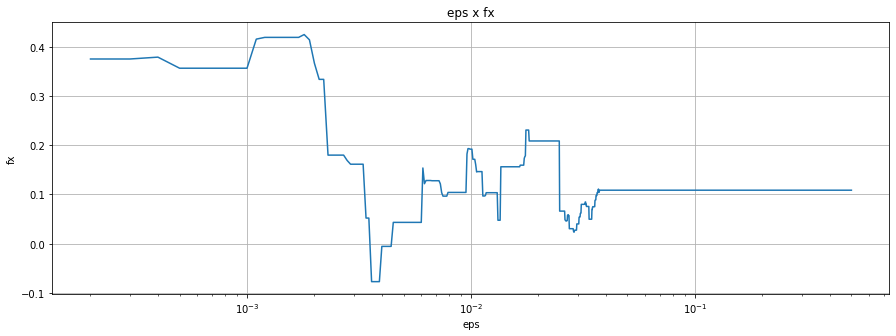

In [523]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, fx_range)
plt.title('eps x fx')
plt.xlabel('eps')
plt.ylabel('fx')
plt.xscale("log")
plt.grid(True)
plt.show()

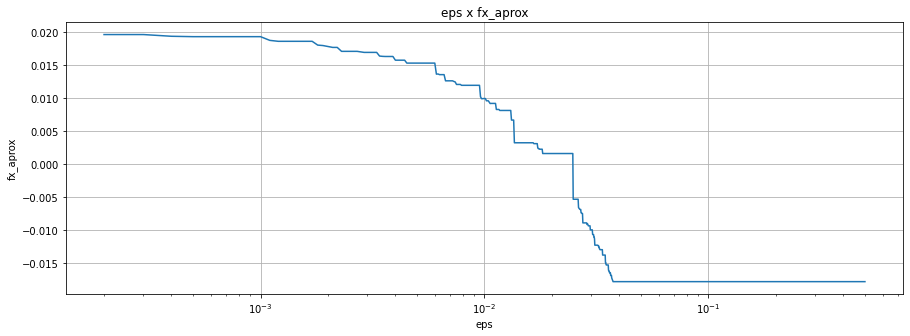

In [524]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, fx_aprox)
plt.title('eps x fx_aprox')
plt.xlabel('eps')
plt.ylabel('fx_aprox')
plt.xscale("log")
plt.grid(True)
plt.show()

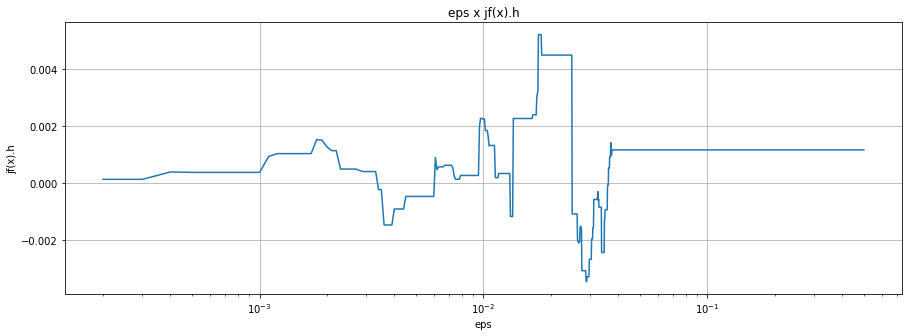

In [525]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, (jfxh_range))
plt.title('eps x jf(x).h')
plt.xlabel('eps')
plt.ylabel('jf(x).h')
plt.xscale("log")
plt.grid(True)
plt.show()

# Variable curves -- test using cost funcion minimization --- optimize_h

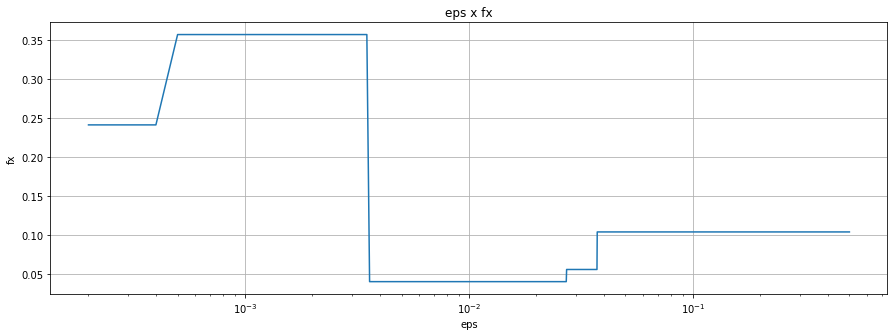

In [528]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, fx_range)
plt.title('eps x fx')
plt.xlabel('eps')
plt.ylabel('fx')
plt.xscale("log")
plt.grid(True)
plt.show()

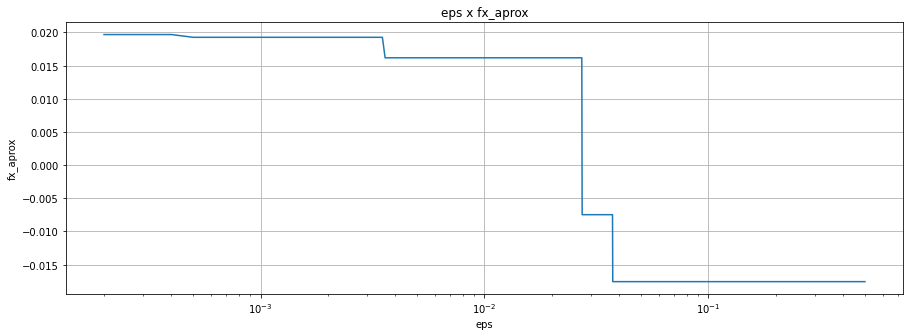

In [529]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, fx_aprox)
plt.title('eps x fx_aprox')
plt.xlabel('eps')
plt.ylabel('fx_aprox')
plt.xscale("log")
plt.grid(True)
plt.show()

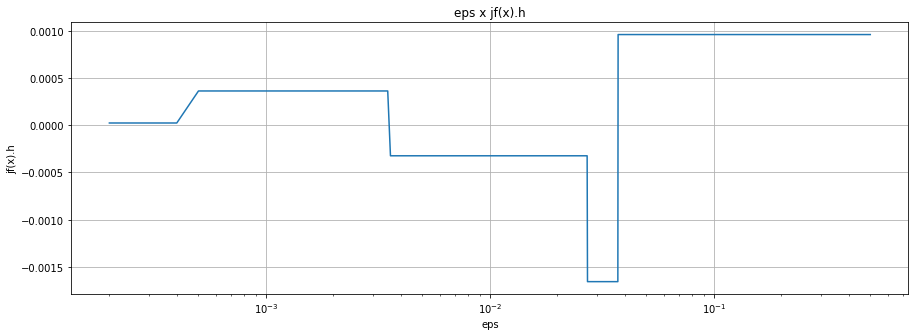

In [530]:
fig= plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.plot(eps_range, (jfxh_range))
plt.title('eps x jf(x).h')
plt.xlabel('eps')
plt.ylabel('jf(x).h')
plt.xscale("log")
plt.grid(True)
plt.show()

# SVD-Explainer -- Tests using different parameters

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted probability p_i(x): 
0.019757964

Expected predicted value E[f(X)]: 
-0.000196

Jacobian Matrix Jf(x): 
[[ 0.00814412 -0.035439   -0.00066141  0.00095908]
 [-0.00814408  0.03543852  0.00066203 -0.0009587 ]]

h optimized: 
0.04687500000000096

Interpretation Jf(x)·x: 
[-0.01899123  0.01899183]

Jacobian-SVD Feature Importances: 
[-0.116857  0.508493  0.009505 -0.013753]

--- 0.98 seconds ---


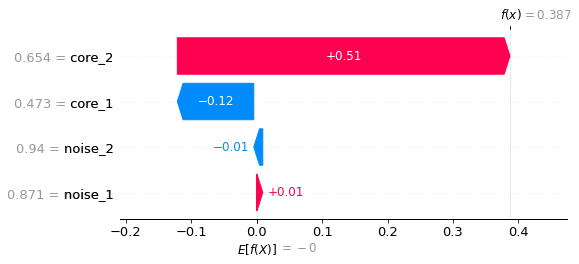

In [1968]:
# SVD-Explainer to only one instance (local explanation)

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=1e-15, h_max=1, eps=0.00385, max_itr=50, 
                                                   finite_diff_version=2, e_x= False, angle=False, 
                                                   verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

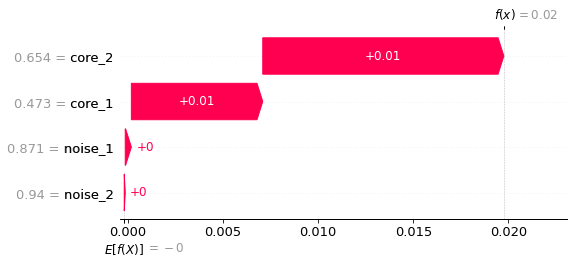

In [109]:
# SHAP explainer to only one instance (local explanation)

shap.plots.waterfall(shap_values[target_pos])

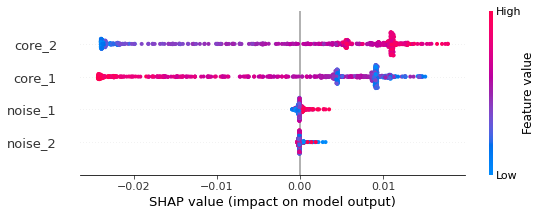

In [261]:
# Tests using SHAP

explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


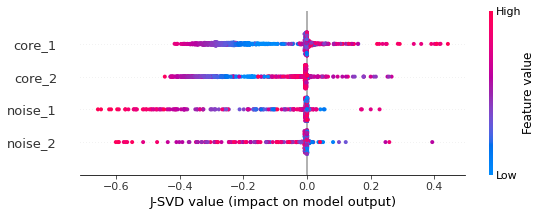


--- 44.82 seconds ---


In [408]:
# SVD-Explainer beeswarm plot -- finite_diff_version=1 -- optimize_h -- dot product

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=1e-9, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=1, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


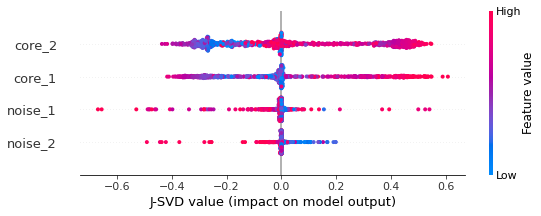


--- 349.27 seconds ---


In [406]:
# SVD-Explainer beeswarm plot -- finite_diff_version=2 -- optimize_h -- dot product

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=1e-9, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=2, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


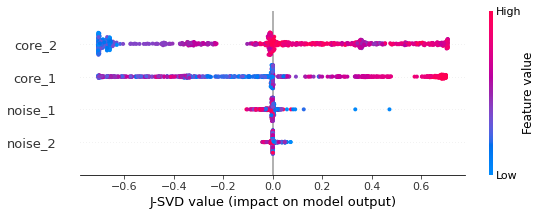


--- 55.21 seconds ---


In [1078]:
# SVD-Explainer beeswarm plot -- finite_diff_version=2 -- optimize_h -- angle

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=1e-9, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=2, e_x=False, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


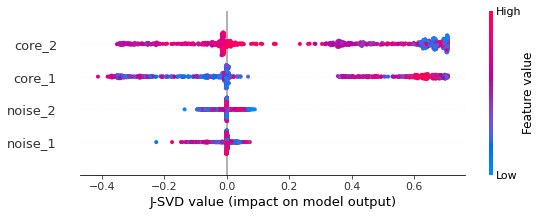


--- 65.44 seconds ---


In [125]:
# SVD-Explainer beeswarm plot -- finite_diff_version=3 -- optimize_h -- angle

h_min_dist= get_minimum_distance(train)

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=3, e_x=False, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


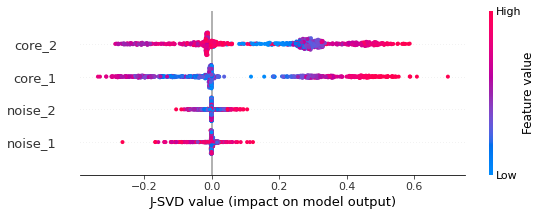


--- 61.59 seconds ---


In [124]:
# SVD-Explainer beeswarm plot -- finite_diff_version=3 -- optimize_h -- dot product e_x=True

h_min_dist= get_minimum_distance(train)

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=3, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


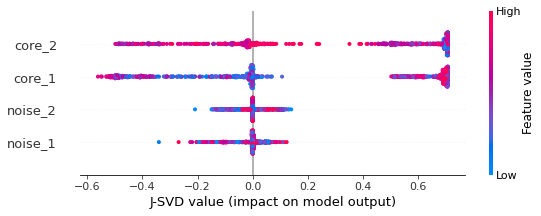


--- 60.15 seconds ---


In [123]:
# SVD-Explainer beeswarm plot -- finite_diff_version=3 -- optimize_h -- dot product e_x=False

h_min_dist= get_minimum_distance(train)

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=3, e_x=False, angle=False, verbose=True)

# --- T-Explainer Methods ---

In [151]:
# NEW VERSION
# inputs and outputs are similar to optimize_h, except we define only one init value to h and 
# we do not need to define an eps value here

# f(x + h) = f(x) + Jf(x).h + O(|| h^2 ||)

# RETURN an optimum h value and its related jacobian_matrix

def optimize_h_v2(model, data, label, pred, pred_class, dimensions, h_init=1, max_itr=100, 
                  finite_diff_version=2, verbose:bool=False):
    
    h= 0
    j_matrix= []
    
    xn= np.asarray(data)
    fx= pred
    xn_zeros= np.zeros(xn.shape)
    fx_zeros= np.zeros(fx.shape)
    
    C= 1/2
    mim_f_type= 'mse'
    h_opt= h_init
    previous_cost= 1
    previous_resi= 1
    itr= 0
    in_loop= True
    
    while (in_loop):
        itr= itr+ 1
        
        eps_h= C*(h_opt**2)
        
        if (finite_diff_version==1):
            jacobian= get_jacobian_matrix(model, data, label, dimensions, h=h_opt, eps=eps_h, max_itr=1)
        elif (finite_diff_version==2): # then use get_jacobian_matrix_v2
            jacobian= get_jacobian_matrix_v2(model, data, label, dimensions, h=h_opt, eps=eps_h, max_itr=1)
        else:                          # then use get_jacobian_matrix_lspfd
            jacobian= get_jacobian_matrix_lspfd(model, data, label, dimensions, h=h_opt, eps=eps_h, max_itr=1)
        
        
        xp= xn + h_opt
        fxp= ML(model, pd.DataFrame(data=xp, columns=data.columns))
        
        # Jf(x).h this linear map is known as the derivative or the differential of f at x
        jfxh= jacobian.dot((xn_zeros+h_opt).T).T
        # f(x) ~ f(xp) - Jf(x).h
        fx_aprox= (fxp - jfxh).flatten()
        
        # calculating the h_opt current cost
        current_cost= cost_function(fx[pred_class], fx_aprox[pred_class], cost_type=mim_f_type)
        # the function evaluation will always introduce some noise, the error is a combination of the 
        # approximation error and that noise
        
        cost_residual= np.abs(previous_cost - current_cost)
        
        """
        print('itr', itr)
        print('fx_ap', fx_aprox)
        print('jfxh', jfxh[0][pred_class])
        print('current_cost', current_cost)
        print('residual', cost_residual)
        #"""
        
        if (not singular_matrix(np.asarray([jacobian[pred_class]]))):
            
            # if the change in cost is less than or equal to the stopping threshold we stop
            # the eps is the minimum change of loss between two successive iterations to stop the algorithm
            if (previous_cost and cost_residual< eps_h):
                in_loop= False
                h= h_opt
                j_matrix= np.asarray(jacobian)
                
            else:
                # updates h using the derivative signal and the cost residual 
                
                d_signal= jfxh[0][pred_class]/ np.abs(jfxh[0][pred_class])
                f_ap_sig= fx_aprox[pred_class]/ np.abs(fx_aprox[pred_class])
                
                if (previous_resi< cost_residual): 
                    res_sign= -1
                else:
                    res_sign= 1
                           
                h_opt= np.abs(h_opt + ((d_signal*f_ap_sig*res_sign) * current_cost))
        
        else:   # singularity case, h is too small
                # updates h by adding the cost residual     
            h_opt= h_opt + (current_cost)
            
            
        if not (itr< max_itr):
            in_loop= False
            h= h_opt
            j_matrix= np.asarray(jacobian)
            
        previous_cost= current_cost
        previous_resi= cost_residual
        
    if (verbose== True):
        print("f(x) predicted value:")
        print(np.around(fx[fx_class], decimals=8))
        print("\nf(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :")
        print(np.around(fx_aprox[fx_class], decimals=8))
        print("\nJf(x).h, the differential of f at x :")
        print(np.around(jfxh[0][fx_class], decimals=8))
        print("\nError value defined to the approximation process:")
        print(np.around(eps_h, decimals=8))
        print("\nFinal cost minimized:")
        print(np.around(current_cost, decimals=8))
        print("\nNumber of iterations to get this approximation:")
        print(itr)
        
    
    return h, j_matrix

In [784]:
# using xgb_model -- optimize_h

dimensions= get_n_m_sizes(train, labels_train)

target_pos= 2
target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

fx= ML(xgb_model, target_inst)
fx_class= (xgb_model.predict(target_inst))[0]

h_min_dist= get_minimum_distance(train)

optimize_h_v2(xgb_model, target_inst, target_labl, fx, fx_class, dimensions, 
              h_min=h_min_dist, h_max=1, max_itr=50, finite_diff_version=3, verbose=True)

f(x) predicted value:
0.0199952

f(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :
0.01999095

Jf(x).h, the differential of f at x :
0.00062184

Error value defined to the approximation process:
0.0004235

Final cost minimized:
4.25e-06

Number of iterations to get this approximation:
9


(0.031006834501793423,
 array([[ 2.72967547e-03, -2.27859720e-02, -5.08306411e-19,
         -5.72841751e-18],
        [-2.73051648e-03,  2.27854013e-02,  1.07673296e-18,
          4.66658453e-18]]))

In [392]:
# using xgb_model -- optimize_h_v2

dimensions= get_n_m_sizes(train, labels_train)

target_pos= 2
target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

fx= ML(xgb_model, target_inst)
fx_class= (xgb_model.predict(target_inst))[0]

h_min_dist= get_minimum_distance(train)

optimize_h_v3(xgb_model, target_inst, target_labl, fx, fx_class, dimensions, 
              h_init=h_min_dist, max_itr=10, finite_diff_version=2, verbose=True)

f(x) predicted value:
0.0199952

f(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :
0.01940201

Jf(x).h, the differential of f at x :
0.00059319

Error value defined to the approximation process:
0.00031994

Final cost minimized:
3.5e-07

Number of iterations to get this approximation:
2


(0.025296028227715033,
 array([[ 4.20449542e-05, -2.34899130e-02,  0.00000000e+00,
          0.00000000e+00],
        [-4.15663344e-05,  2.34914217e-02,  0.00000000e+00,
          0.00000000e+00]]))

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities (log odds) f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-0.03910044  0.06034175  0.         -0.00230384]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Taylor Feature Importances: 
[-0.018506  0.039453  0.       -0.002166]

--- 0.59 seconds ---


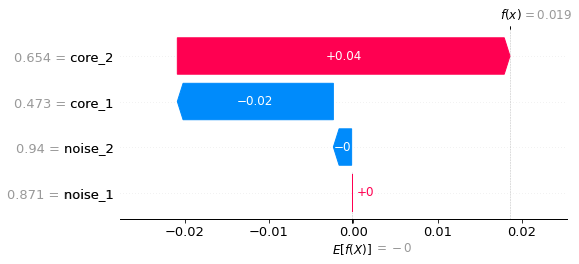

In [106]:
# optimize_h_v2

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=2, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

In [650]:
# using nn3_model -- optimize_h

dimensions= get_n_m_sizes(train, labels_train)

target_pos= 2
target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

fx= ML(nn3_model, target_inst)
fx_class= (nn3_model.predict(target_inst).astype(int))[0]

h_min_dist= get_minimum_distance(train)

optimize_h_v2(nn3_model, target_inst, target_labl, fx, fx_class, dimensions, 
              h_min=h_min_dist, h_max=1, max_itr=50, finite_diff_version=3, verbose=True)

f(x) predicted value:
4.22503002

f(x) predicted value approximated using f(xp) ~ f(x) + Jf(x).h :
4.20404106

Jf(x).h, the differential of f at x :
-0.10111207

Error value defined to the approximation process:
0.00031994

Final cost minimized:
0.02098895

Number of iterations to get this approximation:
50


(0.025295676355439438,
 array([[ 43.424206  , -39.25158836,  -0.75851792,   0.58310781],
        [-43.424206  ,  39.25158836,   0.75851792,  -0.58310781]]))

In [50]:
# here we compute the dot / angle-based version of importance measurent phi_i to each attribute i, according
# to the Taylor-Explainer definitions

# x is a n-dimensional data instance (ndarray)
# pred_class is the predicted class of the instance under explanation
# j_matrix is the jacobian m x n matrix (ndarray)
# e_x when FALSE e_x(i)= 1, when TRUE e_x(i)= x(i), that is e_x is a vector of 1 or a vector with x values
# angle when FALSE uses dot product to compute the importances, when TRUE uses the angle value

# RETURN the measured importance phi_i of each attribute i from x

def t_add_importance_attribution(x, pred_class, j_matrix, e_x:bool=False, angle:bool=False):
    
    n= j_matrix.shape[1]
    #m= j_matrix.shape[0]
    #j= np.min([m,n])
    
    phi= np.zeros(n)             #               i
    E= np.identity(n)            # e_i= (0, ..., 1, ..., 0) canonical vector from features
    
    if (e_x== True):
        E= E * x
    
    dfx= j_matrix[pred_class]

    for i in range(n):
        e_i= E[i]
                        # get the angle between vectors dfx and e_i
        if (angle==True):
            phi[i]= phi[i] + (vector_angle(dfx, e_i))
        else:           # get the dot product between vectors dfx and e_i
            phi[i]= phi[i] + (np.dot(dfx, e_i.T))
    
    return phi

In [874]:
x= np.asarray([0.47330104, 0.65383311, 0.87131331, 0.94010178])

A= np.asarray([[ 0.00327691, -0.01531371, -0.00096196,  0.00143862],
               [-0.00327829,  0.01531357,  0.00096312, -0.00143805]])

print((A[1]).dot(x))
print(A.dot(x))

0.0079481669422793
[-0.00794737  0.00794817]


In [228]:
x= np.asarray([0, 0.65383311, 0, 0])

A= np.asarray([[ 0.00327691, -0.01531371, -0.00096196,  0.00143862],
               [-0.00327829,  0.01531357,  0.00096312, -0.00143805]])

print((A[1]).dot(x))

0.0100125190983027


In [875]:
# angle-based version -- E

t_add_importance_attribution(x, 1, A, e_x=False, angle= True)

array([-0.13343476,  0.84879534,  0.03893931, -0.05818565])

In [876]:
# angle-based version -- E * x

t_add_importance_attribution(x, 1, A, e_x=True, angle= True)

array([-0.13343476,  0.84879534,  0.03893931, -0.05818565])

In [877]:
# dot product-based version -- E

t_add_importance_attribution(x, 1, A, e_x=False, angle= False)

array([-0.00327829,  0.01531357,  0.00096312, -0.00143805])

In [878]:
# dot product-based version -- E * x

t_add_importance_attribution(x, 1, A, e_x=True, angle= False)

array([-0.00155162,  0.01001252,  0.00083918, -0.00135191])

In [51]:
# interpretable explanations need to use a representation that is understandable to humans, regardless 
# of the actual features used by the model (Ribeiro et al., 2016)
# explanation models often use simplified inputs x' that map to the original inputs through a
# mapping function x = hx(x')

# x is the original data input
# n is the number of inputs used to explain the prediction of a model

# RETURN x' as a simplified inputs array

def hx_mapping(x, n, h):
    
    x_size= x.shape[1]
    
    x_line= np.zeros(x_size)
    
    # Here we are handling tabular data, then all the features can receive a true (1) mask
    # TODO - define proper masks to create the binary vector x' in {0,1}^(n') holding the interpretable 
    # representations of x, cosidering images and text data
    
    for i in range(n):
        #x_line[i]= x[0][i] * 1
        #x_line[i]= 1 * h
        #x_line[i]= x[0][i] * h
        x_line[i]= 1
    
    return x_line

In [67]:
hx_mapping(np.asarray(target_inst), 4, 0.1)

array([0.1, 0.1, 0.1, 0.1])

In [52]:
# here we put the importance vector in accordance to f(x) and df(x)
# importances is an (1 x n) numpy.ndarray with the ft importances
# fx is the f(x) probabilities vector
# fx_p_class is the predicted class from f(x)
# j_matrix is the jacobian m x n matrix (ndarray)
# h is the neighborhood perturbation used to generate j_matrix

# RETURN the importances vector scaled

def derivative_adjustment_ft_imp(importances, fx, fx_p_class, e_fx, j_matrix, h):
    
    xn_zeros= np.zeros(importances.shape)
    # Jf(x).h this linear map is known as the derivative or the differential of f at x
    jfxh= (j_matrix.dot((xn_zeros+h).T).T)
    
    d_fx= jfxh[fx_p_class]
    p_fx= fx[fx_p_class]
    simp= np.sum(importances)
    
    adj_importances= np.zeros(importances.shape)
    
    if ((simp< 0) and (p_fx> 0)):            # here we have an adjustment method to fix the situation where
        adj_importances= (-1) * importances  # the function f and its explanation have different signals
                                             # we observe this situation of disagreement, and then we proceed
    elif ((simp> 0) and (p_fx< 0)):          # a rectification step to fix a signal mismatch
        adj_importances= (-1) * importances   
    
    else:
        adj_importances= 1 * importances
    
    
    return adj_importances

In [65]:
ft_i= np.asarray([-0.003278,  0.015314,  0.000963, -0.001438])
fx= np.asarray([-0.01975794,  0.01975796])
fx_p_class= 1
A= np.asarray([[ 0.00327691, -0.01531371, -0.00096196,  0.00143862],
               [-0.00327829,  0.01531357,  0.00096312, -0.00143805]])
h= 0.03125000000000097

derivative_adjustment_ft_imp(ft_i, fx, fx_p_class, A, h)

array([-0.003278,  0.015314,  0.000963, -0.001438])

In [152]:
# inputs are similar to jsvd_explainer

# e_x when FALSE e_x(i)= 1, when TRUE e_x(i)= x(i), that is e_x is a vector of 1 or a vector with x values
# angle when FALSE uses dot product to compute the importances, when TRUE uses the angle value

# RETURN local feature importances of the instance x_to_exp_data relative to model classifier

def taylor_explainer(model, data, labels, x_to_exp_data, x_to_exp_label, h_min=1e-6, h_max=1, eps=1e-5,
                     max_itr=100, finite_diff_version=3, e_x:bool=False, angle:bool=False, 
                     verbose:bool=False):
    
    start= time.time()
    
    n, m= get_n_m_sizes(data, labels)
    dimensions= (n, m)
    
    mean_inst= replace_values(data, data.columns, num_type='mean', cat_type='none')
    # e_fx can be understood as the average model output across the training set X when Xi is not known
    # for this reason, the data mean is used
    e_fx= expected_value_x_mean(model, mean_inst, labels.values.ravel())
    
    # fx_p_class is the predicted class of the instance under explanation
    fx_p_class= ((model.predict(x_to_exp_data)).astype(int))[0]
    # fx is the predicted probabilities of the instance under explanation
    fx= ML(model, x_to_exp_data)
    # p_fx is the class predicted probability of the instance under explanation
    p_fx= fx[fx_p_class]
    
    
    h_opt, j_matrix= optimize_h(model, x_to_exp_data, x_to_exp_label, fx, fx_p_class, dimensions, 
                                h_min=h_min, h_max=h_max, eps=eps, max_itr=max_itr, 
                                finite_diff_version=finite_diff_version, verbose=False)
    
    #h_opt, j_matrix= optimize_h_v2(model, x_to_exp_data, x_to_exp_label, fx, fx_p_class, dimensions, 
    #                               h_init=h_min, max_itr=max_itr, 
    #                               finite_diff_version=finite_diff_version, verbose=False)
    
    
    x= np.asarray(x_to_exp_data).flatten()
    
    t_phis= t_add_importance_attribution(x, fx_p_class, j_matrix, e_x=e_x, angle=angle)
    
    
    # define z'
    z_line= hx_mapping(np.asarray([x]), n, h_opt)
    # determine gx(z')
    t_phis= t_phis * z_line
    
    
    t_phis= derivative_adjustment_ft_imp(t_phis, fx, fx_p_class, e_fx, j_matrix, h_opt)
    
    t_ranking= pd.Series(t_phis, index=x_to_exp_data.columns).sort_values(ascending=False)
    
    t_sh_exp= to_sh_exp(t_phis, e_fx, np.asarray(x_to_exp_data)[0], x_to_exp_data.columns)
    
    if (verbose==True):
        print("Target instance: ")
        print(x)
        print("\nPredicted class: ")
        print(fx_p_class)
        print("\nPredicted probabilities (log odds) f(x): ")
        print(fx)
        print("\nGrad_[ f(x) ]: ")
        print(j_matrix[fx_p_class])
        print("\nh optimized: ")
        print(h_opt)
        print("\nDifferential of f at x, Jf(x)·h: ")
        print(j_matrix.dot((np.zeros(n)+h_opt).T).T)
        print("\nTaylor Feature Importances: ")
        print(np.around(t_phis, decimals=6))
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))
    
    return t_phis, t_ranking, t_sh_exp

# T-Explainer tests using different parameters -- one instance

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Taylor Feature Importances: 
[-0.365817  0.633468  0.       -0.020391]

--- 0.27 seconds ---


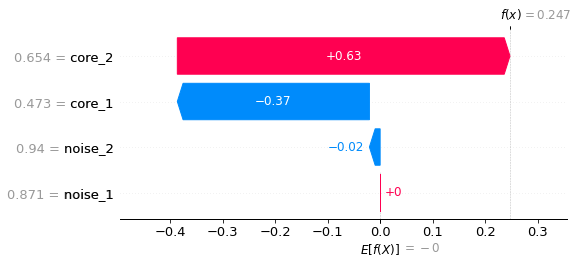

In [128]:
# optimize_h -- t_add_importance_attribution -- angle

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=True, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Taylor Feature Importances: 
[-0.018506  0.039453  0.       -0.002166]

--- 0.15 seconds ---


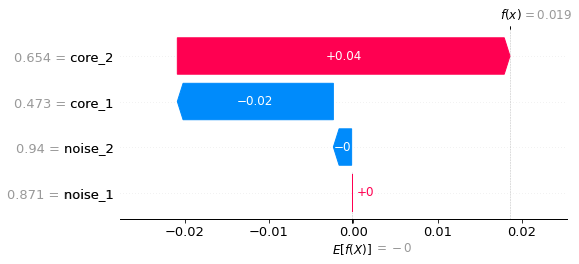

In [129]:
# optimize_h -- t_add_importance_attribution -- dot product e_x=True

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-3.91004383e-02  6.03417486e-02  3.21229668e-17 -2.30384187e-03]

h optimized: 
0.08621469658322367

Differential of f at x, Jf(x)·h: 
[-0.00163274  0.00163269]

Taylor Feature Importances: 
[-0.0391    0.060342  0.       -0.002304]

--- 0.43 seconds ---


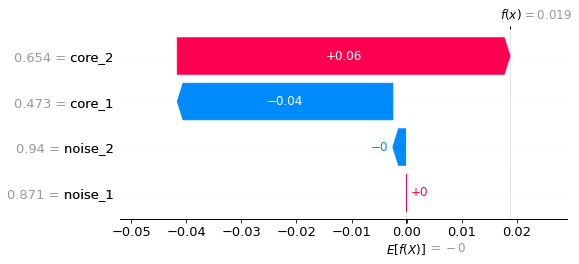

In [264]:
# optimize_h -- t_add_importance_attribution -- dot product e_x=False

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=False, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Taylor Feature Importances: 
[-0.075928  0.924072  0.        0.      ]

--- 0.25 seconds ---


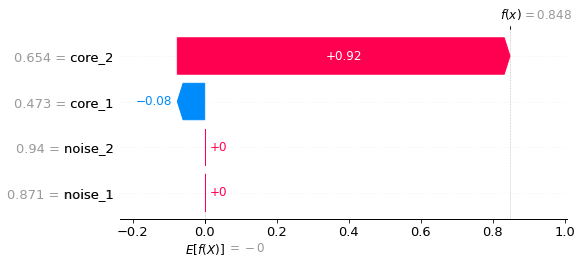

In [132]:
# optimize_h_v2 -- t_add_importance_attribution -- angle

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=True, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Taylor Feature Importances: 
[-0.001292  0.014898 -0.        0.      ]

--- 0.16 seconds ---


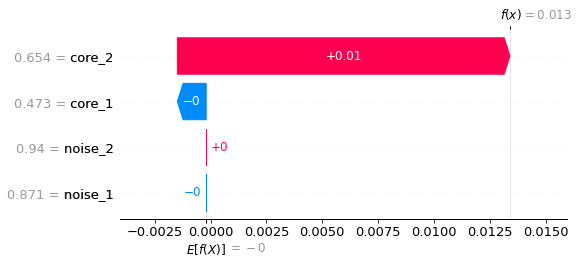

In [133]:
# optimize_h_v2 -- t_add_importance_attribution -- dot product e_x=True

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.01999519  0.0199952 ]

Grad_[ f(x) ]: 
[-2.73051648e-03  2.27854013e-02 -5.78418425e-19  4.52581908e-18]

h optimized: 
0.031006834501793423

Differential of f at x, Jf(x)·h: 
[-0.00062188  0.00062184]

Taylor Feature Importances: 
[-0.002731  0.022785 -0.        0.      ]

--- 0.12 seconds ---


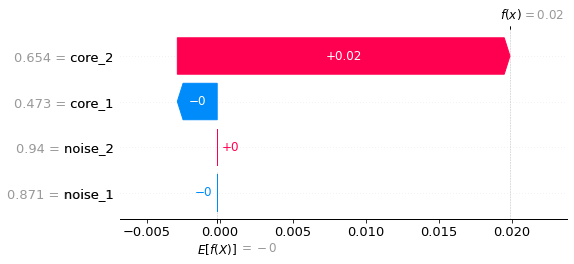

In [134]:
# optimize_h_v2 -- t_add_importance_attribution -- dot product e_x=False

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=False, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

In [398]:
# the instance to be explained (from train dataset)

target_pos= 81

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


,core_1,core_2,noise_1,noise_2
632,0.676756,0.73485,0.045755,0.0


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


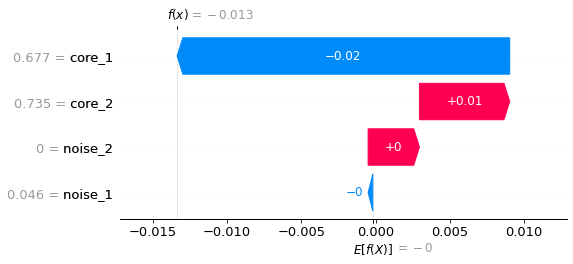

In [318]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.waterfall(shap_values[target_pos])

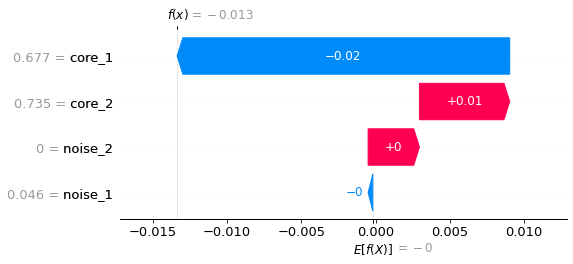

In [319]:
# Tests using TreeSHAP

explainer= shap.TreeExplainer(xgb_model)
shap_values= explainer(train)
shap.plots.waterfall(shap_values[target_pos])

Target instance: 
[0.67675579 0.7348498  0.04575543 0.        ]

Predicted class: 
0

Predicted probabilities (log odds) f(x): 
[ 0.01337355 -0.01337353]

Grad_[ f(x) ]: 
[ 0.03260874 -0.0047429   0.00075919  0.00607983]

h optimized: 
0.5126478381777193

Differential of f at x, Jf(x)·h: 
[ 0.01779137 -0.01779143]

Taylor Feature Importances: 
[ 2.2068e-02 -3.4850e-03  3.5000e-05  0.0000e+00]

--- 0.28 seconds ---


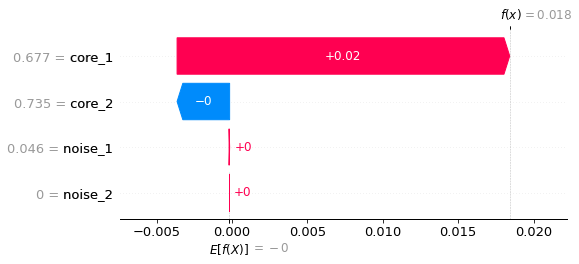

In [320]:
# using optimize_h_v3

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=2, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


Target instance: 
[0.67675579 0.7348498  0.04575543 0.        ]

Predicted class: 
0

Predicted probabilities (log odds) f(x): 
[ 0.01337355 -0.01337353]

Grad_[ f(x) ]: 
[ 0.00190881 -0.00716229  0.01509935  0.00414736]

h optimized: 
0.025295867031787996

Differential of f at x, Jf(x)·h: 
[ 0.00035397 -0.00035395]

Taylor Feature Importances: 
[-0.001292  0.005263 -0.000691 -0.      ]

--- 0.23 seconds ---


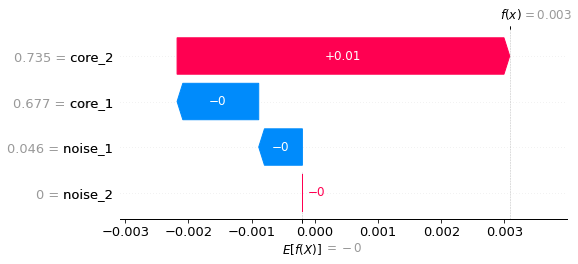

In [399]:
# using optimize_h_v3

h_min_dist= get_minimum_distance(train)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                            h_min=h_min_dist, h_max=1, max_itr=50, 
                                            finite_diff_version=2, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

In [54]:
# PLOT a beeswarm plot (SHAP-like) using taylor_explainer explanations

# model is a treined m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data true labels
# h is a small number representing the magnitude of neighborhood perturbation
#   h_min and h_max represent an h interval of calibration
# max_itr is the max iteration to calibrate h
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation
#                    =3 to use least squares polynomial finite difference
# e_x when FALSE e_x(i)= 1, when TRUE e_x(i)= x(i), that is e_x is a vector of 1 or a vector with x values
# angle when FALSE uses dot product to compute the importances, when TRUE uses the angle value

def taylor_plots_sh_beeswarm(model, data, labels, h_min=1e-6, h_max=1, eps=1e-5, max_itr=100, 
                             finite_diff_version=3, e_x:bool=False, angle:bool=False, verbose:bool=False):
    
    start= time.time()

    size= data.shape[0]
    importance_values= []
    base_vector= []

    for i in range(size):
        #print(i)
        target_inst= data.iloc[i].to_frame().T
        target_labl= labels.iloc[i].to_frame().T

        t_phis, t_ft_rk, t_sh_exp= taylor_explainer(model, data, labels, target_inst, target_labl,
                                                    h_min=h_min, h_max=h_max, eps=eps, max_itr=max_itr, 
                                                    finite_diff_version=finite_diff_version,
                                                    e_x=e_x, angle=angle, verbose=False)

        #shap.plots.waterfall(t_sh_exp)
        importance_values.append(t_phis)
        base_vector.append(t_sh_exp.base_values)

    t_exp= to_sh_exp(np.asarray(importance_values), np.asarray(base_vector), np.asarray(data), 
                     data.columns)

    shap.plots.beeswarm(t_exp, show=False)
    
    # get the current figure and axes objects
    fig, ax= plt.gcf(), plt.gca()
    # it is need to fix a bug between shap.plots and matplotlib on color_bar creation
    fig.axes[-1].set_aspect('auto')  # the handling of colorbar or box aspect ratio has 
    plt.tight_layout()               # been changed in matplotlib.pyplot version 3.5
    fig.axes[-1].set_box_aspect(50)
    # modifying main plot parameters
    ax.set_xlabel("T-Explainer value (impact on model output)", fontsize=13)  # change from SHAP to J-SVD
    plt.show()
    
    if (verbose==True):
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))

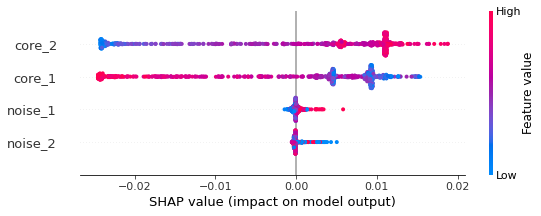

In [258]:
# Tests using SHAP

explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

# T-Explainer tests using different parameters -- multiple instances

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


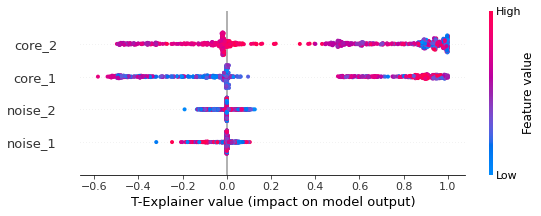


--- 87.14 seconds ---


In [137]:
# T-Exp beeswarm plot -- optimize_h -- angle
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


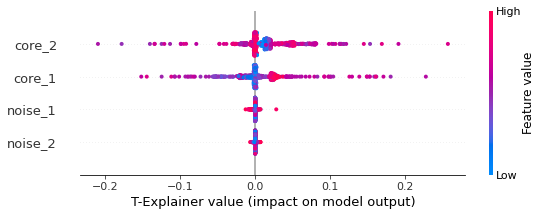


--- 80.93 seconds ---


In [138]:
# T-Exp beeswarm plot -- optimize_h -- dot_product e_x=True
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


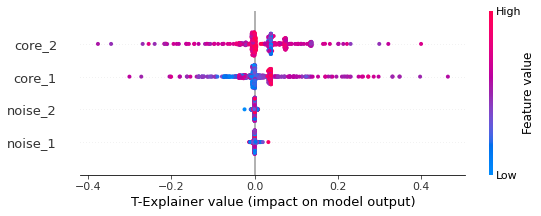


--- 75.07 seconds ---


In [139]:
# T-Exp beeswarm plot -- optimize_h -- dot_product e_x=False
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


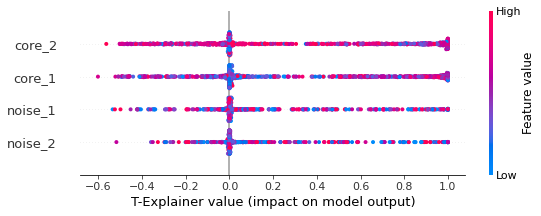


--- 449.29 seconds ---


In [142]:
# T-Exp beeswarm plot -- optimize_h_v2 -- angle
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


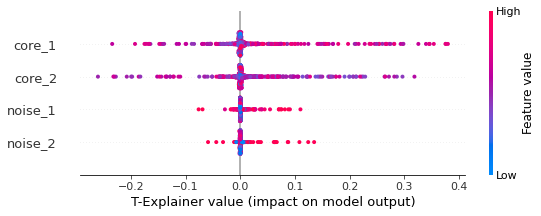


--- 350.59 seconds ---


In [143]:
# T-Exp beeswarm plot -- optimize_h_v2 -- dot_product e_x=True
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


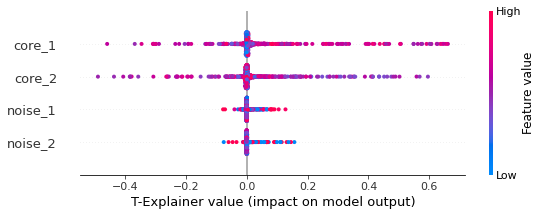


--- 353.33 seconds ---


In [144]:
# T-Exp beeswarm plot -- optimize_h_v2 -- dot_product e_x=False
# USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


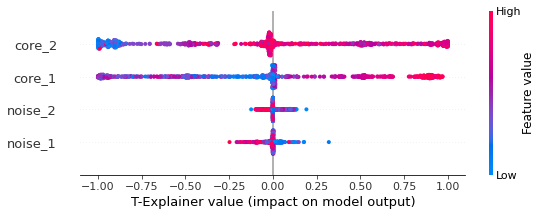


--- 60.11 seconds ---


In [146]:
# T-Exp beeswarm plot -- optimize_h -- angle
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


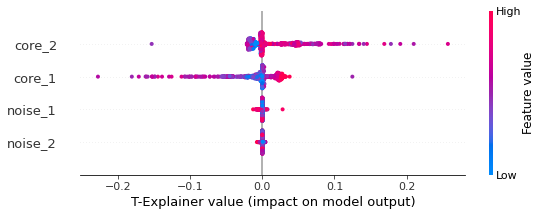


--- 59.74 seconds ---


In [147]:
# T-Exp beeswarm plot -- optimize_h -- dot_product e_x=True
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


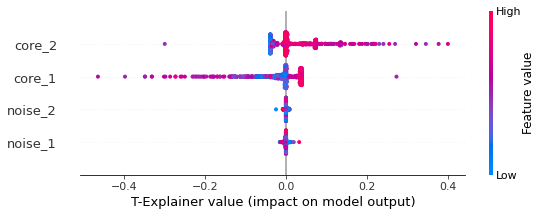


--- 59.56 seconds ---


In [148]:
# T-Exp beeswarm plot -- optimize_h -- dot_product e_x=False
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


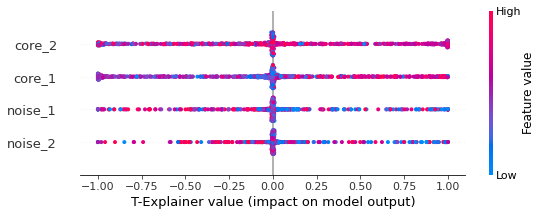


--- 351.56 seconds ---


In [151]:
# T-Exp beeswarm plot -- optimize_h_v2 -- angle
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


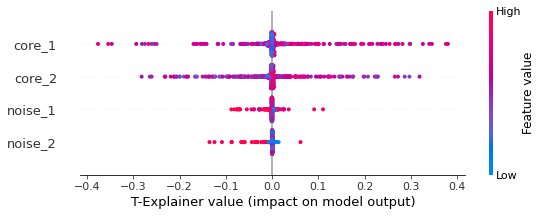


--- 350.88 seconds ---


In [152]:
# T-Exp beeswarm plot -- optimize_h_v2 -- dot_product e_x=True
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


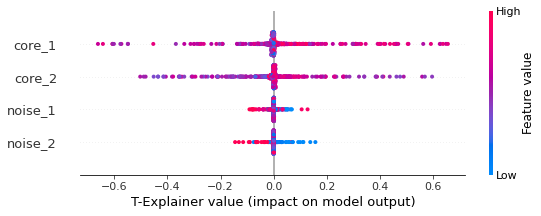


--- 353.23 seconds ---


In [153]:
# T-Exp beeswarm plot -- optimize_h_v2 -- dot_product e_x=False
# NO USING derivative_adjustment_ft_imp

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                         finite_diff_version=3, e_x=False, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


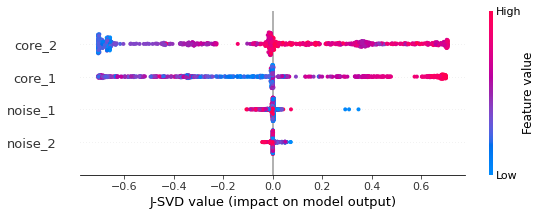


--- 60.4 seconds ---


In [99]:
# J-SVD beeswarm plot -- finite_diff_version=2 -- optimize_h -- angle

h_min_dist= get_minimum_distance(train)

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=2, angle=True, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


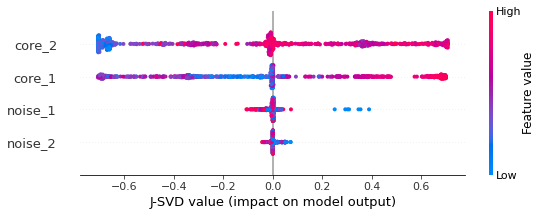


--- 58.57 seconds ---


In [100]:
# J-SVD beeswarm plot -- finite_diff_version=3 -- optimize_h -- angle

h_min_dist= get_minimum_distance(train)

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=50, 
                       finite_diff_version=3, angle=True, verbose=True)

# --- Benchmarking ---

In [55]:
import openxai

# Utils
import torch
import pickle

# Data loaders
from openxai.dataloader import return_loaders

# Perturbation methods required for the computation of the relative stability metrics
from openxai.explainers.catalog.perturbation_methods import NormalPerturbation
from openxai.explainers.catalog.perturbation_methods import NewDiscrete_NormalPerturbation

In [56]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train= torch.from_numpy(train.values)
tensor_labels= torch.from_numpy(labels_train.values.ravel().astype(int))

In [57]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.001
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

def generate_mask(explanation, top_k):
    mask_indices= torch.topk(explanation, top_k).indices
    mask= torch.zeros(explanation.shape) > 10
    for i in mask_indices:
        mask[i]= True
    return mask

descriptor= dict()

h_min_dist= get_minimum_distance(train)

# T-Exp explanation settings -- over OUR synthetic data
descriptor['h_min']= h_min_dist
descriptor['h_max']= 1
descriptor['jacobian_eps']= 1e-3
descriptor['max_itr']= 30
descriptor['finite_diff_version']= 2

# perturbation settings used for the stability metrics
descriptor['num_samples']= 50
descriptor['num_perts']= 10    ##### original era 50
descriptor['pert_max_distance']= (h_min_dist/2)
descriptor['num_runs']= 25
descriptor['feature_metadata']= ['c'] * 4
descriptor['p_norm']= 2
descriptor['eps_norm']= 1e-6
descriptor['eps_eval_add']= 1e-2
descriptor['top_k']= 0
descriptor['mask']= generate_mask(tensor_train[0].reshape(-1), descriptor['top_k'])

# Quantitative Metrics -- Auxiliar Methods

In [58]:
# Create a custom PyTorch model that mimics the behavior of a scikit-learn MLPClassifier model

import torch.nn as nn

# Define the PyTorch Neural Network model
class MLPClassifierModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLPClassifierModel, self).__init__()
        
        self.layers= nn.ModuleList([nn.Linear(input_size, hidden_sizes[0])])
        self.activations= [nn.ReLU()]
        
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.activations.append(nn.ReLU())
        
        self.output_layer= nn.Linear(hidden_sizes[-1], output_size)

        
    def forward(self, x):
        for layer, activation in zip(self.layers, self.activations):
            x= activation(layer(x))
        
        x= self.output_layer(x)
        
        return x

In [59]:
# convert a scikit-learn NN model to a PyTorch NN model

# skl_nn_model is the scikit-learn Neural Net model
# input_size is the number of input features

# RETURN a PyTorch Neural Net model used to binary classifications

def sklearn_to_pytorch_NN(skl_nn_model, input_size):

    # Convert the scikit-learn model to a PyTorch model
    input_size= input_size
    hidden_sizes= skl_nn_model.hidden_layer_sizes
    output_size= 1  # binary classification -- one output neuron for the binary prediction

    nn_pytorch_model= MLPClassifierModel(input_size, hidden_sizes, output_size)

    # Transfer the weights from the scikit-learn model to the PyTorch model
    for i, layer in enumerate(nn_pytorch_model.layers):
        layer.weight.data= torch.tensor(skl_nn_model.coefs_[i].T, dtype=torch.float32)
        layer.bias.data= torch.tensor(skl_nn_model.intercepts_[i], dtype=torch.float32)

    nn_pytorch_model.output_layer.weight.data= torch.tensor(skl_nn_model.coefs_[-1].T, dtype=torch.float32)
    nn_pytorch_model.output_layer.bias.data= torch.tensor(skl_nn_model.intercepts_[-1], dtype=torch.float32)
    
    
    return nn_pytorch_model

In [60]:
# Create the 3-hyden layers Neural Net classifier over OUR synthetic data

from sklearn.neural_network import MLPClassifier

nn3_model= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                         learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model.fit(train, labels_train.values.ravel())

acc_nn3= sklearn.metrics.accuracy_score(labels_test.values.ravel(), nn3_model.predict(test))
acc_nn3

0.975

In [61]:
# Convert a scikit-learn NN model to a PyTorch NN model
nn3_pytorch_model= sklearn_to_pytorch_NN(nn3_model, 4)

# Evaluate the PyTorch model
test_tensor= torch.tensor(np.asarray(test), dtype=torch.float32)
preds= nn3_pytorch_model(test_tensor)

preds= (preds.detach().numpy()).reshape(labels_test.values.ravel().shape)

for i in range(preds.shape[0]):
    preds[i]= log_odds_to_binary_class(preds[i])

accuracy= np.mean(preds == labels_test.values.ravel().astype(int))

print("Accuracy:", accuracy)
print('NNs agreement:', sklearn.metrics.accuracy_score(preds, nn3_model.predict(test)))

Accuracy: 0.975
NNs agreement: 1.0


In [62]:
# RETURN tensor_x and tensor_y datsets (tensors) according to euclidean distance ordering from target_x

def distance_ordering(tensor_x, tensor_y, target_x):
    
    # Calculate Euclidean distances for each row
    distances= torch.norm((tensor_x - target_x), dim=1)

    # Sort the data tensor based on distances
    sorted_indices= torch.argsort(distances)
    
    sorted_x= tensor_x[sorted_indices]
    sorted_y= tensor_y[sorted_indices]
    
    return sorted_x, sorted_y

In [63]:
# Remove a set of rows in a tensor dataset by index

# dataset is a n elements dataset
# index_to_remove is a m elements tensor with the indexes to remove

# RETURN a subset form dataset without the index_to_remove instances
    
def remove_tensor_row_by_indexset(dataset, index_to_remove):

    n_rows= index_to_remove.shape[0]
    
    index_to_remove= index_to_remove.sort().values
    
    subset= dataset.clone()
    
    for i in range(n_rows):
        row_exclude= index_to_remove[i]-i
    
        subset= torch.cat((subset[:row_exclude],subset[row_exclude+1:]))

    return subset

In [207]:
test_x= torch.tensor([[0.5885, 0.5961, 0.8704, 0.3738],
                      [0.5884, 0.5914, 0.8719, 0.3758],
                      [0.5905, 0.5933, 0.8656, 0.3686],
                      [0.5978, 0.5950, 0.8616, 0.3753],
                      [0.5881, 0.5873, 0.8663, 0.3726],
                      [0.5929, 0.5886, 0.8684, 0.3712],
                      [0.5914, 0.5882, 0.8652, 0.3822],
                      [0.5849, 0.6006, 0.8690, 0.3694],
                      [0.5849, 0.6032, 0.8677, 0.3707],
                      [0.5855, 0.5927, 0.8652, 0.3665]])

remove_tensor_row_by_indexset(test_x, torch.tensor([3,9,5]))

tensor([[0.5885, 0.5961, 0.8704, 0.3738],
        [0.5884, 0.5914, 0.8719, 0.3758],
        [0.5905, 0.5933, 0.8656, 0.3686],
        [0.5881, 0.5873, 0.8663, 0.3726],
        [0.5914, 0.5882, 0.8652, 0.3822],
        [0.5849, 0.6006, 0.8690, 0.3694],
        [0.5849, 0.6032, 0.8677, 0.3707]])

In [64]:
# Get a subset from a dataset with at least n_elements

# x is a tensor instance
# x_class is a tensor with the class of x
# dataset is a m elements tensor dataset
# dataset_class is a m elements tensor with the predicted 
# n_elements is an integer indicating the size of the subset

# RETURN two tensor subsets (from dataset and dataset_class) with n_elements ordered first by class 
#        (same from x) and then by distance from x

def get_subsets(x, x_class, dataset, dataset_class, n_elements):
    
    data_size= dataset.shape[0]
    
    if (data_size< n_elements):
        raise ValueError("Data size must be greater than n_elements!")
    else:
        # order the dataset and dataset_class by distance from x
        dataset_order, dataset_class_order= distance_ordering(dataset, dataset_class, x.unsqueeze(0))
        
        # get the subset with first num_perts points by the same x class
        ind_same_class= (x_class == dataset_class_order).nonzero()[:n_elements].squeeze()
        
        subset= torch.index_select(input=dataset_order, dim=0, index=ind_same_class)
        subset_class= torch.index_select(input=dataset_class_order, dim=0, index=ind_same_class)
        
        # if there are no elements enough in dataset matching with x_class, we complete the n_elements
        # of subset with the first instances of the ordered dataset
        if (subset.shape[0]< n_elements):
            last= n_elements - subset.shape[0]
            
            if (ind_same_class.numel()== 1): # avoid a breaking when only one element matches with x_class
                ind_same_class= torch.tensor([ind_same_class])
            
            dataset_order= remove_tensor_row_by_indexset(dataset_order, ind_same_class)
            dataset_class_order= remove_tensor_row_by_indexset(dataset_class_order, ind_same_class)
            
            dataset_order= dataset_order[0:last,:]
            dataset_class_order= dataset_class_order[0:last]
            
            subset= torch.cat((subset, dataset_order))
            subset_class= torch.cat((subset_class, dataset_class_order))
            
            
        return subset, subset_class

In [318]:
ds_x= torch.tensor([[0.5885, 0.5961, 0.8704, 0.3738],
                    [0.5884, 0.5914, 0.8719, 0.3758],
                    [0.5905, 0.5933, 0.8656, 0.3686],
                    [0.5978, 0.5950, 0.8616, 0.3753],
                    [0.5881, 0.5873, 0.8663, 0.3726],
                    [0.5929, 0.5886, 0.8684, 0.3712],
                    [0.5914, 0.5882, 0.8652, 0.3822],
                    [0.5849, 0.6006, 0.8690, 0.3694],
                    [0.5849, 0.6032, 0.8677, 0.3707],
                    [0.5855, 0.5927, 0.8652, 0.3665],
                    [0.5841, 0.5866, 0.8631, 0.3747],
                    [0.5826, 0.6017, 0.8672, 0.3829],
                    [0.5848, 0.5873, 0.8670, 0.3827],
                    [0.5868, 0.6030, 0.8727, 0.3816],
                    [0.5804, 0.5916, 0.8600, 0.3738],
                    [0.5806, 0.6007, 0.8622, 0.3812],
                    [0.5885, 0.5875, 0.8711, 0.3688],
                    [0.5843, 0.5850, 0.8636, 0.3737],
                    [0.5833, 0.6043, 0.8595, 0.3764],
                    [0.5859, 0.6031, 0.8745, 0.3710],
                    [0.5995, 0.5965, 0.8580, 0.3724],
                    [0.5843, 0.5905, 0.8743, 0.3685],
                    [0.5829, 0.5999, 0.8645, 0.3653],
                    [0.5975, 0.5856, 0.8650, 0.3712],
                    [0.5912, 0.5915, 0.8624, 0.3636],
                    [0.5977, 0.6029, 0.8673, 0.3677],
                    [0.6002, 0.5916, 0.8576, 0.3744],
                    [0.5869, 0.5977, 0.8715, 0.3891],
                    [0.5946, 0.5898, 0.8552, 0.3822],
                    [0.6014, 0.5905, 0.8728, 0.3767]])

ds_y= torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                    0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

x_ponto= torch.tensor([0.5897, 0.5957, 0.8659, 0.3762])
x_ponto_class= torch.tensor([1])

get_subsets(x_ponto, x_ponto_class, ds_x, ds_y, 10)

(tensor([[0.5885, 0.5961, 0.8704, 0.3738],
         [0.5869, 0.5977, 0.8715, 0.3891],
         [0.5884, 0.5914, 0.8719, 0.3758],
         [0.5905, 0.5933, 0.8656, 0.3686],
         [0.5978, 0.5950, 0.8616, 0.3753],
         [0.5881, 0.5873, 0.8663, 0.3726],
         [0.5929, 0.5886, 0.8684, 0.3712],
         [0.5914, 0.5882, 0.8652, 0.3822],
         [0.5849, 0.6006, 0.8690, 0.3694],
         [0.5849, 0.6032, 0.8677, 0.3707]]),
 tensor([1, 1, 0, 0, 0, 0, 0, 0, 0, 0]))

In [65]:
# compute norm between predictions per perturbation - RIS

def ris_measure(x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=1e-6):
    
    x_dif_norm= lp_norm_dif(x_data, x_pert, p_norm=p_norm, eps=eps, norm=True)
    #x_dif_norm= np.clip(x_dif_norm, eps, None)
    x_dif_norm= clip_small_values(x_dif_norm, eps)
    
    exp_dif_norm= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps, norm=True)
    
    stability_measure= np.divide(exp_dif_norm, x_dif_norm, where=x_dif_norm!=0)
    
    """
    print('x_data', x_data)
    print('x_pert', x_pert)
    print('x_dif_norm', x_dif_norm)
    print('exp_ dif_norm', exp_dif_norm)
    print('stab_measure', stability_measure)
    """
    
    return stability_measure

In [66]:
# compute norm between representations - ROS

# x_data and x_pert must to be pd.DataFrame row individual instances with column names

def ros_measure(model, x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=1e-6):
        
    fx_data= model.predict_proba(x_data)
    fx_pert= model.predict_proba(x_pert)
    
    fx_dif_norm= lp_norm_dif(fx_data, fx_pert, p_norm=p_norm, eps=eps, norm=True)
    #fx_dif_norm= np.clip(fx_dif_norm, eps, None)
    fx_dif_norm= clip_small_values(fx_dif_norm, eps)
    
    exp_dif_norm= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps, norm=True)

    stability_measure= np.divide(exp_dif_norm, fx_dif_norm, where=fx_dif_norm!=0)
    
    """
    print('x_data', x_data)
    print('x_pert', x_pert)
    print('fx_data', fx_data)
    print('fx_pert', fx_pert)
    print('x_dif_norm', fx_dif_norm)
    print('exp_ dif_norm', exp_dif_norm)
    print('stab_measure', stability_measure)
    """
    
    return stability_measure

In [67]:
# bring explanations into data order (since LIME automatically orders according to highest importance)

def lime_exp_in_data_order(lime_exp, num_fts):
    
    exp= np.zeros(num_fts)

    for k, v in lime_exp.local_exp[1]:
        exp[k]= v

    return exp

# Metric -- Relative Input/Output Stability

In [68]:
from captum.attr import IntegratedGradients
from captum.attr import InputXGradient
from captum.attr import DeepLift
from captum.attr import LRP

import warnings

In [69]:
# Relative Input/Output Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations
# model_is_NN True if model is a sklearn MLPClassifier, False if it is not 

# approximates the maximum L-p distance between explanations in a neighborhood around input x
# RETURN RIS max/mean and ROS max/mean metrics for T-Exp, SHAP, and LIME.

def relative_stability(model, data, labels, perturbation, descriptor, is_model_NN:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:100, :]      #[91:92, :] # border instance to xgb_model #
    tensor_labels= tensor_labels[0:100]        #[91:92]
    # ---------------------------------------
    
    t_ris_max_ratios= []
    shap_ris_max_ratios= []
    lime_ris_max_ratios= []
    
    t_ris_mean_ratios= []
    shap_ris_mean_ratios= []
    lime_ris_mean_ratios= []
    
    t_ros_max_ratios= []
    shap_ros_max_ratios= []
    lime_ros_max_ratios= []
    
    t_ros_mean_ratios= []
    shap_ros_mean_ratios= []
    lime_ros_mean_ratios= []
    
    if (is_model_NN==True):
        # convert a scikit-learn NN model to a PyTorch NN model used in captum
        nn_pytorch_model= sklearn_to_pytorch_NN(model, data.shape[1])
            
        itGd_ris_max_ratios= []
        iXGd_ris_max_ratios= []
        dLif_ris_max_ratios= []
        lwrp_ris_max_ratios= []

        itGd_ris_mean_ratios= []
        iXGd_ris_mean_ratios= []
        dLif_ris_mean_ratios= []
        lwrp_ris_mean_ratios= []

        itGd_ros_max_ratios= []
        iXGd_ros_max_ratios= []
        dLif_ros_max_ratios= []
        lwrp_ros_max_ratios= []

        itGd_ros_mean_ratios= []
        iXGd_ros_mean_ratios= []
        dLif_ros_mean_ratios= []
        lwrp_ros_mean_ratios= []
    
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]
        
        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(data=[x_data.numpy()], columns=data.columns)
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        # data point prediction
        y_pred= torch.from_numpy(model.predict(target_i).astype(int))
        
        # ignore temporarily warnings related to feature names
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="X does not have valid feature names")
            
            # ------------------------------------ x_data explanation
            # data point explanation -- T-Exp
            t_x_exp, t_x_ft, t_x_sh= taylor_explainer(model, data, labels, target_i, target_l,
                                                      h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                      eps=descriptor['jacobian_eps'],
                                                      max_itr=descriptor['max_itr'],
                                                      finite_diff_version=descriptor['finite_diff_version'],
                                                      e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                      verbose=False)            
            t_x_exp= torch.from_numpy(t_x_exp)


            # data point explanation -- SHAP
            if isinstance(model, xgb.XGBModel):
                shap_exp_gen= shap.TreeExplainer(model)
            else:
                shap_exp_gen= shap.Explainer(model.predict, data)
            
            shap_x_exp= shap_exp_gen(target_i)
            shap_x_exp= (torch.from_numpy(shap_x_exp.values)).squeeze()


            # data point explanation -- LIME
            lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(training_data=np.asarray(data), 
                                                                 feature_names=np.asarray(data.columns), 
                                                                 training_labels=labels.values.ravel().astype(int), 
                                                                 class_names=np.asarray([0,1]), 
                                                                 mode='classification', 
                                                                 discretize_continuous=False, verbose=False)

            lime_scores= lime_exp_gen.explain_instance(data_row=np.asarray(target_i)[0], 
                                                       predict_fn=model.predict_proba, 
                                                       num_features=data.shape[1])

            lime_x_exp= torch.from_numpy(lime_exp_in_data_order(lime_scores, data.shape[1]))
        
        # reset the warning settings
        warnings.resetwarnings()
        
        
        # data point explanation -- Gradient-based methods
        if (is_model_NN==True):
            x_data_tensor= torch.tensor(np.asarray(target_i), dtype=torch.float32)
            x_data_tensor.requires_grad= True
            
            # ignore non-important warnings temporarily
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="Setting forward, backward hooks and attributes")
            
                itGd= IntegratedGradients(nn_pytorch_model)
                itGd_x_exp= (itGd.attribute(x_data_tensor)).squeeze().detach()

                iXGd= InputXGradient(nn_pytorch_model)
                iXGd_x_exp= (iXGd.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                dLif= DeepLift(nn_pytorch_model)
                dLif_x_exp= (dLif.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                lwrp= LRP(nn_pytorch_model)
                lwrp_x_exp= (lwrp.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()
                
            # reset the warning settings
            warnings.resetwarnings()
            

        # ------------------------------------ x_data perturbation
        # data point perturbation
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_samples'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        # --- take the closest num_perts points to x_data that have the same predicted class label to x_data
        y_pert_preds= torch.from_numpy(model.predict(pd.DataFrame(data=x_pert_samples.numpy(),
                                                                 columns=data.columns)).astype(int))
        
        # get only the first num_perts points ordered by class and distance from x_data
        x_pert_samples, y_pert_preds= get_subsets(x_data, y_pred, x_pert_samples, y_pert_preds, 
                                                  descriptor['num_perts'])
        
        
        # ------------------------------------ explain each x_data perturbation
        t_exp_pert_samples= torch.zeros_like(x_pert_samples)
        shap_exp_pert_samples= torch.zeros_like(x_pert_samples)
        lime_exp_pert_samples= torch.zeros_like(x_pert_samples)
        
        if (is_model_NN==True):
            itGd_exp_pert_samples= torch.zeros_like(x_pert_samples)
            iXGd_exp_pert_samples= torch.zeros_like(x_pert_samples)
            dLif_exp_pert_samples= torch.zeros_like(x_pert_samples)
            lwrp_exp_pert_samples= torch.zeros_like(x_pert_samples)
        
        
        t_x_ris_ratios= []
        shap_x_ris_ratios= []
        lime_x_ris_ratios= []
        
        t_x_ros_ratios= []
        shap_x_ros_ratios= []
        lime_x_ros_ratios= []
        
        if (is_model_NN==True):
            itGd_x_ris_ratios= []
            iXGd_x_ris_ratios= []
            dLif_x_ris_ratios= []
            lwrp_x_ris_ratios= []

            itGd_x_ros_ratios= []
            iXGd_x_ros_ratios= []
            dLif_x_ros_ratios= []
            lwrp_x_ros_ratios= []
        
        """
        print('\nInstance', i_data)
        print('x', x_data)
        print('y_pred', y_pred)
        print('tx_exp', t_x_exp)
        print('shap_exp', shap_x_exp)
        print('lime_exp', lime_x_exp)
        if (is_model_NN==True):
            print('itGd_x_exp', itGd_x_exp)
            print('iXGd_x_exp', iXGd_x_exp)
            print('dLif_x_exp', dLif_x_exp)
            print('lwrp_x_exp', lwrp_x_exp)
        print('x_pert_samples\n', x_pert_samples)
        print('y_pert_preds', y_pert_preds)
        #"""
        
        # For each perturbation, calculate the explanation
        for i, x_pert in enumerate(x_pert_samples):
            
            df_x_pert= pd.DataFrame(data=[x_pert.numpy()], columns=data.columns)
            df_y_pert= pd.DataFrame(data=[np.int64(y_pert_preds[i])], columns=labels.columns)
            
            # ignore temporarily warnings related to feature names
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="X does not have valid feature names")
            
                # ------------------------------------ x_pert explanation
                # perturbed data point explanation -- T-Exp
                t_exp, t_ft, t_sh= taylor_explainer(model, data, labels, df_x_pert, df_y_pert, 
                                                    h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                    eps=descriptor['jacobian_eps'],
                                                    max_itr=descriptor['max_itr'],
                                                    finite_diff_version=descriptor['finite_diff_version'],
                                                    e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                    verbose=False)
            
                t_exp_pert_samples[i, :]= torch.from_numpy(t_exp)
            
            
                # perturbed data point explanation -- SHAP
                if isinstance(model, xgb.XGBModel):
                    shap_exp_gen= shap.TreeExplainer(model)
                else:
                    shap_exp_gen= shap.Explainer(model.predict, data)
                    
                shap_exp= shap_exp_gen(df_x_pert)
                shap_exp_pert_samples[i, :]= torch.from_numpy(shap_exp.values)


                # perturbed data point explanation -- LIME
                #lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(training_data=np.asarray(data), 
                #                                                     feature_names=np.asarray(data.columns), 
                #                                                     training_labels=labels.values.ravel().astype(int), 
                #                                                     class_names=np.asarray([0,1]), 
                #                                                     mode='classification', 
                #                                                     discretize_continuous=False, verbose=False)

                lime_scores= lime_exp_gen.explain_instance(data_row=np.asarray(df_x_pert)[0], 
                                                           predict_fn=model.predict_proba, 
                                                           num_features=data.shape[1])

                lime_exp_pert_samples[i, :]= torch.from_numpy(lime_exp_in_data_order(lime_scores, data.shape[1]))
            
            # reset the warning settings
            warnings.resetwarnings()
            
            
            # perturbed data point explanation -- Gradient-based methods
            if (is_model_NN==True):
                x_pert_tensor= torch.tensor(np.asarray(df_x_pert), dtype=torch.float32)
                x_pert_tensor.requires_grad= True
                
                # ignore non-important warnings temporarily
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="Setting forward, backward hooks and attributes")
                
                    itGd_exp_pert_samples[i, :]= (itGd.attribute(x_pert_tensor)).squeeze().detach()
                    iXGd_exp_pert_samples[i, :]= (iXGd.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                    dLif_exp_pert_samples[i, :]= (dLif.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                    lwrp_exp_pert_samples[i, :]= (lwrp.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                
                # reset the warning settings
                warnings.resetwarnings()
        
    
            # ------------------------------------ get stability for each explanator and x_data perturbation
            t_ris_measure= ris_measure(x_data, x_pert, 
                                       t_x_exp, t_exp_pert_samples[i], 
                                       p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            shap_ris_measure= ris_measure(x_data, x_pert, 
                                          shap_x_exp, shap_exp_pert_samples[i], 
                                          p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            lime_ris_measure= ris_measure(x_data, x_pert, 
                                          lime_x_exp, lime_exp_pert_samples[i], 
                                          p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            if (is_model_NN==True):
                itGd_ris_measure= ris_measure(x_data, x_pert, 
                                             itGd_x_exp, itGd_exp_pert_samples[i], 
                                             p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                iXGd_ris_measure= ris_measure(x_data, x_pert, 
                                              iXGd_x_exp, iXGd_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                dLif_ris_measure= ris_measure(x_data, x_pert, 
                                              dLif_x_exp, dLif_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                lwrp_ris_measure= ris_measure(x_data, x_pert, 
                                              lwrp_x_exp, lwrp_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
            
            df_x_data= target_i.copy()

            t_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                       t_x_exp, t_exp_pert_samples[i], 
                                       p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            shap_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                          shap_x_exp, shap_exp_pert_samples[i], 
                                          p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            lime_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                          lime_x_exp, lime_exp_pert_samples[i], 
                                          p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
            
            if (is_model_NN==True):
                itGd_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                              itGd_x_exp, itGd_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                iXGd_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                              iXGd_x_exp, iXGd_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                dLif_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                              dLif_x_exp, dLif_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
                
                lwrp_ros_measure= ros_measure(model, df_x_data, df_x_pert, 
                                              lwrp_x_exp, lwrp_exp_pert_samples[i], 
                                              p_norm=descriptor['p_norm'], eps=descriptor['eps_norm'])
        
            
            # --- stability measures for each x_data perturbation --- one processing cicle
            # RIS
            t_x_ris_ratios.append(t_ris_measure)
            shap_x_ris_ratios.append(shap_ris_measure)
            lime_x_ris_ratios.append(lime_ris_measure)
            
            # ROS
            t_x_ros_ratios.append(t_ros_measure)
            shap_x_ros_ratios.append(shap_ros_measure)
            lime_x_ros_ratios.append(lime_ros_measure)
            
            if (is_model_NN==True):
                itGd_x_ris_ratios.append(itGd_ris_measure)
                iXGd_x_ris_ratios.append(iXGd_ris_measure)
                dLif_x_ris_ratios.append(dLif_ris_measure)
                lwrp_x_ris_ratios.append(lwrp_ris_measure)

                itGd_x_ros_ratios.append(itGd_ros_measure)
                iXGd_x_ros_ratios.append(iXGd_ros_measure)
                dLif_x_ros_ratios.append(dLif_ros_measure)
                lwrp_x_ros_ratios.append(lwrp_ros_measure)
                
        """
        print('t_exp_pert_samples\n', t_exp_pert_samples)
        print('shap_exp_pert_samples\n', shap_exp_pert_samples)
        print('lime_exp_pert_samples\n', lime_exp_pert_samples)
        if (is_model_NN==True):
            print('itGd_exp_pert_samples\n', itGd_exp_pert_samples)
            print('iXGd_exp_pert_samples\n', iXGd_exp_pert_samples)
            print('dLif_exp_pert_samples\n', dLif_exp_pert_samples)
            print('lwrp_exp_pert_samples\n', lwrp_exp_pert_samples)
        #"""
        """  
        print('ris t_exp\n', t_x_ris_ratios)
        print('ris shap\n', shap_x_ris_ratios)
        print('ris lime\n', lime_x_ris_ratios)
        #"""
        
        # --- append only the max/mean value related to each x_data processed
        # max values
        t_ris_max_ratios.append(t_x_ris_ratios[np.argmax(t_x_ris_ratios)])
        shap_ris_max_ratios.append(shap_x_ris_ratios[np.argmax(shap_x_ris_ratios)])
        lime_ris_max_ratios.append(lime_x_ris_ratios[np.argmax(lime_x_ris_ratios)])

        t_ros_max_ratios.append(t_x_ros_ratios[np.argmax(t_x_ros_ratios)])
        shap_ros_max_ratios.append(shap_x_ros_ratios[np.argmax(shap_x_ros_ratios)])
        lime_ros_max_ratios.append(lime_x_ros_ratios[np.argmax(lime_x_ros_ratios)])
        
        # mean values
        t_ris_mean_ratios.append(np.mean(t_x_ris_ratios))
        shap_ris_mean_ratios.append(np.mean(shap_x_ris_ratios))
        lime_ris_mean_ratios.append(np.mean(lime_x_ris_ratios))

        t_ros_mean_ratios.append(np.mean(t_x_ros_ratios))
        shap_ros_mean_ratios.append(np.mean(shap_x_ros_ratios))
        lime_ros_mean_ratios.append(np.mean(lime_x_ros_ratios))
        
        if (is_model_NN==True):
            # max values
            itGd_ris_max_ratios.append(itGd_x_ris_ratios[np.argmax(itGd_x_ris_ratios)])
            iXGd_ris_max_ratios.append(iXGd_x_ris_ratios[np.argmax(iXGd_x_ris_ratios)])
            dLif_ris_max_ratios.append(dLif_x_ris_ratios[np.argmax(dLif_x_ris_ratios)])
            lwrp_ris_max_ratios.append(lwrp_x_ris_ratios[np.argmax(lwrp_x_ris_ratios)])

            itGd_ros_max_ratios.append(itGd_x_ros_ratios[np.argmax(itGd_x_ros_ratios)])
            iXGd_ros_max_ratios.append(iXGd_x_ros_ratios[np.argmax(iXGd_x_ros_ratios)])
            dLif_ros_max_ratios.append(dLif_x_ros_ratios[np.argmax(dLif_x_ros_ratios)])
            lwrp_ros_max_ratios.append(lwrp_x_ros_ratios[np.argmax(lwrp_x_ros_ratios)])

            # mean values
            itGd_ris_mean_ratios.append(np.mean(itGd_x_ris_ratios))
            iXGd_ris_mean_ratios.append(np.mean(iXGd_x_ris_ratios))
            dLif_ris_mean_ratios.append(np.mean(dLif_x_ris_ratios))
            lwrp_ris_mean_ratios.append(np.mean(lwrp_x_ris_ratios))

            itGd_ros_mean_ratios.append(np.mean(itGd_x_ros_ratios))
            iXGd_ros_mean_ratios.append(np.mean(iXGd_x_ros_ratios))
            dLif_ros_mean_ratios.append(np.mean(dLif_x_ros_ratios))
            lwrp_ros_mean_ratios.append(np.mean(lwrp_x_ros_ratios))
           
    # ------------------------------------ RETURN ratios considering all data processed
    t_ris_max = t_ris_max_ratios[np.argmax(t_ris_max_ratios)]
    shap_ris_max= shap_ris_max_ratios[np.argmax(shap_ris_max_ratios)]
    lime_ris_max= lime_ris_max_ratios[np.argmax(lime_ris_max_ratios)]
    
    t_ris_max_std = np.std(t_ris_max_ratios)
    shap_ris_max_std= np.std(shap_ris_max_ratios)
    lime_ris_max_std= np.std(lime_ris_max_ratios)
    
    t_ros_max = t_ros_max_ratios[np.argmax(t_ros_max_ratios)]
    shap_ros_max= shap_ros_max_ratios[np.argmax(shap_ros_max_ratios)]
    lime_ros_max= lime_ros_max_ratios[np.argmax(lime_ros_max_ratios)]
    
    t_ros_max_std = np.std(t_ros_max_ratios)
    shap_ros_max_std= np.std(shap_ros_max_ratios)
    lime_ros_max_std= np.std(lime_ros_max_ratios)
    
        
    t_ris_mean = np.mean(t_ris_mean_ratios)
    shap_ris_mean= np.mean(shap_ris_mean_ratios)
    lime_ris_mean= np.mean(lime_ris_mean_ratios)
    
    t_ris_mean_std = np.std(t_ris_mean_ratios)
    shap_ris_mean_std= np.std(shap_ris_mean_ratios)
    lime_ris_mean_std= np.std(lime_ris_mean_ratios)
    
    t_ros_mean = np.mean(t_ros_mean_ratios)
    shap_ros_mean= np.mean(shap_ros_mean_ratios)
    lime_ros_mean= np.mean(lime_ros_mean_ratios)
    
    t_ros_mean_std = np.std(t_ros_mean_ratios)
    shap_ros_mean_std= np.std(shap_ros_mean_ratios)
    lime_ros_mean_std= np.std(lime_ros_mean_ratios)
    
    if (is_model_NN==True):
        itGd_ris_max= itGd_ris_max_ratios[np.argmax(itGd_ris_max_ratios)]
        iXGd_ris_max= iXGd_ris_max_ratios[np.argmax(iXGd_ris_max_ratios)]
        dLif_ris_max= dLif_ris_max_ratios[np.argmax(dLif_ris_max_ratios)]
        lwrp_ris_max= lwrp_ris_max_ratios[np.argmax(lwrp_ris_max_ratios)]

        itGd_ris_max_std= np.std(itGd_ris_max_ratios)
        iXGd_ris_max_std= np.std(iXGd_ris_max_ratios)
        dLif_ris_max_std= np.std(dLif_ris_max_ratios)
        lwrp_ris_max_std= np.std(lwrp_ris_max_ratios)

        itGd_ros_max= itGd_ros_max_ratios[np.argmax(itGd_ros_max_ratios)]
        iXGd_ros_max= iXGd_ros_max_ratios[np.argmax(iXGd_ros_max_ratios)]
        dLif_ros_max= dLif_ros_max_ratios[np.argmax(dLif_ros_max_ratios)]
        lwrp_ros_max= lwrp_ros_max_ratios[np.argmax(lwrp_ros_max_ratios)]

        itGd_ros_max_std= np.std(itGd_ros_max_ratios)
        iXGd_ros_max_std= np.std(iXGd_ros_max_ratios)
        dLif_ros_max_std= np.std(dLif_ros_max_ratios)
        lwrp_ros_max_std= np.std(lwrp_ros_max_ratios)
        
        
        itGd_ris_mean= np.mean(itGd_ris_mean_ratios)
        iXGd_ris_mean= np.mean(iXGd_ris_mean_ratios)
        dLif_ris_mean= np.mean(dLif_ris_mean_ratios)
        lwrp_ris_mean= np.mean(lwrp_ris_mean_ratios)

        itGd_ris_mean_std= np.std(itGd_ris_mean_ratios)
        iXGd_ris_mean_std= np.std(iXGd_ris_mean_ratios)
        dLif_ris_mean_std= np.std(dLif_ris_mean_ratios)
        lwrp_ris_mean_std= np.std(lwrp_ris_mean_ratios)

        itGd_ros_mean= np.mean(itGd_ros_mean_ratios)
        iXGd_ros_mean= np.mean(iXGd_ros_mean_ratios)
        dLif_ros_mean= np.mean(dLif_ros_mean_ratios)
        lwrp_ros_mean= np.mean(lwrp_ros_mean_ratios)

        itGd_ros_mean_std= np.std(itGd_ros_mean_ratios)
        iXGd_ros_mean_std= np.std(iXGd_ros_mean_ratios)
        dLif_ros_mean_std= np.std(dLif_ros_mean_ratios)
        lwrp_ros_mean_std= np.std(lwrp_ros_mean_ratios)
        
        
    results= {
        't_exp_ris_max': t_ris_max, 'std(t_exp_ris_max)': t_ris_max_std,
        'shap_ris_max': shap_ris_max, 'std(shap_ris_max)': shap_ris_max_std,
        'lime_ris_max': lime_ris_max, 'std(lime_ris_max)': lime_ris_max_std,
        't_exp_ris_mean': t_ris_mean, 'std(t_exp_ris_mean)': t_ris_mean_std,
        'shap_ris_mean': shap_ris_mean, 'std(shap_ris_mean)': shap_ris_mean_std,
        'lime_ris_mean': lime_ris_mean, 'std(lime_ris_mean)': lime_ris_mean_std,
        't_exp_ros_max': t_ros_max, 'std(t_exp_ros_max)': t_ros_max_std,
        'shap_ros_max': shap_ros_max, 'std(shap_ros_max)': shap_ros_max_std,
        'lime_ros_max': lime_ros_max, 'std(lime_ros_max)': lime_ros_max_std,
        't_exp_ros_mean': t_ros_mean, 'std(t_exp_ros_mean)': t_ros_mean_std,
        'shap_ros_mean': shap_ros_mean, 'std(shap_ros_mean)': shap_ros_mean_std,
        'lime_ros_mean': lime_ros_mean, 'std(lime_ros_mean)': lime_ros_mean_std
    }

    if (is_model_NN==True):
        results_grad= {
            'itGd_ris_max': itGd_ris_max, 'std(itGd_ris_max)': itGd_ris_max_std,
            'iXGd_ris_max': iXGd_ris_max, 'std(iXGd_ris_max)': iXGd_ris_max_std,
            'dLif_ris_max': dLif_ris_max, 'std(dLif_ris_max)': dLif_ris_max_std,
            'lwrp_ris_max': lwrp_ris_max, 'std(lwrp_ris_max)': lwrp_ris_max_std,
            'itGd_ris_mean': itGd_ris_mean, 'std(itGd_ris_mean)': itGd_ris_mean_std,
            'iXGd_ris_mean': iXGd_ris_mean, 'std(iXGd_ris_mean)': iXGd_ris_mean_std,
            'dLif_ris_mean': dLif_ris_mean, 'std(dLif_ris_mean)': dLif_ris_mean_std,
            'lwrp_ris_mean': lwrp_ris_mean, 'std(lwrp_ris_mean)': lwrp_ris_mean_std,
            'itGd_ros_max': itGd_ros_max, 'std(itGd_ros_max)': itGd_ros_max_std,
            'iXGd_ros_max': iXGd_ros_max, 'std(iXGd_ros_max)': iXGd_ros_max_std,
            'dLif_ros_max': dLif_ros_max, 'std(dLif_ros_max)': dLif_ros_max_std,
            'lwrp_ros_max': lwrp_ros_max, 'std(lwrp_ros_max)': lwrp_ros_max_std,
            'itGd_ros_mean': itGd_ros_mean, 'std(itGd_ros_mean)': itGd_ros_mean_std,
            'iXGd_ros_mean': iXGd_ros_mean, 'std(iXGd_ros_mean)': iXGd_ros_mean_std,
            'dLif_ros_mean': dLif_ros_mean, 'std(dLif_ros_mean)': dLif_ros_mean_std,
            'lwrp_ros_mean': lwrp_ros_mean, 'std(lwrp_ros_mean)': lwrp_ros_mean_std 
        }

        results.update(results_grad)

    # the max/mean stability ratios
    return results

In [116]:
# evaluate relative input stability -- MAX -- 2 data instance, 10 perturbations

# optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
descriptor['e_x']= True
descriptor['angle']= False

print('Max RIS -- (T-Exp, std(T-Exp)) --')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

Max RIS -- (T-Exp, std(T-Exp)) --

Instance 0
x tensor([0.1395, 0.7157, 0.3522, 0.6721], dtype=torch.float64)
y_pred tensor([1])
tx_exp tensor([-2.8537e-05,  6.1344e-04, -0.0000e+00, -0.0000e+00],
       dtype=torch.float64)
shap_exp tensor([0.2317, 0.2567, 0.0017, 0.0000], dtype=torch.float64)
lime_exp tensor([-1.0914e-03,  2.6996e-03,  4.8098e-05, -1.3944e-06],
       dtype=torch.float64)
x_pert_samples
 tensor([[0.1431, 0.7159, 0.3484, 0.6718],
        [0.1372, 0.7116, 0.3476, 0.6698],
        [0.1401, 0.7209, 0.3535, 0.6799],
        [0.1391, 0.7236, 0.3462, 0.6745],
        [0.1361, 0.7140, 0.3567, 0.6633],
        [0.1397, 0.7111, 0.3414, 0.6720],
        [0.1416, 0.7055, 0.3466, 0.6721],
        [0.1434, 0.7174, 0.3620, 0.6788],
        [0.1426, 0.7095, 0.3409, 0.6723],
        [0.1426, 0.7281, 0.3478, 0.6762]], dtype=torch.float64)
y_pert_preds tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
t_exp_pert_samples
 tensor([[-2.9272e-05,  6.1363e-04, -0.0000e+00, -0.0000e+00],
        [-2.80

{'t_exp_ris_max': 75.07677256162513,
 'std(t_exp_ris_max)': 23.917520489127533,
 'shap_ris_max': 48.517313712738066,
 'std(shap_ris_max)': 24.258656856369033,
 'lime_ris_max': 135.22019504601022,
 'std(lime_ris_max)': 19.003307079084905,
 't_exp_ris_mean': 7.456463520507272,
 'std(t_exp_ris_mean)': 4.031169605747598,
 'shap_ris_mean': 8.447447127313986,
 'std(shap_ris_mean)': 8.447447127313986,
 'lime_ris_mean': 59.86954126572396,
 'std(lime_ris_mean)': 16.650743856519945,
 't_exp_ros_max': 1528.6818345776417,
 'std(t_exp_ros_max)': 764.3409172888208,
 'shap_ros_max': 1206.7914332485996,
 'std(shap_ros_max)': 603.3957166242998,
 'lime_ros_max': 2444.374544369515,
 'std(lime_ros_max)': 1222.1872721847576,
 't_exp_ros_mean': 95.7180024654093,
 'std(t_exp_ros_mean)': 95.7180024654093,
 'shap_ros_mean': 418.6823918152144,
 'std(shap_ros_mean)': 418.6823918152144,
 'lime_ros_mean': 1200.9979795060794,
 'std(lime_ros_mean)': 1200.9979795060794}

In [75]:
train.iloc[91:92, :]

,core_1,core_2,noise_1,noise_2
171,0.589702,0.595676,0.865883,0.376198


In [238]:
# optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp -- perturbation_std= 0.01
perturbation_mean= 0.0
perturbation_std= 0.01
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

descriptor['e_x']= True
descriptor['angle']= False

#### instance [91:92, :] of train set -- border instance to xgb_model -- TreeSHAP ###

# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 496.55083262216715,
 'std(t_exp_ris_max)': 0.0,
 'shap_ris_max': 78.22011801516788,
 'std(shap_ris_max)': 0.0,
 'lime_ris_max': 107.36307307938887,
 'std(lime_ris_max)': 0.0,
 't_exp_ris_mean': 273.3985639439259,
 'std(t_exp_ris_mean)': 0.0,
 'shap_ris_mean': 43.217460250951355,
 'std(shap_ris_mean)': 0.0,
 'lime_ris_mean': 36.321219512170096,
 'std(lime_ris_mean)': 0.0,
 't_exp_ros_max': 1601.804060339634,
 'std(t_exp_ros_max)': 0.0,
 'shap_ros_max': 487.8902,
 'std(shap_ros_max)': 0.0,
 'lime_ros_max': 3518.3348687516,
 'std(lime_ros_max)': 0.0,
 't_exp_ros_mean': 1000.1791893021839,
 'std(t_exp_ros_mean)': 0.0,
 'shap_ros_mean': 194.24077,
 'std(shap_ros_mean)': 0.0,
 'lime_ros_mean': 463.4666211376777,
 'std(lime_ros_mean)': 0.0}

In [236]:
# optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp -- perturbation_std= 0.02
perturbation_mean= 0.0
perturbation_std= 0.02
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

descriptor['e_x']= True
descriptor['angle']= False

#### instance [91:92, :] of train set -- border instance to xgb_model -- TreeSHAP ###

# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 377.08613752143486,
 'std(t_exp_ris_max)': 0.0,
 'shap_ris_max': 58.17116225046171,
 'std(shap_ris_max)': 0.0,
 'lime_ris_max': 63.19466128522705,
 'std(lime_ris_max)': 0.0,
 't_exp_ris_mean': 218.57597634886247,
 'std(t_exp_ris_mean)': 0.0,
 'shap_ris_mean': 29.527483010588632,
 'std(shap_ris_mean)': 0.0,
 'lime_ris_mean': 30.61404360000414,
 'std(lime_ris_mean)': 0.0,
 't_exp_ros_max': 4264.52668205387,
 'std(t_exp_ros_max)': 0.0,
 'shap_ros_max': 258.68478,
 'std(shap_ros_max)': 0.0,
 'lime_ros_max': 813.7082032260346,
 'std(lime_ros_max)': 0.0,
 't_exp_ros_mean': 1677.1062723821299,
 'std(t_exp_ros_mean)': 0.0,
 'shap_ros_mean': 177.58957,
 'std(shap_ros_mean)': 0.0,
 'lime_ros_mean': 252.41689748710746,
 'std(lime_ros_mean)': 0.0}

In [369]:
# optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
descriptor['e_x']= True
descriptor['angle']= False

#### instance [91:92, :] of train set -- border instance to xgb_model -- SHAP ###

# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)
     core_1    core_2   noise_1   noise_2
0  0.589702  0.595676  0.865883  0.376198

Instance 0
x tensor([0.5897, 0.5957, 0.8659, 0.3762], dtype=torch.float64)
y_pred tensor([1])
tx_exp tensor([-0.0203,  0.0143,  0.0069, -0.0002], dtype=torch.float64)
shap_exp tensor([-0.0075,  0.1992,  0.2975,  0.0008], dtype=torch.float64)
lime_exp tensor([-2.9667e-03,  3.1523e-03,  1.2459e-04, -1.2074e-07],
       dtype=torch.float64)
x_pert_samples
 tensor([[0.5843, 0.5983, 0.8671, 0.3741],
        [0.5881, 0.5939, 0.8582, 0.3788],
        [0.5858, 0.5891, 0.8618, 0.3765],
        [0.5895, 0.6058, 0.8682, 0.3788],
        [0.5925, 0.5985, 0.8626, 0.3864],
        [0.5863, 0.5932, 0.8744, 0.3828],
        [0.5915, 0.5885, 0.8752, 0.3761],
        [0.5796, 0.5896, 0.8640, 0.3780],
        [0.5989, 0.5993, 0.8625, 0.3823],
        [0.5945, 0.5958, 0.8620, 0.3655]], dtype=torch.float64)
y_pert_preds tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
t_exp_pert_samples
 tensor([[ 0.02

{'t_exp_ris_max': 491.5348388662515,
 'std(t_exp_ris_max)': 0.0,
 'shap_ris_max': 4880.555559658241,
 'std(shap_ris_max)': 0.0,
 'lime_ris_max': 2153.5218953572335,
 'std(lime_ris_max)': 0.0,
 't_exp_ris_mean': 295.0282230088057,
 'std(t_exp_ris_mean)': 0.0,
 'shap_ris_mean': 3491.9406828757287,
 'std(shap_ris_mean)': 0.0,
 'lime_ris_mean': 695.623902114695,
 'std(lime_ris_mean)': 0.0,
 't_exp_ros_max': 3792.755451934945,
 'std(t_exp_ros_max)': 0.0,
 'shap_ros_max': 51326.27936184325,
 'std(shap_ros_max)': 0.0,
 'lime_ros_max': 28147.843085550547,
 'std(lime_ros_max)': 0.0,
 't_exp_ros_mean': 1807.4970285520271,
 'std(t_exp_ros_mean)': 0.0,
 'shap_ros_mean': 23083.47256838705,
 'std(shap_ros_mean)': 0.0,
 'lime_ros_mean': 4958.148171557294,
 'std(lime_ros_mean)': 0.0}

# Metric -- Prediction Gap on Important Features

In [70]:
# Prediction Gap on Important Features
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations

# RETURN PGIF metric considering all features as important for T-Exp, SHAP, and LIME.

# The PGIF scores provide insights into the model's predictions, considering both the change in accuracy 
# when the feature is randomized and the difference in Exp values.

def eval_pred_faithfulness(model, data, labels, test, labels_test, perturbation, descriptor, 
                           is_model_NN:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:100, :]
    tensor_labels= tensor_labels[0:100]
    # ---------------------------------------
    
    baseline_acc= pred_proba_to_log_odds(sklearn.metrics.accuracy_score(labels_test, model.predict(test)))
    
    x_pred_faithfulness= []
    t_exp_faithfulness= []
    sh_exp_faithfulness= []
    lime_exp_faithfulness= []
    
    if (is_model_NN==True):
        # convert a scikit-learn NN model to a PyTorch NN model used in captum
        nn_pytorch_model= sklearn_to_pytorch_NN(model, data.shape[1])
            
        itGd_exp_faithfulness= []
        iXGd_exp_faithfulness= []
        dLif_exp_faithfulness= []
        lwrp_exp_faithfulness= []
        
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]
        
        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(data=[x_data.numpy()], columns=data.columns)
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        # ignore temporarily warnings related to feature names
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="X does not have valid feature names")
        
            # ------------------------------------ x_data explanation
            # data point explanation -- T-Exp
            t_x_exp, t_x_ft, t_x_sh= taylor_explainer(model, data, labels, target_i, target_l,
                                                      h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                      eps=descriptor['jacobian_eps'],
                                                      max_itr=descriptor['max_itr'],
                                                      finite_diff_version=descriptor['finite_diff_version'],
                                                      e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                      verbose=False)

            t_x_exp= torch.from_numpy(t_x_exp)


            # data point explanation -- SHAP
            if isinstance(model, xgb.XGBModel):
                shap_exp_gen= shap.TreeExplainer(model)
            else:
                shap_exp_gen= shap.Explainer(model.predict, data)
            
            shap_x_exp= shap_exp_gen(target_i)
            shap_x_exp= (torch.from_numpy(shap_x_exp.values)).squeeze()


            # data point explanation -- LIME
            lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(training_data=np.asarray(data), 
                                                                 feature_names=np.asarray(data.columns), 
                                                                 training_labels=labels.values.ravel().astype(int), 
                                                                 class_names=np.asarray([0,1]), 
                                                                 mode='classification', 
                                                                 discretize_continuous=False, verbose=False)

            lime_scores= lime_exp_gen.explain_instance(data_row=np.asarray(target_i)[0], 
                                                       predict_fn=model.predict_proba, 
                                                       num_features=data.shape[1])

            lime_x_exp= torch.from_numpy(lime_exp_in_data_order(lime_scores, data.shape[1]))
        
        # reset the warning settings
        warnings.resetwarnings()
        
        
        # data point explanation -- Gradient-based methods
        if (is_model_NN==True):
            x_data_tensor= torch.tensor(np.asarray(target_i), dtype=torch.float32)
            x_data_tensor.requires_grad= True
            
            # ignore non-important warnings temporarily
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="Setting forward, backward hooks and attributes")
            
                itGd= IntegratedGradients(nn_pytorch_model)
                itGd_x_exp= (itGd.attribute(x_data_tensor)).squeeze().detach()

                iXGd= InputXGradient(nn_pytorch_model)
                iXGd_x_exp= (iXGd.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                dLif= DeepLift(nn_pytorch_model)
                dLif_x_exp= (dLif.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                lwrp= LRP(nn_pytorch_model)
                lwrp_x_exp= (lwrp.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()
                
            # reset the warning settings
            warnings.resetwarnings()

        
        # ------------------------------------ x_data perturbation
        # data point perturbation -- note that here we use num_perts instead of num_samples used in RIS/ROS
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_perts'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        
        # ------------------------------------ Average the expected absolute difference    
        # data point prediction
        y_pred_class= model.predict(target_i).astype(int)
        y_pred= pred_proba_to_log_odds(model.predict_proba(target_i))

        # perturbed data points predictions
        y_pert_p_cls= model.predict(pd.DataFrame(data=x_pert_samples.numpy(), 
                                                 columns=data.columns)).astype(int)
        
        y_pert_preds= pred_proba_to_log_odds(model.predict_proba(pd.DataFrame(data=x_pert_samples.numpy(),
                                                                 columns=data.columns)))

        x_pred_faithfulness.append(np.mean(np.abs(y_pred - y_pert_preds), axis=0)[y_pred_class[0]])
        
        
        # ------------------------------------ explain each x_data perturbation
        t_exp_pert_samples= torch.zeros_like(x_pert_samples)
        shap_exp_pert_samples= torch.zeros_like(x_pert_samples)
        lime_exp_pert_samples= torch.zeros_like(x_pert_samples)
        
        if (is_model_NN==True):
            itGd_exp_pert_samples= torch.zeros_like(x_pert_samples)
            iXGd_exp_pert_samples= torch.zeros_like(x_pert_samples)
            dLif_exp_pert_samples= torch.zeros_like(x_pert_samples)
            lwrp_exp_pert_samples= torch.zeros_like(x_pert_samples)
        
        
        # For each perturbation, calculate the explanation
        for i, x_pert in enumerate(x_pert_samples):

            df_x_pert= pd.DataFrame(data=[x_pert.numpy()], columns=data.columns)
            df_y_pert= pd.DataFrame(data=[np.int64(y_pert_p_cls[i])], columns=labels.columns)

            # ignore temporarily warnings related to feature names
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="X does not have valid feature names")
            
                # perturbed data point explanation -- T-Exp
                t_exp, t_ft, t_sh= taylor_explainer(model, data, labels, df_x_pert, df_y_pert, 
                                                    h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                    eps=descriptor['jacobian_eps'],
                                                    max_itr=descriptor['max_itr'],
                                                    finite_diff_version=descriptor['finite_diff_version'],
                                                    e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                    verbose=False) 
            
                t_exp_pert_samples[i, :]= torch.from_numpy(t_exp)


                # perturbed data point explanation -- SHAP
                if isinstance(model, xgb.XGBModel):
                    shap_exp_gen= shap.TreeExplainer(model)
                else:
                    shap_exp_gen= shap.Explainer(model.predict, data)
                    
                shap_exp= shap_exp_gen(df_x_pert)
                shap_exp_pert_samples[i, :]= torch.from_numpy(shap_exp.values)


                # perturbed data point explanation -- LIME
                #lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(training_data=np.asarray(data), 
                #                                                     feature_names=np.asarray(data.columns), 
                #                                                     training_labels=labels.values.ravel().astype(int), 
                #                                                     class_names=np.asarray([0,1]), 
                #                                                     mode='classification', 
                #                                                     discretize_continuous=False, verbose=False)

                lime_scores= lime_exp_gen.explain_instance(data_row=np.asarray(df_x_pert)[0], 
                                                           predict_fn=model.predict_proba, 
                                                           num_features=data.shape[1])

                lime_exp_pert_samples[i, :]= torch.from_numpy(lime_exp_in_data_order(lime_scores, data.shape[1]))
            
            # reset the warning settings
            warnings.resetwarnings()
            
            
            # perturbed data point explanation -- Gradient-based methods
            if (is_model_NN==True):
                x_pert_tensor= torch.tensor(np.asarray(df_x_pert), dtype=torch.float32)
                x_pert_tensor.requires_grad= True
                
                # ignore non-important warnings temporarily
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="Setting forward, backward hooks and attributes")
                
                    itGd_exp_pert_samples[i, :]= (itGd.attribute(x_pert_tensor)).squeeze().detach()
                    iXGd_exp_pert_samples[i, :]= (iXGd.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                    dLif_exp_pert_samples[i, :]= (dLif.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                    lwrp_exp_pert_samples[i, :]= (lwrp.attribute(x_pert_tensor.unsqueeze(0))).squeeze().detach()
                
                # reset the warning settings
                warnings.resetwarnings()
            
            
        # ------------------------------------ Average the expected absolute difference from explanations
        t_exp_faithfulness.append(np.mean(np.abs(np.asarray(t_x_exp - t_exp_pert_samples)),axis=0))
        sh_exp_faithfulness.append(np.mean(np.abs(np.asarray(shap_x_exp - shap_exp_pert_samples)),axis=0))
        lime_exp_faithfulness.append(np.mean(np.abs(np.asarray(lime_x_exp - lime_exp_pert_samples)),axis=0))
        
        if (is_model_NN==True):
            itGd_exp_faithfulness.append(np.mean(np.abs(np.asarray(itGd_x_exp-itGd_exp_pert_samples)),axis=0))
            iXGd_exp_faithfulness.append(np.mean(np.abs(np.asarray(iXGd_x_exp-iXGd_exp_pert_samples)),axis=0))
            dLif_exp_faithfulness.append(np.mean(np.abs(np.asarray(dLif_x_exp-dLif_exp_pert_samples)),axis=0))
            lwrp_exp_faithfulness.append(np.mean(np.abs(np.asarray(lwrp_x_exp-lwrp_exp_pert_samples)),axis=0))
        
        """
        print('iteration', i_data)
        print('x', x_data)
        print('y_pred_class', y_pred_class[0])
        print('y_pred', y_pred)
        print('tx_exp', t_x_exp)
        #print('shap_exp', shap_x_exp)
        #print('lime_exp', lime_x_exp)
        print('x_pert_samples\n', x_pert_samples)
        print('y_pert_preds\n', y_pert_preds)
        print('y_pert_p_cls\n', y_pert_p_cls)
        print('x_pred_faithfulness\n', x_pred_faithfulness)
        print('t_exp_pert_samples\n', t_exp_pert_samples)
        print('t_exp_faithfulness\n', t_exp_faithfulness)
        #print('shap_exp_pert_samples\n', shap_exp_pert_samples)
        #print('lime_exp_pert_samples\n', lime_exp_pert_samples)
        #"""

    # ------------------------------------ RETURN prediction faithfulness
    x_pred_faithfulness_max= x_pred_faithfulness[np.argmax(x_pred_faithfulness)]
    
    t_exp_faithfulness_amax= np.argmax(np.asarray(t_exp_faithfulness).T, axis=1)
    sh_exp_faithfulness_amax= np.argmax(np.asarray(sh_exp_faithfulness).T, axis=1)
    lime_exp_faithfulness_amax= np.argmax(np.asarray(lime_exp_faithfulness).T, axis=1)
    
    t_exp_faithfulness_max= np.zeros(t_exp_faithfulness_amax.shape)
    sh_exp_faithfulness_max= np.zeros(sh_exp_faithfulness_amax.shape)
    lime_exp_faithfulness_max= np.zeros(lime_exp_faithfulness_amax.shape)
    
    if (is_model_NN==True):
        itGd_exp_faithfulness_amax= np.argmax(np.asarray(itGd_exp_faithfulness).T, axis=1)
        iXGd_exp_faithfulness_amax= np.argmax(np.asarray(iXGd_exp_faithfulness).T, axis=1)
        dLif_exp_faithfulness_amax= np.argmax(np.asarray(dLif_exp_faithfulness).T, axis=1)
        lwrp_exp_faithfulness_amax= np.argmax(np.asarray(lwrp_exp_faithfulness).T, axis=1)

        itGd_exp_faithfulness_max= np.zeros(itGd_exp_faithfulness_amax.shape)
        iXGd_exp_faithfulness_max= np.zeros(iXGd_exp_faithfulness_amax.shape)
        dLif_exp_faithfulness_max= np.zeros(dLif_exp_faithfulness_amax.shape)
        lwrp_exp_faithfulness_max= np.zeros(lwrp_exp_faithfulness_amax.shape)
    
    
    for j in range(len(t_exp_faithfulness_max)):
        t_exp_faithfulness_max[j]= t_exp_faithfulness[t_exp_faithfulness_amax[j]][j]
        sh_exp_faithfulness_max[j]= sh_exp_faithfulness[sh_exp_faithfulness_amax[j]][j]
        lime_exp_faithfulness_max[j]= lime_exp_faithfulness[lime_exp_faithfulness_amax[j]][j]
        
        if (is_model_NN==True):
            itGd_exp_faithfulness_max[j]= itGd_exp_faithfulness[itGd_exp_faithfulness_amax[j]][j]
            iXGd_exp_faithfulness_max[j]= iXGd_exp_faithfulness[iXGd_exp_faithfulness_amax[j]][j]
            dLif_exp_faithfulness_max[j]= dLif_exp_faithfulness[dLif_exp_faithfulness_amax[j]][j]
            lwrp_exp_faithfulness_max[j]= lwrp_exp_faithfulness[lwrp_exp_faithfulness_amax[j]][j]

    """
    print('baseline_acc\n', baseline_acc)
    print('x_pred_faithfulness_max\n', x_pred_faithfulness_max)
    print('t_exp_faithfulness_max\n', t_exp_faithfulness_max)
    #"""
    
    t_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-t_exp_faithfulness_max)/baseline_acc
    sh_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-sh_exp_faithfulness_max)/baseline_acc
    lime_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-lime_exp_faithfulness_max)/baseline_acc
    
    if (is_model_NN==True):
        itGd_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-itGd_exp_faithfulness_max)/baseline_acc
        iXGd_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-iXGd_exp_faithfulness_max)/baseline_acc
        dLif_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-dLif_exp_faithfulness_max)/baseline_acc
        lwrp_pred_faith= 1-(baseline_acc-x_pred_faithfulness_max-lwrp_exp_faithfulness_max)/baseline_acc
        
        return t_pred_faith, sh_pred_faith, lime_pred_faith, itGd_pred_faith, iXGd_pred_faith, dLif_pred_faith, lwrp_pred_faith
    
    return t_pred_faith, sh_pred_faith, lime_pred_faith

In [820]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

iteration 0
x tensor([0.1395, 0.7157, 0.3522, 0.6721], dtype=torch.float64)
y_pred_class 1
y_pred [[-0.0199401   0.01994004]]
tx_exp tensor([-2.8537e-05,  6.1344e-04, -0.0000e+00, -0.0000e+00],
       dtype=torch.float64)
x_pert_samples
 tensor([[0.1441, 0.7177, 0.3617, 0.6633],
        [0.1341, 0.7296, 0.3672, 0.6815],
        [0.1477, 0.7041, 0.3677, 0.6797],
        [0.1344, 0.7033, 0.3545, 0.6563],
        [0.1584, 0.7049, 0.3328, 0.6598],
        [0.1397, 0.7166, 0.3476, 0.6685],
        [0.1401, 0.7249, 0.3425, 0.6689],
        [0.1205, 0.7174, 0.3553, 0.6843],
        [0.1405, 0.7192, 0.3420, 0.6571],
        [0.1339, 0.7237, 0.3488, 0.6731]], dtype=torch.float64)
y_pert_preds
 [[-0.02000017  0.02000022]
 [-0.0199401   0.01994004]
 [-0.02000017  0.02000022]
 [-0.0199401   0.01994004]
 [-0.02000017  0.02000022]
 [-0.0199401   0.01994004]
 [-0.0199401   0.01994004]
 [-0.0199401   0.01994004]
 [-0.0199401   0.01994004]
 [-0.0199401   0.01994004]]
y_pert_p_cls
 [1 1 1 1 1 1 1 1 1 1]

In [827]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor, is_model_NN=True))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.17385264, 0.1633602 , 0.05246545, 0.04951398]), array([0.04988383, 0.04965637, 0.04833707, 0.0481096 ]), array([0.12721643, 0.12793337, 0.05275175, 0.04950889]), array([0.23218296, 0.1815006 , 0.05259196, 0.04854467]), array([0.26536519, 0.25141698, 0.05219304, 0.05081994]), array([0.26536519, 0.25141683, 0.05219304, 0.05081994]), array([0.26536524, 0.25141688, 0.05219303, 0.05081994]))


# Metric -- Run Explanation Stability

In [71]:
# Run Explanation Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# descriptor define the parameters to explanations and data perturbations

# RETURN a measure of stability (T-Exp, SHAP, LIME) from multiple runs over non-perturbed x.
# the greater the value, the less stable the method is

def run_stability(model, data, labels, descriptor, is_model_NN:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:100, :]
    tensor_labels= tensor_labels[0:100]
    # ---------------------------------------
    
    t_stability_ratios= []
    shap_stability_ratios= []
    lime_stability_ratios= []
    
    if (is_model_NN==True):
        # convert a scikit-learn NN model to a PyTorch NN model used in captum
        nn_pytorch_model= sklearn_to_pytorch_NN(model, data.shape[1])
            
        itGd_stability_ratios= []
        iXGd_stability_ratios= []
        dLif_stability_ratios= []
        lwrp_stability_ratios= []
        
    
    runs= descriptor['num_runs']
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)

        t_x_exps= []
        shap_x_exps= []
        lime_x_exps= []
        
        if (is_model_NN==True):
            itGd_x_exps= []
            iXGd_x_exps= []
            dLif_x_exps= []
            lwrp_x_exps= []
                               
        for i in range(runs):
            # ignore temporarily warnings related to feature names
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="X does not have valid feature names")
            
                # ------------------------------------ n runs x_data explanation
                # data point explanation -- T-Exp
                t_x_exp, t_x_ft, t_x_sh= taylor_explainer(model, data, labels, target_i, target_l,
                                                          h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                          eps=descriptor['jacobian_eps'],
                                                          max_itr=descriptor['max_itr'],
                                                          finite_diff_version=descriptor['finite_diff_version'],
                                                          e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                          verbose=False)



                # data point explanation -- SHAP
                if isinstance(model, xgb.XGBModel):
                    shap_exp_gen= shap.TreeExplainer(model)
                else:
                    shap_exp_gen= shap.Explainer(model.predict, data)
                
                shap_x_exp= shap_exp_gen(target_i)
                shap_x_exp= shap_x_exp.values


                # data point explanation -- LIME
                lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(training_data=np.asarray(data), 
                                                                     feature_names=np.asarray(data.columns), 
                                                                     training_labels=labels.values.ravel().astype(int), 
                                                                     class_names=np.asarray([0,1]), 
                                                                     mode='classification', 
                                                                     discretize_continuous=False, verbose=False)

                lime_scores= lime_exp_gen.explain_instance(data_row=np.asarray(target_i)[0], 
                                                           predict_fn=model.predict_proba, 
                                                           num_features=data.shape[1])

                lime_x_exp= lime_exp_in_data_order(lime_scores, data.shape[1])
            
            # reset the warning settings
            warnings.resetwarnings()
            
            
            # data point explanation -- Gradient-based methods
            if (is_model_NN==True):
                x_data_tensor= torch.tensor(np.asarray(target_i), dtype=torch.float32)
                x_data_tensor.requires_grad= True

                # ignore non-important warnings temporarily
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="Setting forward, backward hooks and attributes")

                    itGd= IntegratedGradients(nn_pytorch_model)
                    itGd_x_exp= (itGd.attribute(x_data_tensor)).squeeze().detach()

                    iXGd= InputXGradient(nn_pytorch_model)
                    iXGd_x_exp= (iXGd.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                    dLif= DeepLift(nn_pytorch_model)
                    dLif_x_exp= (dLif.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                    lwrp= LRP(nn_pytorch_model)
                    lwrp_x_exp= (lwrp.attribute(x_data_tensor.unsqueeze(0))).squeeze().detach()

                # reset the warning settings
                warnings.resetwarnings()
            
            # get the explanation of each method to each run            
            t_x_exps.append(t_x_exp)
            shap_x_exps.append(shap_x_exp.squeeze())
            lime_x_exps.append(lime_x_exp)
            
            if (is_model_NN==True):
                itGd_x_exps.append(itGd_x_exp.numpy())
                iXGd_x_exps.append(iXGd_x_exp.numpy())
                dLif_x_exps.append(dLif_x_exp.numpy())
                lwrp_x_exps.append(lwrp_x_exp.numpy())
                
                
        t_x_exps= np.asarray(t_x_exps)
        shap_x_exps= np.asarray(shap_x_exps)
        lime_x_exps= np.asarray(lime_x_exps)
            
        t_x_exps_mean= np.mean(t_x_exps, axis=0)
        shap_x_exps_mean= np.mean(shap_x_exps, axis=0)
        lime_x_exps_mean= np.mean(lime_x_exps, axis=0)
        
        t_x_exp_ratios= []
        shap_x_exp_ratios= []
        lime_x_exp_ratios= []
        
        if (is_model_NN==True):
            itGd_x_exps= np.asarray(itGd_x_exps)
            iXGd_x_exps= np.asarray(iXGd_x_exps)
            dLif_x_exps= np.asarray(dLif_x_exps)
            lwrp_x_exps= np.asarray(lwrp_x_exps)
            
            itGd_x_exps_mean= np.mean(itGd_x_exps, axis=0)
            iXGd_x_exps_mean= np.mean(iXGd_x_exps, axis=0)
            dLif_x_exps_mean= np.mean(dLif_x_exps, axis=0)
            lwrp_x_exps_mean= np.mean(lwrp_x_exps, axis=0)
            
            itGd_x_exp_ratios= []
            iXGd_x_exp_ratios= []
            dLif_x_exp_ratios= []
            lwrp_x_exp_ratios= []
            

        # ------------------------------------ distance of each explanation from the mean of explanations 
        for j in range(runs):
            t_x_exp_ratios.append(lp_norm_dif(t_x_exps_mean, t_x_exps[j], 
                                              p_norm=descriptor['p_norm'], norm=False))

            shap_x_exp_ratios.append(lp_norm_dif(shap_x_exps_mean, shap_x_exps[j], 
                                                 p_norm=descriptor['p_norm'], norm=False))

            lime_x_exp_ratios.append(lp_norm_dif(lime_x_exps_mean, lime_x_exps[j], 
                                                 p_norm=descriptor['p_norm'], norm=False))
            
            if (is_model_NN==True):
                itGd_x_exp_ratios.append(lp_norm_dif(itGd_x_exps_mean, itGd_x_exps[j], 
                                              p_norm=descriptor['p_norm'], norm=False))
                
                iXGd_x_exp_ratios.append(lp_norm_dif(iXGd_x_exps_mean, iXGd_x_exps[j], 
                                              p_norm=descriptor['p_norm'], norm=False))
                
                dLif_x_exp_ratios.append(lp_norm_dif(dLif_x_exps_mean, dLif_x_exps[j], 
                                              p_norm=descriptor['p_norm'], norm=False))
                
                lwrp_x_exp_ratios.append(lp_norm_dif(lwrp_x_exps_mean, lwrp_x_exps[j], 
                                              p_norm=descriptor['p_norm'], norm=False))
        
            
        # ------------------------------------ max ratio related to each x_data
        t_stability_ratios.append(t_x_exp_ratios[np.argmax(t_x_exp_ratios)])
        shap_stability_ratios.append(shap_x_exp_ratios[np.argmax(shap_x_exp_ratios)])
        lime_stability_ratios.append(lime_x_exp_ratios[np.argmax(lime_x_exp_ratios)])
        
        if (is_model_NN==True):
            itGd_stability_ratios.append(itGd_x_exp_ratios[np.argmax(itGd_x_exp_ratios)])
            iXGd_stability_ratios.append(iXGd_x_exp_ratios[np.argmax(iXGd_x_exp_ratios)])
            dLif_stability_ratios.append(dLif_x_exp_ratios[np.argmax(dLif_x_exp_ratios)])
            lwrp_stability_ratios.append(lwrp_x_exp_ratios[np.argmax(lwrp_x_exp_ratios)])
        
        """
        print('instance number', i_data)
        print('t_x_exps\n', t_x_exps)
        print('shap_x_exps\n', shap_x_exps)
        print('lime_x_exps\n', lime_x_exps)
        print('t_x_exps_mean\n', t_x_exps_mean)
        print('shap_x_exps_mean\n', shap_x_exps_mean)
        print('lime_x_exps_mean\n', lime_x_exps_mean)
        print('t_x_exp_ratios\n', t_x_exp_ratios)
        print('shap_x_exp_ratios\n', shap_x_exp_ratios)
        print('lime_x_exp_ratios\n', lime_x_exp_ratios)
        print('t_stab_ratios\n', t_stability_ratios)
        print('shap_stab_ratios\n', shap_stability_ratios)
        print('lime_stab_ratios\n', lime_stability_ratios)
        """
    
    # ------------------------------------ general max ratio related to all data
    t_max = t_stability_ratios[np.argmax(t_stability_ratios)]
    shap_max= shap_stability_ratios[np.argmax(shap_stability_ratios)]
    lime_max= lime_stability_ratios[np.argmax(lime_stability_ratios)]
    
    if (is_model_NN==True):
        itGd_max= itGd_stability_ratios[np.argmax(itGd_stability_ratios)]
        iXGd_max= iXGd_stability_ratios[np.argmax(iXGd_stability_ratios)]
        dLif_max= dLif_stability_ratios[np.argmax(dLif_stability_ratios)]
        lwrp_max= lwrp_stability_ratios[np.argmax(lwrp_stability_ratios)]
        
        # max stability_ratios
        return t_max, shap_max, lime_max, itGd_max, iXGd_max, dLif_max, lwrp_max

    # max stability_ratios
    return t_max, shap_max, lime_max

In [830]:
# evaluate explanation stability from multiple runs over non-perturbed data -- 5 runs, 2 instances
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

instance number 0
t_x_exps
 [[ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 -1.22997761e-16 -1.18648543e-16]
 [ 1.18949853e-03 -1.22321809e-16 

In [806]:
# evaluate explanation stability from multiple runs over non-perturbed data -- 5 runs, 2 instances
print('RES -- (T-Exp, SHAP, LIME) --', 
      run_stability(nn3_model, train, labels_train, descriptor, is_model_NN=True))

RES -- (T-Exp, SHAP, LIME) -- (1.7763568394002505e-15, 0.0, 0.009259109004074098, 3.552713678800501e-15, 9.555351e-07, 3.7252903e-09, 9.536743e-07)


# Metric -- Faithfulness of an Additive Explanator

In [72]:
# For an additive explanator, the sum of all feature importance values will be equal to the difference
# between the expected value of the model and the predicted value
# That is, Sum(Phi_i) = f(x) - E[f(X)].

# RETURN a measure of faithfulness for additive explanators over non-perturbed dataset (mean value, 
#        the greater the value, the less faithful the method is) and a ratio of non-faithful explanations
#        Format: (T-Exp faithfulness, T-Exp non-faithful exp ratio, SHAP faithfulness, SHAP non-faithful exp ratio)

def eval_additive_exp_faithfulness(model, data, labels, descriptor, max_mean:bool=False, 
                                   is_model_NN:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:400, :]
    tensor_labels= tensor_labels[0:400]
    # ---------------------------------------
    
    t_faith= []
    shap_faith= []
    
    t_errors= 0
    shap_errors= 0
    
    tolerance= descriptor['eps_eval_add']
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]
        
        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(data=[x_data.numpy()], columns=data.columns)
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        # data point prediction
        y_pred_class= model.predict(target_i).astype(int)
        y_pred= pred_proba_to_log_odds(model.predict_proba(target_i))[0][y_pred_class]
        
        
        # ignore temporarily warnings related to feature names
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="X does not have valid feature names")
        
            # ------------------------------------ x_data explanation
            # data point explanation -- T-Exp
            t_x_exp, t_x_ft, t_x_sh= taylor_explainer(model, data, labels, target_i, target_l, 
                                                      h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                      eps=descriptor['jacobian_eps'],
                                                      max_itr=descriptor['max_itr'],
                                                      finite_diff_version=descriptor['finite_diff_version'],
                                                      e_x=descriptor['e_x'], angle=descriptor['angle'], 
                                                      verbose=False)
            
            t_e_fx= t_x_sh.base_values
            t_sum_values= np.sum(t_x_exp)

            # Sum(Phi_i) = f(x) - E[f(X)]
            t_fx= t_e_fx + t_sum_values

            t_faith.append(lp_norm_dif(y_pred, t_fx, p_norm=descriptor['p_norm'], 
                                       eps=descriptor['eps_norm'], norm=False))

            if (t_faith[i_data]> tolerance):  # amount of errors in T-Exp( f(x) )
                t_errors= t_errors+1


            # data point explanation -- SHAP
            if isinstance(model, xgb.XGBModel):
                shap_exp_gen= shap.TreeExplainer(model)
            else:
                shap_exp_gen= shap.Explainer(model.predict, data)
            
            shap_x_exp= shap_exp_gen(target_i)
            shap_e_fx= shap_x_exp.base_values[0]
            shap_sum_values= np.sum(shap_x_exp.values[0])

            # Sum(Phi_i) = f(x) - E[f(X)]
            shap_fx= shap_e_fx + shap_sum_values

            shap_faith.append(lp_norm_dif(y_pred, shap_fx, p_norm=descriptor['p_norm'], 
                                          eps=descriptor['eps_norm'], norm=False))

            if (shap_faith[i_data]> tolerance):  # amount of errors in SHAP( f(x) )
                shap_errors= shap_errors+1
            
        # reset the warning settings
        warnings.resetwarnings()
        
        
        """
        print('iteration', i_data)
        print('x', x_data)
        print('y_pred_class', y_pred_class[0])
        print('y_pred', y_pred)
        print('t_x base_values', t_e_fx)
        print('t_sum_values', t_sum_values)
        print('t_fx', t_fx)
        print('t_faith', t_faith)
        print('t_exp', t_x_exp)
        print('sh_x base_values', shap_e_fx)
        print('sh_sum_values', shap_sum_values)
        print('sh_fx', shap_fx)
        print('sh_faith', shap_faith)
        print('sh_exp', shap_x_exp.values[0])
        #"""
        
    """
    print('t_errors', t_errors)
    print('sh_errors', shap_errors)
    print('data size', tensor_train.shape[0])
    #"""
            
        
    # ------------------------------------ RETURN max/mean faithfulness and faithfulness ratio
    t_errors_ratio= 1-(t_errors/ tensor_train.shape[0])
    shap_errors_ratio= 1-(shap_errors/ tensor_train.shape[0])
    
    if (max_mean==True):
        t_max = t_faith[np.argmax(t_faith)]
        shap_max= shap_faith[np.argmax(shap_faith)]
        
        return t_max, t_errors_ratio, shap_max, shap_errors_ratio
        
    t_mean = np.mean(t_faith)
    shap_mean= np.mean(shap_faith)
    
    return t_mean, t_errors_ratio, shap_mean, shap_errors_ratio

In [474]:
descriptor['eps_eval_add']= 1e-2

print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor,
                                                                                         is_model_NN=False))

iteration 0
x tensor([0.1395, 0.7157, 0.3522, 0.6721], dtype=torch.float64)
y_pred_class 1
y_pred [0.01994004]
t_x base_values -0.00019730567996119994
t_sum_values 0.0005849060655313773
t_fx 0.00038760038557017734
t_faith [0.01955244062004124]
t_exp [-2.85367056e-05  6.13442771e-04 -0.00000000e+00 -0.00000000e+00]
sh_x base_values -0.0001952722
sh_sum_values 0.02013528
sh_fx 0.019940007
sh_faith [3.3527613e-08]
sh_exp [ 9.2381295e-03  1.1040840e-02 -5.2511645e-05 -9.1178357e-05]
iteration 1
x tensor([0.4662, 0.7219, 0.9488, 0.0445], dtype=torch.float64)
y_pred_class 1
y_pred [0.01998515]
t_x base_values -0.00019730567996119994
t_sum_values 0.02624961634388223
t_fx 0.02605231066392103
t_faith [0.01955244062004124, 0.006067163843375835]
t_exp [ 0.05134529 -0.02509568 -0.         -0.        ]
sh_x base_values -0.0001952722
sh_sum_values 0.020180319
sh_fx 0.019985046
sh_faith [3.3527613e-08, 1.0058284e-07]
sh_exp [0.00713114 0.01188082 0.00045797 0.0007104 ]
t_errors 1
sh_errors 0
data siz

# Tests -- Benchmarking using 4-FT synthetic data -- non-reported results

In [77]:
# Testing the different parameters

In [69]:
# optimize_h -- dot product e_x=True -- NO USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [204]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 87402.03686404462,
 'std(t_exp_ris_max)': 8404.37708704291,
 'shap_ris_max': 541.2399852456455,
 'std(shap_ris_max)': 55.07581488293313,
 'lime_ris_max': 1833.078695272942,
 'std(lime_ris_max)': 272.32763354164956,
 't_exp_ris_mean': 595.1936088059879,
 'std(t_exp_ris_mean)': 2306.99016087173,
 'shap_ris_mean': 24.631614537701747,
 'std(shap_ris_mean)': 24.575311621358942,
 'lime_ris_mean': 66.85925377812814,
 'std(lime_ris_mean)': 130.72131250958077,
 't_exp_ros_max': 714291676.7717971,
 'std(t_exp_ros_max)': 90172463.72714897,
 'shap_ros_max': 6052923.708756361,
 'std(shap_ros_max)': 829684.9291590665,
 'lime_ros_max': 74197689.61163801,
 'std(lime_ros_max)': 9202445.004094115,
 't_exp_ros_mean': 5863747.391834876,
 'std(t_exp_ros_mean)': 23095199.38440089,
 'shap_ros_mean': 573718.0944827754,
 'std(shap_ros_mean)': 571226.4688588242,
 'lime_ros_mean': 1578725.5515990728,
 'std(lime_ros_mean)': 3567792.226995619}

In [205]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.06221719, 0.05792823, 0.00928761, 0.00299205]), array([0.0015017 , 0.00150105, 0.00149448, 0.00149804]), array([0.00155879, 0.001586  , 0.00155129, 0.00153827]))


In [206]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (1.3877949801920148e-16, 3.388793468896377e-20, 0.00030365523293066164)


In [207]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.9558284, 0.25, 0.9999466, 0.25)


In [106]:
# optimize_h -- dot product e_x=False -- USING derivative_adjustment_ft_imp

descriptor['e_x']= False
descriptor['angle']= False

In [ ]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

In [92]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.10794726, 0.10292671, 0.00542436, 0.00422412]), array([0.11862234, 0.03943342, 0.06617935, 0.03015101]), array([0.00198383, 0.00201811, 0.00198835, 0.00199838]))


In [93]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (0.0, 4.460365043975677e-16, 0.0003083846292095053)


In [94]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.9090586, 1.0, 30.354116, 1.0)


In [893]:
# optimize_h -- angle -- USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= True

In [169]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 1573046.7210154634,
 'std(t_exp_ris_max)': 115803.49868486408,
 'shap_ris_max': 738.4840865567385,
 'std(shap_ris_max)': 62.37385897498294,
 'lime_ris_max': 6875.168096150588,
 'std(lime_ris_max)': 677.254767762723,
 't_exp_ris_mean': 2318.9223431124633,
 'std(t_exp_ris_mean)': 13170.925240212631,
 'shap_ris_mean': 25.053320248879018,
 'std(shap_ris_mean)': 29.374991024833744,
 'lime_ris_mean': 83.34648574420584,
 'std(lime_ris_mean)': 214.6740885767359,
 't_exp_ros_max': 13768342859.406878,
 'std(t_exp_ros_max)': 1353524095.8617966,
 'shap_ros_max': 6052923.708756361,
 'std(shap_ros_max)': 844943.0850512055,
 'lime_ros_max': 349483037.8550802,
 'std(lime_ros_max)': 27778491.42671311,
 't_exp_ros_mean': 23339758.540875793,
 'std(t_exp_ros_mean)': 165750618.07276285,
 'shap_ros_mean': 579485.3163960068,
 'std(shap_ros_mean)': 547787.4911689431,
 'lime_ros_mean': 2972517.9628158715,
 'std(lime_ros_mean)': 14436294.918308739}

In [170]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.32796804, 0.28179067, 0.05901465, 0.03326338]), array([0.00114426, 0.00114229, 0.00113677, 0.00113877]), array([0.00121523, 0.00120138, 0.00118167, 0.00119191]))


In [171]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (7.774348791030328e-16, 3.388793468896377e-20, 0.00039203177260553525)


In [172]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (35.332943, 0.24875, 0.9997445, 0.25)


In [ ]:
# optimize_h_v2 -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [186]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 976685.7040410592,
 'std(t_exp_ris_max)': 128845.20703268074,
 'shap_ris_max': 674.5500181688669,
 'std(shap_ris_max)': 62.5796619441246,
 'lime_ris_max': 3589.857733402277,
 'std(lime_ris_max)': 406.4507499584762,
 't_exp_ris_mean': 6640.977271738422,
 'std(t_exp_ris_mean)': 19103.644649089507,
 'shap_ris_mean': 25.98266927783322,
 'std(shap_ris_mean)': 30.975703968654035,
 'lime_ris_mean': 70.43754589078391,
 'std(lime_ris_mean)': 147.03412755524556,
 't_exp_ros_max': 61882588237.65728,
 'std(t_exp_ros_max)': 7848132853.522141,
 'shap_ros_max': 3778114.5149384215,
 'std(shap_ros_max)': 693148.6742598094,
 'lime_ros_max': 188045638.00466403,
 'std(lime_ros_max)': 18352272.872871846,
 't_exp_ros_mean': 250309426.0042674,
 'std(t_exp_ros_mean)': 1023645852.9091148,
 'shap_ros_mean': 584501.654897261,
 'std(shap_ros_mean)': 540406.7116801033,
 'lime_ros_mean': 1964623.682367934,
 'std(lime_ros_mean)': 6218058.143858278}

In [187]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.08402816, 0.08303516, 0.02659523, 0.0242115 ]), array([0.00134949, 0.00134931, 0.00134172, 0.00134321]), array([0.00139893, 0.00140617, 0.00138831, 0.00138136]))


In [188]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (1.7774146547040487e-16, 3.388793468896377e-20, 0.0003434870697754104)


In [189]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.7805523, 0.24875, 0.9997445, 0.25)


In [190]:
# optimize_h_v2 -- dot product e_x=False -- USING derivative_adjustment_ft_imp

descriptor['e_x']= False
descriptor['angle']= False

In [191]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 3426746.02312048,
 'std(t_exp_ris_max)': 318997.33010829246,
 'shap_ris_max': 779.4390155630343,
 'std(shap_ris_max)': 69.91546503175589,
 'lime_ris_max': 2394.863978547119,
 'std(lime_ris_max)': 298.82547641059807,
 't_exp_ris_mean': 14900.714630624432,
 'std(t_exp_ris_mean)': 50423.811486106446,
 'shap_ris_mean': 25.118513633555967,
 'std(shap_ris_mean)': 30.164563491324316,
 'lime_ris_mean': 68.8854550475976,
 'std(lime_ris_mean)': 118.77050953896344,
 't_exp_ros_max': 78812818217.59013,
 'std(t_exp_ros_max)': 9157217612.29917,
 'shap_ros_max': 3778114.5149384215,
 'std(shap_ros_max)': 761181.0817234219,
 'lime_ros_max': 153790163.7565818,
 'std(lime_ros_max)': 15201186.639471335,
 't_exp_ros_mean': 394438905.7383644,
 'std(t_exp_ros_mean)': 1938467713.0245438,
 'shap_ros_mean': 577388.2505426438,
 'std(shap_ros_mean)': 550683.9620236756,
 'lime_ros_mean': 2229139.9956692946,
 'std(lime_ros_mean)': 6710235.407281079}

In [192]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.17093864, 0.14993544, 0.02892143, 0.03087241]), array([0.00120329, 0.00120197, 0.00119537, 0.00119892]), array([0.00124991, 0.00125422, 0.00124019, 0.00123946]))


In [193]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (3.3306690738754696e-16, 3.388793468896377e-20, 0.00035687832977041956)


In [194]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (2.9553473, 0.24875, 0.9997445, 0.25)


In [198]:
# optimize_h -- angle -- NO USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= True

In [199]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 10312938.9719748,
 'std(t_exp_ris_max)': 742266.9516595205,
 'shap_ris_max': 782.6725311109695,
 'std(shap_ris_max)': 74.56173389859694,
 'lime_ris_max': 4505.729497162409,
 'std(lime_ris_max)': 632.703738642308,
 't_exp_ris_mean': 14361.368585523778,
 'std(t_exp_ris_mean)': 151673.54827069058,
 'shap_ris_mean': 25.184550363644803,
 'std(shap_ris_mean)': 26.366826247349415,
 'lime_ris_mean': 106.65715647927898,
 'std(lime_ris_mean)': 219.99809336924642,
 't_exp_ros_max': 161458195132.04388,
 'std(t_exp_ros_max)': 15369715583.894249,
 'shap_ros_max': 10257336.90306401,
 'std(shap_ros_max)': 971270.5322164353,
 'lime_ros_max': 176309576.69369036,
 'std(lime_ros_max)': 19702728.898761928,
 't_exp_ros_mean': 215020834.8753894,
 'std(t_exp_ros_mean)': 1847803368.6298509,
 'shap_ros_mean': 581949.519767286,
 'std(shap_ros_mean)': 563426.7722212217,
 'lime_ros_mean': 2391047.976878314,
 'std(lime_ros_mean)': 5615069.574569932}

In [200]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.39156217, 0.27783208, 0.07754202, 0.03477061]), array([0.00174392, 0.00174825, 0.0017362 , 0.00173975]), array([0.00180259, 0.00180217, 0.00178435, 0.00180034]))


In [201]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (7.774348791030328e-16, 3.388793468896377e-20, 0.00034669802924871873)


In [202]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (7.223157, 0.25, 0.9999466, 0.25)


In [208]:
# optimize_h -- dot product e_x=False -- NO USING derivative_adjustment_ft_imp

descriptor['e_x']= False
descriptor['angle']= False

In [214]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 121412.67255646727,
 'std(t_exp_ris_max)': 11262.600533782906,
 'shap_ris_max': 608.2552618289957,
 'std(shap_ris_max)': 61.05846014640058,
 'lime_ris_max': 3387.162533961661,
 'std(lime_ris_max)': 388.84079921621645,
 't_exp_ris_mean': 641.7687785073867,
 'std(t_exp_ris_mean)': 2453.673225853262,
 'shap_ris_mean': 25.331620428757752,
 'std(shap_ris_mean)': 30.045597728613444,
 'lime_ris_mean': 62.97818052367714,
 'std(lime_ris_mean)': 132.82668902170641,
 't_exp_ros_max': 1914516622.9104922,
 'std(t_exp_ros_max)': 228140735.07291928,
 'shap_ros_max': 10257336.90306401,
 'std(shap_ros_max)': 990999.0799118048,
 'lime_ros_max': 138431070.07116383,
 'std(lime_ros_max)': 15037180.045036139,
 't_exp_ros_mean': 9658965.596884623,
 'std(t_exp_ros_mean)': 39966739.98482897,
 'shap_ros_mean': 589943.9013838205,
 'std(shap_ros_mean)': 585511.0527001071,
 'lime_ros_mean': 2005284.1729723292,
 'std(lime_ros_mean)': 5579445.427549524}

In [211]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.10483147, 0.10539575, 0.01074154, 0.00244861]), array([0.00106011, 0.00105961, 0.00105322, 0.00105575]), array([0.00113104, 0.00113218, 0.00109875, 0.00110494]))


In [212]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (3.925231146709438e-16, 3.388793468896377e-20, 0.00032533543223824997)


In [213]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.0539252, 0.24875, 0.9999466, 0.25)


In [216]:
# optimize_h_v2 -- dot product e_x=True -- NO USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [217]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 1313529.33183032,
 'std(t_exp_ris_max)': 122736.22735580387,
 'shap_ris_max': 710.2645673357284,
 'std(shap_ris_max)': 77.18771065138189,
 'lime_ris_max': 2235.0287034006333,
 'std(lime_ris_max)': 322.69827165094904,
 't_exp_ris_mean': 6468.760452800575,
 'std(t_exp_ris_mean)': 20667.61488569257,
 'shap_ris_mean': 25.94621920541618,
 'std(shap_ris_mean)': 31.358093668422825,
 'lime_ris_mean': 76.34536487684291,
 'std(lime_ris_mean)': 136.8870816997983,
 't_exp_ros_max': 61838649395.93133,
 'std(t_exp_ros_max)': 6973881182.044507,
 'shap_ros_max': 6052923.708756361,
 'std(shap_ros_max)': 861095.0257238683,
 'lime_ros_max': 101629925.53907055,
 'std(lime_ros_max)': 12754177.323928138,
 't_exp_ros_mean': 260174007.20191246,
 'std(t_exp_ros_mean)': 1611596384.3957405,
 'shap_ros_mean': 574124.9578913519,
 'std(shap_ros_mean)': 577377.906145303,
 'lime_ros_mean': 1934058.5390936984,
 'std(lime_ros_mean)': 4969388.187346246}

In [218]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.14938159, 0.0837038 , 0.04686121, 0.01090102]), array([0.00150531, 0.00150564, 0.00149786, 0.00150037]), array([0.00157231, 0.00159191, 0.00154443, 0.00155052]))


In [219]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (1.7774146547040487e-16, 3.388793468896377e-20, 0.00036547513794050703)


In [220]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.0645247, 0.2475, 0.9999466, 0.25)


In [221]:
# optimize_h_v2 -- dot product e_x=False -- NO USING derivative_adjustment_ft_imp

descriptor['e_x']= False
descriptor['angle']= False

In [222]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 1782073.8746512176,
 'std(t_exp_ris_max)': 274371.3761216933,
 'shap_ris_max': 582.4907758697484,
 'std(shap_ris_max)': 57.21317954584659,
 'lime_ris_max': 4367.388950924532,
 'std(lime_ris_max)': 571.1894649047791,
 't_exp_ris_mean': 15619.802170268445,
 'std(t_exp_ris_mean)': 47504.97689278964,
 'shap_ris_mean': 25.30845178049778,
 'std(shap_ris_mean)': 29.296281389758,
 'lime_ris_mean': 92.42751001304595,
 'std(lime_ris_mean)': 214.00676802513848,
 't_exp_ros_max': 119065573280.89174,
 'std(t_exp_ros_max)': 15702439105.316086,
 'shap_ros_max': 4331233.478599705,
 'std(shap_ros_max)': 740128.9196909186,
 'lime_ros_max': 113594883.05789456,
 'std(lime_ros_max)': 13375138.150184322,
 't_exp_ros_mean': 727495156.0659213,
 'std(t_exp_ros_mean)': 2944675447.9783826,
 'shap_ros_mean': 579047.9122982053,
 'std(shap_ros_mean)': 560842.4088314801,
 'lime_ros_mean': 2058714.9568772125,
 'std(lime_ros_mean)': 5341652.4490582105}

In [223]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

PGI -- (T-Exp, SHAP, LIME) -- (array([0.21040194, 0.18541611, 0.05701928, 0.02884197]), array([0.00152936, 0.00152897, 0.00152058, 0.00152464]), array([0.00157716, 0.00158269, 0.00156461, 0.00157366]))


In [224]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (T-Exp, SHAP, LIME) -- (3.3306690738754696e-16, 3.388793468896377e-20, 0.0002927216600277171)


In [225]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.1863745, 0.24875, 0.9999466, 0.25)


In [108]:
# optimize_h -- dot product e_x=False -- USING derivative_adjustment_ft_imp

descriptor['e_x']= False
descriptor['angle']= False

In [102]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 4340.734036367504,
 'std(t_exp_ris_max)': 714.9024838243605,
 'shap_ris_max': 2122905.12731379,
 'std(shap_ris_max)': 161364.60501455612,
 'lime_ris_max': 123466.45024343448,
 'std(lime_ris_max)': 11571.397683201123,
 't_exp_ris_mean': 87.66730972036845,
 'std(t_exp_ris_mean)': 207.41471376934737,
 'shap_ris_mean': 3242.0177726508964,
 'std(shap_ris_mean)': 22962.137168273286,
 'lime_ris_mean': 1690.124773567287,
 'std(lime_ris_mean)': 4991.749195537059,
 't_exp_ros_max': 19208.01303978566,
 'std(t_exp_ros_max)': 2003.5666715018156,
 'shap_ros_max': 8277517.535483838,
 'std(shap_ros_max)': 591427.9823396556,
 'lime_ros_max': 1024714.6477163254,
 'std(lime_ros_max)': 76882.3071292808,
 't_exp_ros_mean': 57.267397868991864,
 'std(t_exp_ros_mean)': 212.42690297414762,
 'shap_ros_mean': 5600.73249780365,
 'std(shap_ros_mean)': 63366.6750019566,
 'lime_ros_mean': 2190.7465833128276,
 'std(lime_ros_mean)': 13057.710807178344,
 'itGd_ris_max': 9595.685737032567,
 'std(itGd_r

In [103]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([17.88521982, 17.62459359,  0.91032036,  0.25189197]), array([0.02457472, 0.02455197, 0.02782747, 0.02639444]), array([0.02414853, 0.024343  , 0.02390158, 0.02428384]), array([0.07418753, 0.08277629, 0.02443756, 0.02321536]), array([0.2246449 , 0.34024907, 0.05015586, 0.03579301]), array([0.22464486, 0.34024914, 0.0501559 , 0.0357931 ]), array([0.22463341, 0.34022994, 0.05015399, 0.03579303]))


In [104]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model, train, labels_train, descriptor, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (3.17798431904351e-14, 3.433175098891678e-16, 0.030048945295561808, 2.2758222265308094e-14, 1.2215353e-05, 1.0792227e-05, 1.1124223e-05)


In [105]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.8414162823638001, 1.0, 0.9055331963001939, 1.0)


# Tests -- Benchmarking using OpenXAI synthetic data -- non-reported

In [73]:
# skip this cell and load the dataset from the csv

data_name='synthetic'

gauss_params= {'n_samples': 2000,
               'dim': 20,
               'n_clusters': 10,
               'distance_to_center': 5,
               'test_size': 0.20,
               'upper_weight': 1,
               'lower_weight': -1,
               'seed': 564,
               'sigma': None,
               'sparsity': 0.25
               }

# Get training and test loaders
loader_train, loader_test= return_loaders(data_name=data_name, 
                                          download=True, 
                                          batch_size=1000, 
                                          scaler='minmax', 
                                          gauss_params=gauss_params)

data_it= iter(loader_train)

inputs, labels, sy_weights, sy_masks, sy_masked_weights, sy_probs, sy_cluster_idx= data_it.next()
labels= labels.type(torch.int64)

inputs.shape

torch.Size([1000, 20])

In [74]:
# convert OpenXAI inputs and labels from tensor to pd.DataFrame as required by T-Exp methods
# skip this cell and load the dataset from the csv in the next cell

n_fts= inputs.shape[1]
ft_names= []

for i in range(n_fts):
    ft_names.append("ft_" + str(i+1))
    
df_inputs= pd.DataFrame(data=inputs, columns=ft_names)   # OpenXAI synthetic data is already normalized
df_labels= pd.DataFrame(data=labels, columns=["target"])

df_inputs.head()

,ft_1,ft_2,ft_3,ft_4,ft_5,ft_6,ft_7,ft_8,ft_9,ft_10,ft_11,ft_12,ft_13,ft_14,ft_15,ft_16,ft_17,ft_18,ft_19,ft_20
0,0.268262,0.292241,0.369831,0.778802,0.451819,0.357885,0.297126,0.235151,0.460083,0.198192,0.645775,0.420366,0.374275,0.569230,0.409979,0.490616,0.318022,0.550369,0.397750,0.583060
1,0.344127,0.303774,0.334387,0.454134,0.430216,0.791856,0.342859,0.245577,0.300019,0.161581,0.650798,0.583618,0.461350,0.329392,0.534058,0.690781,0.489674,0.572094,0.720574,0.464174
2,0.234505,0.309778,0.772680,0.309177,0.221339,0.330683,0.376977,0.336257,0.287204,0.242919,0.581670,0.640337,0.409469,0.462490,0.603553,0.561711,0.465199,0.338153,0.545411,0.591113
3,0.325569,0.787027,0.317125,0.340037,0.236074,0.289927,0.431275,0.163620,0.291055,0.483852,0.298882,0.573976,0.510850,0.287399,0.562687,0.516369,0.664815,0.552025,0.725324,0.370436
4,0.267355,0.188759,0.404535,0.326987,0.170791,0.299597,0.453827,0.451892,0.291664,0.647346,0.661020,0.393319,0.715678,0.431422,0.542879,0.552188,0.248809,0.539455,0.369449,0.495558


In [75]:
#df_inputs_labels= df_inputs.copy()
#df_inputs_labels.insert(loc=df_inputs_labels.shape[1], column=df_labels.columns[0], value=df_labels.values)

#save_dataset(df_inputs_labels, 'datasets/TEXP_synth_data_OX.csv')
synth_ox= pd.read_csv('datasets/TEXP_synth_data_OX.csv')

# split synth into features (x) and target (y)
df_inputs= synth_ox.loc[:,synth_ox.columns[0:20]]
df_labels= synth_ox.loc[:,synth_ox.columns[20:21]]

df_inputs.head()

,ft_1,ft_2,ft_3,ft_4,ft_5,ft_6,ft_7,ft_8,ft_9,ft_10,ft_11,ft_12,ft_13,ft_14,ft_15,ft_16,ft_17,ft_18,ft_19,ft_20
0,0.325761,0.472693,0.385410,0.312884,0.271236,0.207762,0.620768,0.083032,0.380621,0.385330,0.661285,0.607623,0.369915,0.662277,0.266994,0.327500,0.532432,0.394437,0.340003,0.429918
1,0.391322,0.439526,0.399563,0.394650,0.292309,0.425911,0.405543,0.767337,0.396363,0.373539,0.434264,0.481565,0.244531,0.238732,0.337101,0.624010,0.301257,0.388973,0.563497,0.570738
2,0.381488,0.723214,0.272272,0.415180,0.283829,0.428776,0.359133,0.394703,0.170128,0.264208,0.340062,0.436833,0.357293,0.505398,0.311589,0.651714,0.489318,0.498270,0.449700,0.531800
3,0.306399,0.198559,0.360769,0.301099,0.801582,0.207521,0.348990,0.240065,0.317928,0.134672,0.538223,0.613235,0.373322,0.494310,0.436847,0.372760,0.671813,0.506265,0.534691,0.509233
4,0.298658,0.286087,0.301725,0.460478,0.515515,0.264769,0.375526,0.297023,0.271326,0.711050,0.506832,0.484622,0.405023,0.355244,0.330762,0.502291,0.423997,0.393348,0.255827,0.477407


In [76]:
print(np.round(df_inputs.memory_usage().sum() / 10**6, 2), "MB")

0.16 MB


In [77]:
# split df_inputs and df_labels into train (80%) and test (20%) datasets

train_ox, test_ox, labels_train_ox, labels_test_ox= sklearn.model_selection.train_test_split(df_inputs,
                                                                                             df_labels,
                                                                                             train_size=0.80,
                                                                                             random_state=1234)
train_ox.head()

,ft_1,ft_2,ft_3,ft_4,ft_5,ft_6,ft_7,ft_8,ft_9,ft_10,ft_11,ft_12,ft_13,ft_14,ft_15,ft_16,ft_17,ft_18,ft_19,ft_20
281,0.705423,0.250877,0.393413,0.353529,0.328286,0.374804,0.312217,0.130608,0.281738,0.368790,0.758551,0.608015,0.440911,0.481930,0.263193,0.348485,0.127619,0.420548,0.382225,0.347964
42,0.119699,0.665472,0.235255,0.404961,0.292727,0.321720,0.246230,0.324422,0.360535,0.228708,0.630680,0.377279,0.328190,0.445910,0.344165,0.403461,0.579152,0.558943,0.448307,0.455760
255,0.226558,0.670225,0.344595,0.497451,0.298231,0.316184,0.430817,0.313977,0.414127,0.390934,0.637601,0.566323,0.420372,0.513464,0.609983,0.332080,0.327387,0.239984,0.463658,0.595457
906,0.229718,0.291506,0.394624,0.390758,0.310606,0.680242,0.283559,0.345412,0.421726,0.394265,0.589889,0.494661,0.640523,0.478399,0.437791,0.589921,0.648241,0.700112,0.269150,0.385109
394,0.373117,0.249822,0.259671,0.329655,0.307589,0.657956,0.408162,0.318289,0.333588,0.428981,0.631567,0.439209,0.392151,0.282901,0.562405,0.525431,0.416705,0.713325,0.586582,0.639019


In [78]:
train_ox.shape

(800, 20)

In [79]:
# Set and train a ML classifier model based on OpenXAI synthetic

xgb_model_ox= xgb.XGBRFClassifier(learning_rate= 0.01, 
                                  n_estimators= 500, 
                                  max_depth= 6,
                                  gamma= 1,
                                  objective= 'binary:logistic',
                                  eval_metric='logloss')

eval_set_ox= [(train_ox, labels_train_ox), (test_ox, labels_test_ox)]

xgb_model_ox.fit(train_ox, labels_train_ox, eval_set=eval_set_ox, verbose=False)

acc_all_ox= sklearn.metrics.accuracy_score(labels_test_ox, xgb_model_ox.predict(test_ox))
acc_all_ox

0.835

In [80]:
# get n and m parameters from train and labels_train

n_ox, m_ox= get_n_m_sizes(train_ox, labels_train_ox)

print(n_ox)
print(m_ox)

20
2


In [81]:
# Create the 3-hyden layers Neural Net classifier model based on OpenXAI synthetic

In [82]:
from sklearn.neural_network import MLPClassifier

nn3_model_ox= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                            learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model_ox.fit(train_ox, labels_train_ox.values.ravel())

acc_nn3_ox= sklearn.metrics.accuracy_score(labels_test_ox.values.ravel(), nn3_model_ox.predict(test_ox))
acc_nn3_ox

0.835

In [83]:
# Convert a scikit-learn NN model to a PyTorch NN model
nn3_pytorch_model_ox= sklearn_to_pytorch_NN(nn3_model_ox, n_ox)

# Evaluate the PyTorch model
test_tensor_ox= torch.tensor(np.asarray(test_ox), dtype=torch.float32)
preds_ox= nn3_pytorch_model_ox(test_tensor_ox)

preds_ox= (preds_ox.detach().numpy()).reshape(labels_test_ox.values.ravel().shape)

for i in range(preds_ox.shape[0]):
    preds_ox[i]= log_odds_to_binary_class(preds_ox[i])

accuracy_ox= np.mean(preds_ox == labels_test_ox.values.ravel().astype(int))

print("Accuracy:", accuracy_ox)
print('NNs agreement:', sklearn.metrics.accuracy_score(preds_ox, nn3_model_ox.predict(test_ox)))

Accuracy: 0.835
NNs agreement: 1.0


Target instance: 
[0.22655774 0.67022455 0.34459501 0.49745107 0.29823137 0.31618381
 0.43081702 0.31397736 0.41412679 0.39093421 0.63760055 0.56632303
 0.42037214 0.51346397 0.60998296 0.33208036 0.32738733 0.239984
 0.46365783 0.59545695]

Predicted class: 
1

Predicted probabilities (log odds) f(x): 
[-0.00797156  0.00797162]

Grad_[ f(x) ]: 
[ 7.16200564e-04  1.24536789e-04 -5.21590263e-02  7.26794004e-02
 -1.89318045e-04 -3.19224875e-03 -6.36435521e-04 -8.84981055e-05
 -3.68183549e-03 -1.65314786e-02  3.67237488e-04  1.54644455e-04
 -4.08298307e-04 -5.88480965e-04  1.43584260e-03  1.54644455e-04
 -5.97591206e-05  0.00000000e+00  7.22993747e-04  0.00000000e+00]

h optimized: 
0.12962499987211568

Differential of f at x, Jf(x)·h: 
[ 0.00015307 -0.00015294]

Taylor Feature Importances: 
[ 1.6200e-04  8.3000e-05 -1.7974e-02  3.6154e-02 -5.6000e-05 -1.0090e-03
 -2.7400e-04 -2.8000e-05 -1.5250e-03 -6.4630e-03  2.3400e-04  8.8000e-05
 -1.7200e-04 -3.0200e-04  8.7600e-04  5.1000e-05 -2.00

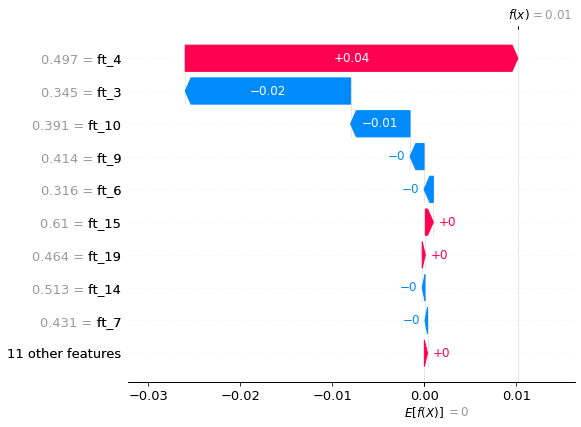

In [120]:
# Taylor explainer to only one instance (local explanation)
# optimize_h_v2, finite_diff_version=2, dot product, USING adjustment

target_pos= 2

target_inst_ox= train_ox.iloc[target_pos].to_frame().T
target_labl_ox= labels_train_ox.iloc[target_pos].to_frame().T

h_min_dist_ox= get_minimum_distance(train_ox)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model_ox, train_ox, labels_train_ox, 
                                            target_inst_ox, target_labl_ox,
                                            h_min=h_min_dist_ox, h_max=1, eps=0.05, max_itr=50, 
                                            finite_diff_version=2, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.22655774 0.67022455 0.34459501 0.49745107 0.29823137 0.31618381
 0.43081702 0.31397736 0.41412679 0.39093421 0.63760055 0.56632303
 0.42037214 0.51346397 0.60998296 0.33208036 0.32738733 0.239984
 0.46365783 0.59545695]

Predicted class: 
1

Predicted probabilities (log odds) f(x): 
[-0.00797156  0.00797162]

Grad_[ f(x) ]: 
[ 7.16200532e-04  1.24536778e-04 -5.21590217e-02  7.26793951e-02
 -1.89318032e-04 -3.19224868e-03 -6.36435493e-04 -8.84980970e-05
 -3.68183517e-03 -1.65314769e-02  3.67237465e-04  1.54644452e-04
 -4.08298283e-04 -5.88480912e-04  1.43584256e-03  1.54644452e-04
 -5.97591169e-05  2.19055438e-18  7.22993708e-04 -1.09831517e-18]

h optimized: 
0.12962499987381376

Differential of f at x, Jf(x)·h: 
[ 0.00015307 -0.00015294]

Taylor Feature Importances: 
[ 1.6200e-04  8.3000e-05 -1.7974e-02  3.6154e-02 -5.6000e-05 -1.0090e-03
 -2.7400e-04 -2.8000e-05 -1.5250e-03 -6.4630e-03  2.3400e-04  8.8000e-05
 -1.7200e-04 -3.0200e-04  8.7600e-04  5.1000e-05 -2.00

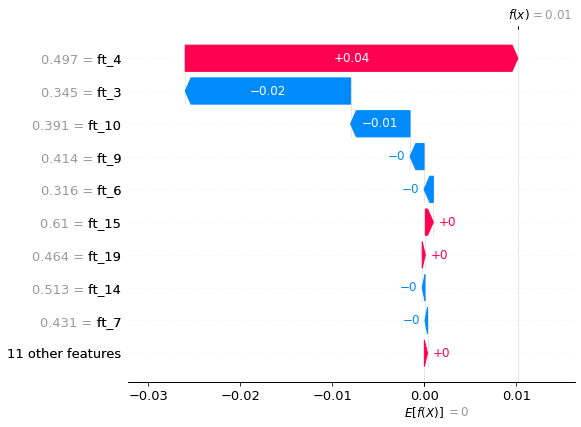

In [121]:
# TAYLOR EXPLAINER
# optimize_h, finite_diff_version=3, dot product, USING adjustment

target_pos= 2

target_inst_ox= train_ox.iloc[target_pos].to_frame().T
target_labl_ox= labels_train_ox.iloc[target_pos].to_frame().T

h_min_dist_ox= get_minimum_distance(train_ox)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model_ox, train_ox, labels_train_ox, target_inst_ox, 
                                            target_labl_ox,
                                            h_min=h_min_dist_ox, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.40229341 0.32728039 0.35650748 0.32827217 0.15750301 0.13874012
 0.28311242 0.69118427 0.31073713 0.3455286  0.35368201 0.45970715
 0.543381   0.50415154 0.50720745 0.61525958 0.43600209 0.34435857
 0.45639804 0.27623309]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.00767997  0.00767994]

Grad_[ f(x) ]: 
[-8.55654129e-04 -2.48817727e-04  3.96614755e-03  2.08227001e-02
  2.06485521e-02  5.58822285e-05  1.17483884e-04  2.04653200e-02
  0.00000000e+00 -9.72415728e-05  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.72046956e-05  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.87756440e-04  0.00000000e+00]

h optimized: 
0.2688403399511159

Differential of f at x, Jf(x)·h: 
[-0.01753352  0.01753359]

Taylor Feature Importances: 
[-3.4400e-04 -8.1000e-05  1.4140e-03  6.8360e-03  3.2520e-03  8.0000e-06
  3.3000e-05  1.4145e-02  0.0000e+00 -3.4000e-05  0.0000e+00  0.0000e+00
  0.0000e+00  0.0000e+00  2.9000e-05  0.0000e+00  0.0000e+00  0.

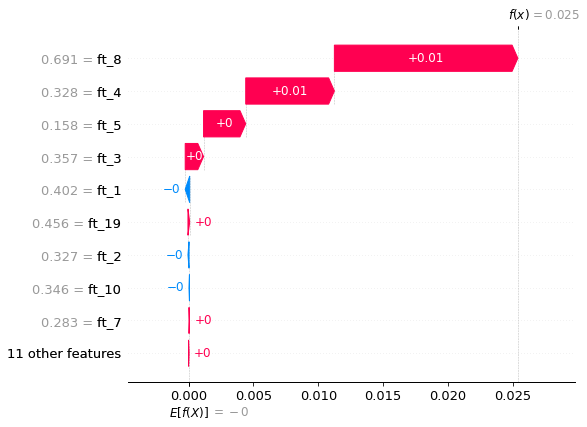

In [398]:
# TAYLOR EXPLAINER 
# optimize_h_v2, finite_diff_version=2, dot product, NO USING adjustment

target_pos= 2

target_inst_ox= train_ox.iloc[target_pos].to_frame().T
target_labl_ox= labels_train_ox.iloc[target_pos].to_frame().T

h_min_dist_ox= get_minimum_distance(train_ox)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model_ox, train_ox, labels_train_ox, target_inst_ox, 
                                            target_labl_ox,
                                            h_min=h_min_dist_ox, h_max=1, max_itr=50, 
                                            finite_diff_version=2, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

Target instance: 
[0.40229341 0.32728039 0.35650748 0.32827217 0.15750301 0.13874012
 0.28311242 0.69118427 0.31073713 0.3455286  0.35368201 0.45970715
 0.543381   0.50415154 0.50720745 0.61525958 0.43600209 0.34435857
 0.45639804 0.27623309]

Predicted class: 
1

Predicted probabilities f(x): 
[-0.00767997  0.00767994]

Grad_[ f(x) ]: 
[-8.55654132e-04 -2.48817733e-04  3.96614774e-03  2.08227004e-02
  2.06485540e-02  5.58822284e-05  1.17483887e-04  2.04653200e-02
  5.71547217e-19 -9.72415728e-05 -6.04782995e-19  2.00419532e-18
 -3.94629633e-18 -6.05435844e-18  5.72046951e-05  1.14932727e-18
 -3.21740565e-18  1.84050780e-18  2.87756452e-04 -5.71855269e-19]

h optimized: 
0.2688403399511159

Differential of f at x, Jf(x)·h: 
[-0.01753352  0.01753359]

Taylor Feature Importances: 
[-3.4400e-04 -8.1000e-05  1.4140e-03  6.8360e-03  3.2520e-03  8.0000e-06
  3.3000e-05  1.4145e-02  0.0000e+00 -3.4000e-05 -0.0000e+00  0.0000e+00
 -0.0000e+00 -0.0000e+00  2.9000e-05  0.0000e+00 -0.0000e+00  0.

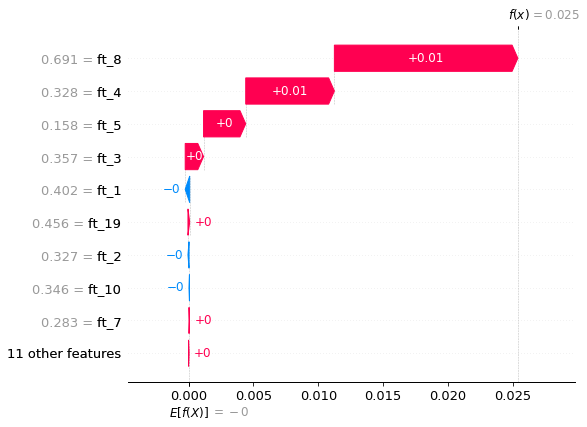

In [397]:
# TAYLOR EXPLAINER
# optimize_h_v2, finite_diff_version=3, dot product, NO USING adjustment

target_pos= 2

target_inst_ox= train_ox.iloc[target_pos].to_frame().T
target_labl_ox= labels_train_ox.iloc[target_pos].to_frame().T

h_min_dist_ox= get_minimum_distance(train_ox)

t_phis, t_ft_rk, t_sh_exp= taylor_explainer(xgb_model_ox, train_ox, labels_train_ox, target_inst_ox, 
                                            target_labl_ox,
                                            h_min=h_min_dist_ox, h_max=1, max_itr=50, 
                                            finite_diff_version=3, e_x=True, angle=False, verbose=True)

shap.plots.waterfall(t_sh_exp)

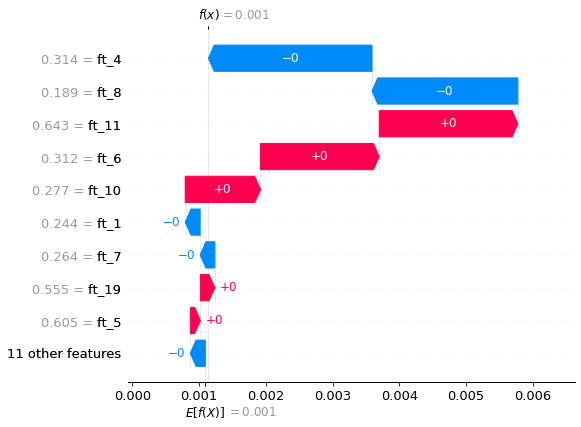

In [110]:
# SHAP explainer to only one instance (local explanation)

shap.plots.waterfall(shap_values_ox[target_pos])

ntree_limit is deprecated, use `iteration_range` or model slicing instead.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


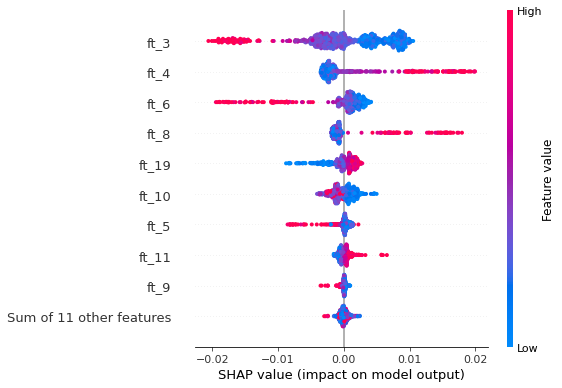

In [103]:
# Tests using SHAP

explainer_ox= shap.Explainer(xgb_model_ox)
shap_values_ox= explainer_ox(train_ox)
shap.plots.beeswarm(shap_values_ox, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

In [102]:
# XGBoost -- fin_dif= 2, optimize_h -- dot product e_x=False -- USING derivative_adjustment_ft_imp

descriptor_ox['e_x']= False
descriptor_ox['angle']= False

In [123]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)') 
relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 3268.1966962937527,
 'std(t_exp_ris_max)': 384.42457106608316,
 'shap_ris_max': 1765415.265287713,
 'std(shap_ris_max)': 164333.71500919008,
 'lime_ris_max': 10241.991996992618,
 'std(lime_ris_max)': 2145.875705500058,
 't_exp_ris_mean': 44.12308422297234,
 'std(t_exp_ris_mean)': 153.72266727116227,
 'shap_ris_mean': 24048.622408021827,
 'std(shap_ris_mean)': 93280.28441936853,
 'lime_ris_mean': 1435.7295829924342,
 'std(lime_ris_mean)': 1125.0085015291363,
 't_exp_ros_max': 6056617.874513878,
 'std(t_exp_ros_max)': 474936.1883176037,
 'shap_ros_max': 1666668019.8703036,
 'std(shap_ros_max)': 126744042.47414458,
 'lime_ros_max': 31671915.936736353,
 'std(lime_ros_max)': 2776423.0420618244,
 't_exp_ros_mean': 20435.978263230612,
 'std(t_exp_ros_mean)': 174239.2722977834,
 'shap_ros_mean': 3253231.1210355638,
 'std(shap_ros_mean)': 15885353.502615802,
 'lime_ros_mean': 232351.50959373056,
 'std(lime_ros_mean)': 524025.34830197727}

In [124]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model_ox, train_ox, labels_train_ox, 
                                                              test_ox, labels_test_ox,
                                                              perturbation, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.00260592, 0.00270663, 0.00460822, 0.00514119, 0.00384717,
       0.00449048, 0.00269588, 0.00431943, 0.00311261, 0.00368487,
       0.00269471, 0.00258477, 0.00266182, 0.00260263, 0.00312177,
       0.00276153, 0.00268193, 0.00261604, 0.00286955, 0.00283861]), array([0.03726718, 0.05846686, 0.05461237, 0.11191577, 0.05276222,
       0.0311    , 0.02331393, 0.13442598, 0.01339505, 0.06435138,
       0.0122644 , 0.00383591, 0.00776749, 0.00717647, 0.0514003 ,
       0.00450403, 0.00473529, 0.01663282, 0.05286501, 0.02315975]), array([0.00261902, 0.00261375, 0.00261677, 0.00262015, 0.00261518,
       0.00262135, 0.00262289, 0.00264211, 0.00261261, 0.00263556,
       0.00262213, 0.00261492, 0.00261802, 0.00260712, 0.00262543,
       0.00262838, 0.00263805, 0.00262039, 0.0026142 , 0.00262574]))


In [125]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (0.0, 0.13861628091004805, 0.00018235591441701868)


In [126]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', 
      eval_additive_exp_faithfulness(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.14356871, 0.585, 4.6070156, 0.715)


In [110]:
# fin_dif= 2, optimize_h -- dot product e_x=False -- USING derivative_adjustment_ft_imp

descriptor_ox['e_x']= False
descriptor_ox['angle']= False

In [136]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)') 
relative_stability(nn3_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 96556.48281647594,
 'std(t_exp_ris_max)': 6894.824407899834,
 'shap_ris_max': 3290283.342614855,
 'std(shap_ris_max)': 518645.824038623,
 'lime_ris_max': 38965.0253601125,
 'std(lime_ris_max)': 3908.372020370125,
 't_exp_ris_mean': 264.02694035331706,
 'std(t_exp_ris_mean)': 2024.2164605407704,
 'shap_ris_mean': 91808.79990057457,
 'std(shap_ris_mean)': 237304.32151593358,
 'lime_ris_mean': 885.0796767051146,
 'std(lime_ris_mean)': 1840.3003397503353,
 't_exp_ros_max': 311249.59392671264,
 'std(t_exp_ros_max)': 23596.173749888414,
 'shap_ros_max': 1008884209.8459476,
 'std(shap_ros_max)': 71220411.15168491,
 'lime_ros_max': 1270398.0434211425,
 'std(lime_ros_max)': 97611.68155492035,
 't_exp_ros_mean': 641.7811450858312,
 'std(t_exp_ros_mean)': 3103.0369697407846,
 'shap_ros_mean': 739677.6355373145,
 'std(shap_ros_mean)': 7258174.673556144,
 'lime_ros_mean': 3176.889469109557,
 'std(lime_ros_mean)': 10187.195227586028,
 'itGd_ris_max': 3973.5156297940366,
 'std(itGd_

In [137]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model_ox, train_ox, labels_train_ox, 
                                                              test_ox, labels_test_ox,
                                                              perturbation, descriptor_ox, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([2.44102769, 2.22597174, 4.67763665, 3.70914303, 2.06788779,
       3.93940475, 3.42738761, 2.27023423, 2.72065577, 3.13600425,
       1.69893706, 1.07066819, 1.06396369, 0.53811878, 1.87651009,
       1.20807193, 0.98801541, 0.99577531, 3.25268098, 0.62352004]), array([0.06505758, 0.06274489, 0.06130588, 0.06320743, 0.06176842,
       0.08019288, 0.06133158, 0.0709678 , 0.05130991, 0.06911765,
       0.06097183, 0.06035511, 0.04794366, 0.05051331, 0.04809784,
       0.0694517 , 0.04748112, 0.0498966 , 0.07071083, 0.06973436]), array([0.03727467, 0.03656117, 0.03708231, 0.03585783, 0.0365515 ,
       0.03790341, 0.03717911, 0.03696006, 0.03676196, 0.03714692,
       0.0365806 , 0.03804085, 0.03564875, 0.03648438, 0.03846208,
       0.03705548, 0.03687575, 0.03708595, 0.03889835, 0.03604485]), array([0.0657695 , 0.05913383, 0.08442609, 0.08334794, 0.05461592,
       0.08363308, 0.06617509, 0.06306043, 0.05701806, 0.10286488,
       0.09440396, 0.0635

In [138]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.0593185172612074e-14, 0.1900154628210849, 0.029887272809679327, 8.151071147370332e-15, 4.9701125e-06, 4.70294e-06, 5.349247e-06)


In [139]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', 
      eval_additive_exp_faithfulness(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (4.224244068437836, 0.95, 0.9382078415461749, 0.97)


# TODO list

In [122]:
# DONE -- update the benchmarking methods to run our explainer
# DONE -- define the descriptor parameters required by benchmarking methods to run our synthetic data
# DONE -- create an inputs-labels synthetic dataset using OpenXAI
# DONE -- split inputs and labels from OpenXAI into train and test datasets
# DONE -- define the descriptor parameters required by benchmarking methods to run synthetic data from OpenXAI
# DONE -- train an ML model (xgboost and neural network) on data from OpenXAI
# DONE -- test using OpenXAI synthetic data (xgboost and neural network)
# DONE -- test using real data

# Run -- Benchmarkings -- 0.02 perts are not reported in the paper

# 4-FT and 20-FT synthetic datasets

In [123]:
# Benchmarking metrics over OUR synthetic

In [124]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train= torch.from_numpy(train.values)
tensor_labels= torch.from_numpy(labels_train.values.ravel().astype(int))

In [119]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.02
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

def generate_mask(explanation, top_k):
    mask_indices= torch.topk(explanation, top_k).indices
    mask= torch.zeros(explanation.shape) > 10
    for i in mask_indices:
        mask[i]= True
    return mask

descriptor= dict()

h_min_dist= get_minimum_distance(train)

# T-Exp explanation settings
descriptor['h_min']= h_min_dist
descriptor['h_max']= 1
descriptor['jacobian_eps']= 1e-3
descriptor['max_itr']= 30
descriptor['finite_diff_version']= 2

# perturbation settings used for the stability metrics
descriptor['num_samples']= 50
descriptor['num_perts']= 10
descriptor['pert_max_distance']= (h_min_dist/2)
descriptor['num_runs']= 25
descriptor['feature_metadata']= ['c'] * 4
descriptor['p_norm']= 2
descriptor['eps_norm']= 1e-6
descriptor['eps_eval_add']= 1e-2
descriptor['top_k']= 0
descriptor['mask']= generate_mask(tensor_train[0].reshape(-1), descriptor['top_k'])

In [120]:
#### XGBoost -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [270]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 10015.30725602378,
 'std(t_exp_ris_max)': 1356.9570475497417,
 'shap_ris_max': 8537.471674220867,
 'std(shap_ris_max)': 854.901899375705,
 'lime_ris_max': 2005.3662140176427,
 'std(lime_ris_max)': 268.10375931811325,
 't_exp_ris_mean': 116.10954940625926,
 'std(t_exp_ris_mean)': 360.681100255739,
 'shap_ris_mean': 44.000529639175255,
 'std(shap_ris_mean)': 237.1750733259175,
 'lime_ris_mean': 63.36545456581157,
 'std(lime_ris_mean)': 90.81003584885111,
 't_exp_ros_max': 70244275.36939344,
 'std(t_exp_ros_max)': 7058133.721579544,
 'shap_ros_max': 1184684.2,
 'std(shap_ros_max)': 205286.67164659433,
 'lime_ros_max': 4677588.221755903,
 'std(lime_ros_max)': 783313.4003231867,
 't_exp_ros_mean': 152117.2077441916,
 'std(t_exp_ros_mean)': 751456.953101269,
 'shap_ros_mean': 17661.679119977118,
 'std(shap_ros_mean)': 41664.42461032148,
 'lime_ros_mean': 83055.35288581686,
 'std(lime_ros_mean)': 208883.13051509226}

In [87]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.02454324, 0.0262422 , 0.0044809 , 0.00344999]), array([0.08228298, 0.03618558, 0.04793282, 0.0323048 ]), array([0.00212748, 0.00213447, 0.00210952, 0.00212342]))


In [88]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.112389389814867e-16, 4.460365043975677e-16, 0.00027980320861550114)


In [89]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.0294474, 0.995, 30.354116, 1.0)


In [107]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [103]:
#### optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [266]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 96.44415998773472,
 'std(t_exp_ris_max)': 16.169696524626076,
 'shap_ris_max': 1790.8928622263952,
 'std(shap_ris_max)': 184.40113888987636,
 'lime_ris_max': 1217.4850384556726,
 'std(lime_ris_max)': 220.39255118066137,
 't_exp_ris_mean': 5.00168319613041,
 'std(t_exp_ris_mean)': 6.412500677112781,
 'shap_ris_mean': 25.801625612387184,
 'std(shap_ris_mean)': 41.42005968081605,
 'lime_ris_mean': 52.790371662176476,
 'std(lime_ris_mean)': 93.89248447350057,
 't_exp_ros_max': 343.7816893725495,
 'std(t_exp_ros_max)': 53.91898404733929,
 'shap_ros_max': 4487.847250852833,
 'std(shap_ros_max)': 453.71526858686923,
 'lime_ros_max': 7596.798132696322,
 'std(lime_ros_max)': 964.4882457690023,
 't_exp_ros_mean': 3.693881001771238,
 'std(t_exp_ros_mean)': 7.507346708965197,
 'shap_ros_mean': 17.247983904953124,
 'std(shap_ros_mean)': 47.013612355469675,
 'lime_ros_mean': 49.174373044578445,
 'std(lime_ros_mean)': 115.58573140567871,
 'itGd_ris_max': 1399.6999176164734,
 'std(it

In [98]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model, train, labels_train, 
                                                              test, labels_test,
                                                              perturbation, descriptor, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([6.30040381, 7.12556313, 0.23154383, 0.15673338]), array([0.02504556, 0.02568247, 0.02791163, 0.02368077]), array([0.0279475 , 0.02634961, 0.02704058, 0.02667769]), array([0.07479952, 0.0838266 , 0.02622899, 0.02547209]), array([0.23112362, 0.29288215, 0.03700558, 0.03945746]), array([0.23112383, 0.29288234, 0.03700556, 0.03945746]), array([0.23112336, 0.29288137, 0.03700557, 0.03945734]))


In [99]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model, train, labels_train, descriptor, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.811680219758521e-14, 3.433175098891678e-16, 0.026004021944449278, 2.2758222265308094e-14, 1.2215353e-05, 1.0792227e-05, 1.1124223e-05)


In [100]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.5824035213099565, 0.915, 0.9055331963001939, 1.0)


In [125]:
# Benchmarking metrics over OpenXAI synthetic

In [126]:
# conversion of train_ox and labels_train_ox data back to tensor as required by benchmarking methods
# explanations will be only done over train dataset

tn_train= torch.from_numpy(train_ox.values)
tn_lb_tr= torch.from_numpy(labels_train_ox.values.ravel().astype(int))

In [215]:
# define a descriptor to OpenXAI synthetic

descriptor_ox= dict()

h_min_dist_ox= get_minimum_distance(train_ox)

# T-Exp explanation settings
descriptor_ox['h_min']= h_min_dist_ox
descriptor_ox['h_max']= 1
descriptor_ox['jacobian_eps']= 1e-3
descriptor_ox['max_itr']= 30
descriptor_ox['finite_diff_version']= 2

# perturbation settings used for the stability metric
descriptor_ox['num_samples']= 50
descriptor_ox['num_perts']= 10
descriptor_ox['pert_max_distance']= (h_min_dist/2)
descriptor_ox['num_runs']= 25
descriptor_ox['feature_metadata']= ['c'] * n_ox
descriptor_ox['p_norm']= 2
descriptor_ox['eps_norm']= 1e-6
descriptor_ox['eps_eval_add']= 1e-1
descriptor_ox['top_k']= 0
descriptor_ox['mask']= generate_mask(tn_train[0].reshape(-1), descriptor_ox['top_k'])

In [216]:
#### XGBoost -- fin_dif= 2, optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_ox['e_x']= True
descriptor_ox['angle']= False

In [267]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)') 
relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 2326.7892453890427,
 'std(t_exp_ris_max)': 247.85173495049668,
 'shap_ris_max': 580.5761002430322,
 'std(shap_ris_max)': 109.39037852543905,
 'lime_ris_max': 476.78158255408005,
 'std(lime_ris_max)': 99.71052431292016,
 't_exp_ris_mean': 30.769271199686404,
 'std(t_exp_ris_mean)': 54.88231295396924,
 'shap_ris_mean': 30.31406045504158,
 'std(shap_ris_mean)': 33.51650036769143,
 'lime_ris_mean': 69.83654192724464,
 'std(lime_ris_mean)': 49.634368584281646,
 't_exp_ros_max': 12972060.647242071,
 'std(t_exp_ros_max)': 1818960.545688437,
 'shap_ros_max': 18370328.0,
 'std(shap_ros_max)': 1931267.0154878392,
 'lime_ros_max': 32382365.327719547,
 'std(lime_ros_max)': 4522048.990675608,
 't_exp_ros_mean': 87489.82693688339,
 'std(t_exp_ros_mean)': 215103.9976603262,
 'shap_ros_mean': 90023.27713157654,
 'std(shap_ros_mean)': 216155.6695177069,
 'lime_ros_mean': 313074.4956730934,
 'std(lime_ros_mean)': 704905.9726761916}

In [119]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model_ox, train_ox, labels_train_ox, 
                                                              test_ox, labels_test_ox,
                                                              perturbation, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.00150048, 0.00157153, 0.00252676, 0.00419151, 0.00155842,
       0.0034801 , 0.00146858, 0.0024559 , 0.0015116 , 0.00231232,
       0.00147933, 0.00143999, 0.0015272 , 0.0014681 , 0.0018927 ,
       0.00147502, 0.00146434, 0.00147422, 0.00162184, 0.00154358]), array([0.02322378, 0.0419309 , 0.07662129, 0.08021881, 0.05822253,
       0.0403891 , 0.05269777, 0.08283987, 0.00813988, 0.05876216,
       0.01302223, 0.00248663, 0.0056987 , 0.00708632, 0.04784111,
       0.00415691, 0.00248663, 0.02240149, 0.05190117, 0.01469251]), array([0.00148602, 0.00147363, 0.00147938, 0.0014788 , 0.00147969,
       0.00148334, 0.00147741, 0.00151124, 0.00146826, 0.00147178,
       0.00147903, 0.0014745 , 0.00148742, 0.00147418, 0.00148081,
       0.00147109, 0.00147508, 0.00147336, 0.00147189, 0.00148603]))


In [120]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.3922090061079956e-17, 0.13362168195651816, 0.0001784006746645776)


In [121]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', 
      eval_additive_exp_faithfulness(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.055485245, 0.155, 4.6070156, 0.715)


In [119]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [120]:
#### fin_dif= 2, optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_ox['e_x']= True
descriptor_ox['angle']= False

In [268]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)') 
relative_stability(nn3_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox, is_model_NN=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 717.115421690585,
 'std(t_exp_ris_max)': 95.19059225553652,
 'shap_ris_max': 166002.96098146916,
 'std(shap_ris_max)': 29256.422479372468,
 'lime_ris_max': 15597.409910510816,
 'std(lime_ris_max)': 2200.8298896431297,
 't_exp_ris_mean': 22.792227280547113,
 'std(t_exp_ris_mean)': 40.315732161165435,
 'shap_ris_mean': 4763.221410694384,
 'std(shap_ris_mean)': 13956.56047042108,
 'lime_ris_mean': 244.26673958233664,
 'std(lime_ris_mean)': 1214.879465525524,
 't_exp_ros_max': 11088.711446673937,
 'std(t_exp_ros_max)': 1415.6337217867624,
 'shap_ros_max': 6525235.108636516,
 'std(shap_ros_max)': 659782.2391065144,
 'lime_ros_max': 674905.437547675,
 'std(lime_ros_max)': 67694.02388358077,
 't_exp_ros_mean': 84.19467615098318,
 'std(t_exp_ros_mean)': 166.5909270756868,
 'shap_ros_mean': 15079.629082253286,
 'std(shap_ros_mean)': 74587.25931535971,
 'lime_ros_mean': 1265.0980939841772,
 'std(lime_ros_mean)': 8126.471829535053,
 'itGd_ris_max': 2748.4651938766483,
 'std(itGd

In [132]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model_ox, train_ox, labels_train_ox, 
                                                              test_ox, labels_test_ox,
                                                              perturbation, descriptor_ox, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([1.39752413, 3.54652647, 5.18701732, 5.10013283, 1.09089983,
       6.45660152, 1.71585294, 4.61934284, 0.41526133, 1.48229707,
       5.65878837, 0.42519483, 3.89062017, 1.70746438, 1.03547914,
       1.00080971, 2.24270601, 1.88474087, 2.90370127, 1.32753973]), array([0.06891362, 0.05454923, 0.06937616, 0.06518762, 0.07143189,
       0.06439102, 0.06359443, 0.06554737, 0.05920031, 0.07351331,
       0.06860526, 0.0562966 , 0.06631827, 0.05997121, 0.05735016,
       0.06428824, 0.05485759, 0.05709319, 0.05585975, 0.05287895]), array([0.0376994 , 0.0369627 , 0.03647692, 0.03607119, 0.03808374,
       0.03789063, 0.03753894, 0.03815975, 0.03707683, 0.03777111,
       0.03675585, 0.03956577, 0.03798061, 0.0380807 , 0.03566472,
       0.03613727, 0.03678728, 0.03676431, 0.03720155, 0.03817832]), array([0.06438487, 0.06191525, 0.09800525, 0.0917191 , 0.06913383,
       0.08466993, 0.07911891, 0.07880769, 0.06740251, 0.09167614,
       0.12441269, 0.0490

In [133]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.854818943094591e-15, 0.1693220960838314, 0.02765078542859042, 8.151071147370332e-15, 4.9701125e-06, 4.70294e-06, 5.349247e-06)


In [134]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', 
      eval_additive_exp_faithfulness(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (2.2900640297420085, 0.915, 0.9382078415461749, 0.97)


# 0.01 perturbation setting -- These results are reported in the paper

In [156]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.01
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

In [157]:
# Our synthetic dataset

In [158]:
#### XGBoost -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor['e_x']= True
descriptor['angle']= False

In [255]:
descriptor['finite_diff_version']= 2    # on paper

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 13818.811713329096,
 'std(t_exp_ris_max)': 1540.0277650748712,
 'shap_ris_max': 5053.284352164197,
 'std(shap_ris_max)': 588.503686008954,
 'lime_ris_max': 10895.47540063929,
 'std(lime_ris_max)': 1497.6123334152187,
 't_exp_ris_mean': 111.43846637790793,
 'std(t_exp_ris_mean)': 278.9389104041992,
 'shap_ris_mean': 38.009899501007936,
 'std(shap_ris_mean)': 150.29295354819743,
 'lime_ris_mean': 200.36877047225045,
 'std(lime_ris_mean)': 410.00066086236046,
 't_exp_ros_max': 6666201.568039278,
 'std(t_exp_ros_max)': 830315.375394597,
 'shap_ros_max': 537949.6,
 'std(shap_ros_max)': 93906.18997538676,
 'lime_ros_max': 6077330.792107033,
 'std(lime_ros_max)': 998049.3160649638,
 't_exp_ros_mean': 38904.20721766475,
 'std(t_exp_ros_mean)': 118286.43269497869,
 'shap_ros_mean': 8226.127906800151,
 'std(shap_ros_mean)': 23499.838263172882,
 'lime_ros_mean': 86050.06167186462,
 'std(lime_ros_mean)': 211882.83793347684}

In [168]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.112389389814867e-16, 2.7113324856470734e-20, 0.0002702491291567864)


In [541]:
descriptor['eps_eval_add']= 1e-2

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.0178211060848298, 0.42500000000000004, 0.5072213085641124, 0.007499999999999951)


In [544]:
descriptor['eps_eval_add']= 1e-2

# evaluate the mean faithfulness of an additive explanator -- TreeSHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.0178211060848298, 0.42500000000000004, 0.018644292, 0.5075000000000001)


In [149]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [180]:
descriptor['finite_diff_version']= 3

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 135.02462698356956,
 'std(t_exp_ris_max)': 22.048660763825726,
 'shap_ris_max': 1818.8979255532045,
 'std(shap_ris_max)': 193.9093001171489,
 'lime_ris_max': 11794.284162857874,
 'std(lime_ris_max)': 1240.1460111307956,
 't_exp_ris_mean': 6.096811535664176,
 'std(t_exp_ris_mean)': 7.073612206212829,
 'shap_ris_mean': 35.814645598582466,
 'std(shap_ris_mean)': 47.21928654399823,
 'lime_ris_mean': 134.8835313982635,
 'std(lime_ris_mean)': 410.4489792481222,
 't_exp_ros_max': 6351.308211767306,
 'std(t_exp_ros_max)': 631.7168617751184,
 'shap_ros_max': 23059.214867934137,
 'std(shap_ros_max)': 2369.9556324851105,
 'lime_ros_max': 60171.97046591443,
 'std(lime_ros_max)': 6339.539832917532,
 't_exp_ros_mean': 9.989663051365456,
 'std(t_exp_ros_mean)': 64.37223571707484,
 'shap_ros_mean': 48.6954373742187,
 'std(shap_ros_mean)': 249.72223812888384,
 'lime_ros_mean': 164.39864731894588,
 'std(lime_ros_mean)': 728.9932195617299,
 'itGd_ris_max': 2561.2133567530714,
 'std(itGd

In [195]:
# changing the approximation method -- on paper

descriptor['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 175.7651935760176,
 'std(t_exp_ris_max)': 21.696114571827447,
 'shap_ris_max': 2010.281771742838,
 'std(shap_ris_max)': 216.68820803390452,
 'lime_ris_max': 4625.036714280503,
 'std(lime_ris_max)': 646.2683375919783,
 't_exp_ris_mean': 5.97092915584579,
 'std(t_exp_ris_mean)': 7.099164895912215,
 'shap_ris_mean': 38.589488533430284,
 'std(shap_ris_mean)': 59.13214149572412,
 'lime_ris_mean': 127.08438024314691,
 'std(lime_ris_mean)': 221.5749984229847,
 't_exp_ros_max': 805.547282448993,
 'std(t_exp_ros_max)': 110.17174306667087,
 'shap_ros_max': 12122.055740303098,
 'std(shap_ros_max)': 1531.81244383843,
 'lime_ros_max': 169012.2505823231,
 'std(lime_ros_max)': 16793.766806905085,
 't_exp_ros_mean': 5.815674601118388,
 'std(t_exp_ros_mean)': 12.20237271860281,
 'shap_ros_mean': 51.394548388485084,
 'std(shap_ros_mean)': 154.33459556572663,
 'lime_ros_mean': 296.86101320579974,
 'std(lime_ros_mean)': 1759.4685195807474,
 'itGd_ris_max': 2465.5925463960666,
 'std(itGd_

In [170]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model, train, labels_train, descriptor, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.811680219758521e-14, 3.433175098891678e-16, 0.023437730703251718, 2.2758222265308094e-14, 1.2215353e-05, 1.0792227e-05, 1.1124223e-05)


In [545]:
descriptor['eps_eval_add']= 1e-1

# evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.6769188343579458, 0.10750000000000004, 4.84525634550169, 0.010000000000000009)


# new tests -- comparing approximation methods

In [187]:
# 3H-NN -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# 4-FT Dataset

In [189]:
descriptor['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 149.05750904192212,
 'std(t_exp_ris_max)': 22.498342077333763,
 'shap_ris_max': 2356.7544825352634,
 'std(shap_ris_max)': 253.5770935081744,
 'lime_ris_max': 3808.8270499746213,
 'std(lime_ris_max)': 615.7533273675491,
 't_exp_ris_mean': 6.173393513371927,
 'std(t_exp_ris_mean)': 8.329775446013137,
 'shap_ris_mean': 42.340520874265096,
 'std(shap_ris_mean)': 90.8426816091108,
 'lime_ris_mean': 149.4528633597078,
 'std(lime_ris_mean)': 304.94858356961436,
 't_exp_ros_max': 1595.0215797349333,
 'std(t_exp_ros_max)': 181.11447917519612,
 'shap_ros_max': 45792.35634348012,
 'std(shap_ros_max)': 6008.143357925945,
 'lime_ros_max': 30337.39142269387,
 'std(lime_ros_max)': 3659.538373900334,
 't_exp_ros_mean': 6.063668178751514,
 'std(t_exp_ros_mean)': 18.542367303603147,
 'shap_ros_mean': 110.6271172455262,
 'std(shap_ros_mean)': 609.9453815199665,
 'lime_ros_mean': 166.19823831887422,
 'std(lime_ros_mean)': 451.39413748971066,
 'itGd_ris_max': 3199.073619169093,
 'std(itGd

In [190]:
descriptor['finite_diff_version']= 3

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model, train, labels_train, descriptor, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.8115717841023103e-14, 3.433175098891678e-16, 0.02516903149604477, 2.2758222265308094e-14, 1.2215353e-05, 1.0792227e-05, 1.1124223e-05)


In [194]:
descriptor['finite_diff_version']= 3
descriptor['eps_eval_add']= 1e-2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor, 
                                                                                         is_model_NN=True))

FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.6715636837339747, 0.007499999999999951, 4.84525634550169, 0.0)


In [195]:
# changing the approximation method

descriptor['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model, train, labels_train, perturbation, descriptor, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 175.7651935760176,
 'std(t_exp_ris_max)': 21.696114571827447,
 'shap_ris_max': 2010.281771742838,
 'std(shap_ris_max)': 216.68820803390452,
 'lime_ris_max': 4625.036714280503,
 'std(lime_ris_max)': 646.2683375919783,
 't_exp_ris_mean': 5.97092915584579,
 'std(t_exp_ris_mean)': 7.099164895912215,
 'shap_ris_mean': 38.589488533430284,
 'std(shap_ris_mean)': 59.13214149572412,
 'lime_ris_mean': 127.08438024314691,
 'std(lime_ris_mean)': 221.5749984229847,
 't_exp_ros_max': 805.547282448993,
 'std(t_exp_ros_max)': 110.17174306667087,
 'shap_ros_max': 12122.055740303098,
 'std(shap_ros_max)': 1531.81244383843,
 'lime_ros_max': 169012.2505823231,
 'std(lime_ros_max)': 16793.766806905085,
 't_exp_ros_mean': 5.815674601118388,
 'std(t_exp_ros_mean)': 12.20237271860281,
 'shap_ros_mean': 51.394548388485084,
 'std(shap_ros_mean)': 154.33459556572663,
 'lime_ros_mean': 296.86101320579974,
 'std(lime_ros_mean)': 1759.4685195807474,
 'itGd_ris_max': 2465.5925463960666,
 'std(itGd_

In [196]:
descriptor['finite_diff_version']= 2

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model, train, labels_train, descriptor, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.811680219758521e-14, 3.433175098891678e-16, 0.02834166677203469, 2.2758222265308094e-14, 1.2215353e-05, 1.0792227e-05, 1.1124223e-05)


In [197]:
descriptor['finite_diff_version']= 2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (1.6769188343579458, 0.010000000000000009, 4.84525634550169, 0.0)


In [188]:
# XRFC -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# 4-FT Dataset

In [198]:
descriptor['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 208006.12466073476,
 'std(t_exp_ris_max)': 23124.570463702443,
 'shap_ris_max': 9172.771653817385,
 'std(shap_ris_max)': 939.1019338064553,
 'lime_ris_max': 7212.818387372052,
 'std(lime_ris_max)': 1123.9204321419827,
 't_exp_ris_mean': 1418.4457232511857,
 'std(t_exp_ris_mean)': 10558.70690572301,
 'shap_ris_mean': 67.29629672885603,
 'std(shap_ris_mean)': 405.57704106057827,
 'lime_ris_mean': 213.49477130635464,
 'std(lime_ris_mean)': 409.38831574027455,
 't_exp_ros_max': 34626006.13545378,
 'std(t_exp_ros_max)': 3611650.238932105,
 'shap_ros_max': 595905.1847457886,
 'std(shap_ros_max)': 90070.28535427594,
 'lime_ros_max': 36907821.641581304,
 'std(lime_ros_max)': 4120431.5104054324,
 't_exp_ros_mean': 93121.59283822961,
 'std(t_exp_ros_mean)': 400327.56159624446,
 'shap_ros_mean': 7914.004555378795,
 'std(shap_ros_mean)': 23508.973501167777,
 'lime_ros_mean': 211350.72601732053,
 'std(lime_ros_mean)': 1101340.795636116}

In [199]:
descriptor['finite_diff_version']= 3

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (8.326792680158243e-17, 7.450712e-09, 0.00032449698628805813)


In [200]:
descriptor['finite_diff_version']= 3

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.017821106552088472, 0.42500000000000004, 0.018644292, 0.5075000000000001)


In [201]:
# changing the approximation method

descriptor['finite_diff_version']= 2

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model, train, labels_train, perturbation, descriptor)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 17421.397392544182,
 'std(t_exp_ris_max)': 1875.022124091984,
 'shap_ris_max': 11274.561393634871,
 'std(shap_ris_max)': 1134.9741790833714,
 'lime_ris_max': 4620.22086864208,
 'std(lime_ris_max)': 755.7664349306376,
 't_exp_ris_mean': 125.24336279558955,
 'std(t_exp_ris_mean)': 354.9765108587708,
 'shap_ris_mean': 60.400949879993675,
 'std(shap_ris_mean)': 368.3255988340216,
 'lime_ris_mean': 189.58880081491978,
 'std(lime_ris_mean)': 349.81182737179563,
 't_exp_ros_max': 46237725.28572346,
 'std(t_exp_ros_max)': 4639415.838365112,
 'shap_ros_max': 509715.2,
 'std(shap_ros_max)': 73976.60315087839,
 'lime_ros_max': 5923983.525549508,
 'std(lime_ros_max)': 935771.539613319,
 't_exp_ros_mean': 82760.51195169004,
 'std(t_exp_ros_mean)': 484047.9542391329,
 'shap_ros_mean': 5393.635908861161,
 'std(shap_ros_mean)': 13294.994769068839,
 'lime_ros_mean': 72908.94949012938,
 'std(lime_ros_mean)': 205394.0060280024}

In [202]:
descriptor['finite_diff_version']= 2

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.0007796851526145e-16, 7.450712e-09, 0.000348181652386375)


In [203]:
descriptor['finite_diff_version']= 2

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.0178211060848298, 0.42500000000000004, 0.018644292, 0.5075000000000001)


# end new tests

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


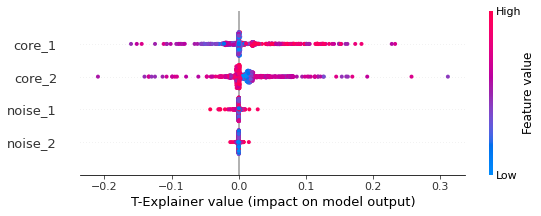


--- 114.54 seconds ---


In [259]:
# T-Exp beeswarm plot -- xgb_model -- 4-FT dataset -- optimize_h

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


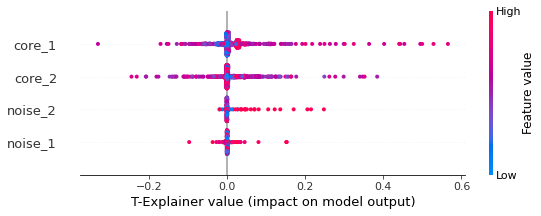


--- 145.38 seconds ---


In [127]:
# T-Exp beeswarm plot -- xgb_model -- 4-FT dataset -- optimize_h_v2

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


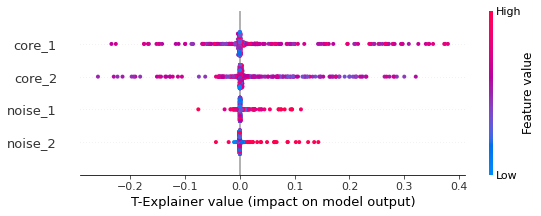


--- 106.71 seconds ---


In [400]:
# T-Exp beeswarm plot -- xgb_model -- 4-FT dataset -- optimize_h_v3

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


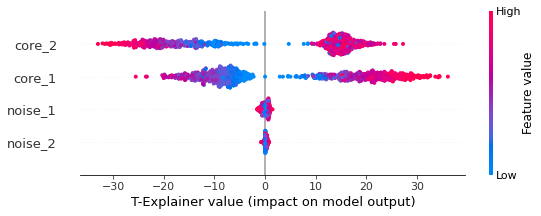


--- 307.14 seconds ---


In [260]:
# T-Exp beeswarm plot -- nn3_model -- 4-FT dataset -- optimize_h

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(nn3_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


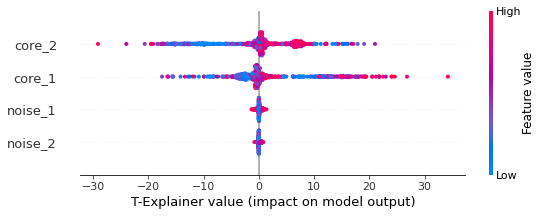


--- 369.71 seconds ---


In [128]:
# T-Exp beeswarm plot -- nn3_model -- 4-FT dataset -- optimize_h_v2

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(nn3_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


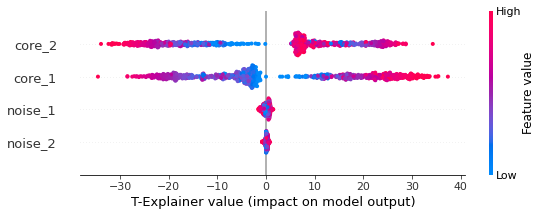


--- 24.56 seconds ---


In [401]:
# T-Exp beeswarm plot -- nn3_model -- 4-FT dataset -- optimize_h_v3

h_min_dist= get_minimum_distance(train)

taylor_plots_sh_beeswarm(nn3_model, train, labels_train, h_min=h_min_dist, h_max=1, eps=1e-3, max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


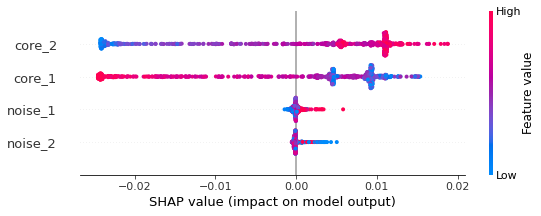

In [261]:
# Tests using TreeSHAP -- xgb_model -- 4-FT dataset

explainer= shap.TreeExplainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


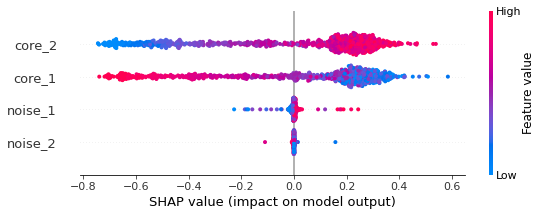

In [262]:
# Tests using TreeSHAP -- nn3_model -- 4-FT dataset

explainer= shap.Explainer(nn3_model.predict, train)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

# OpenXAI synthetic dataset

In [151]:
#### XGBoost -- fin_dif= 2, optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_ox['e_x']= True
descriptor_ox['angle']= False

In [228]:
descriptor_ox['finite_diff_version']= 2

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 727.5729178101639,
 'std(t_exp_ris_max)': 128.6512248246696,
 'shap_ris_max': 896.5999700471461,
 'std(shap_ris_max)': 138.24546271206367,
 'lime_ris_max': 1117.3451191187373,
 'std(lime_ris_max)': 195.4397915614409,
 't_exp_ris_mean': 28.946216826098585,
 'std(t_exp_ris_mean)': 43.859004833185075,
 'shap_ris_mean': 37.82947260728626,
 'std(shap_ris_mean)': 46.418569700582275,
 'lime_ris_mean': 143.57108472444895,
 'std(lime_ris_mean)': 92.22765730036792,
 't_exp_ros_max': 2632531.1486026426,
 'std(t_exp_ros_max)': 479503.23674230586,
 'shap_ros_max': 3328683.8,
 'std(shap_ros_max)': 623838.8783173072,
 'lime_ros_max': 21662513.57605199,
 'std(lime_ros_max)': 3567819.39241918,
 't_exp_ros_mean': 35596.48778453175,
 'std(t_exp_ros_mean)': 63991.96469556048,
 'shap_ros_mean': 64204.28239839554,
 'std(shap_ros_mean)': 96841.54598782561,
 'lime_ros_mean': 348299.42196178035,
 'std(lime_ros_mean)': 545701.6070308896}

In [172]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.3922090061079956e-17, 2.738071925377044e-20, 0.0001719015471187768)


In [546]:
descriptor_ox['eps_eval_add']= 1e-2

# evaluate the mean faithfulness of an additive explanator -- TreeSHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.005330521878702873, 0.8625, 0.010344496, 0.62)


In [549]:
descriptor_ox['eps_eval_add']= 1e-2

# evaluate the mean faithfulness of an additive explanator -- TreeSHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox))

FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.005330521878702873, 0.8625, 0.46008197493682473, 0.31999999999999995)


In [152]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [221]:
descriptor_ox['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 717.2910109317515,
 'std(t_exp_ris_max)': 96.91263030443272,
 'shap_ris_max': 279145.52575505595,
 'std(shap_ris_max)': 55819.46550996679,
 'lime_ris_max': 10182.214214270458,
 'std(lime_ris_max)': 1017.3857375743437,
 't_exp_ris_mean': 26.191386815846876,
 'std(t_exp_ris_mean)': 42.16179228246198,
 'shap_ris_mean': 7272.94789944408,
 'std(shap_ris_mean)': 22528.511316441498,
 'lime_ris_mean': 125.57859141542802,
 'std(lime_ris_mean)': 486.79750382031807,
 't_exp_ros_max': 17887.088480044218,
 'std(t_exp_ros_max)': 2184.6678657259476,
 'shap_ros_max': 1896989.8893325569,
 'std(shap_ros_max)': 272852.91667324223,
 'lime_ros_max': 28063.268778159807,
 'std(lime_ros_max)': 4042.2392263474685,
 't_exp_ros_mean': 99.98528611748654,
 'std(t_exp_ros_mean)': 280.3266135377174,
 'shap_ros_mean': 14075.719023275406,
 'std(shap_ros_mean)': 48758.94117524261,
 'lime_ros_mean': 301.8768234863801,
 'std(lime_ros_mean)': 573.3316812417995,
 'itGd_ris_max': 2279.1794442195387,
 'std(

In [174]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.854818943094591e-15, 0.19185068123123494, 0.02754822103392099, 8.151071147370332e-15, 4.9701125e-06, 4.70294e-06, 5.349247e-06)


In [481]:
descriptor_ox['eps_eval_add']= 1e-2

# evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (2.5809930629263196, 0.0050000000000000044, 2.9079461951055805, 0.0)


# new tests -- comparing approximation methods

In [217]:
# 3H-NN -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# 20-FT Dataset

In [218]:
descriptor_ox['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 854.0854085937489,
 'std(t_exp_ris_max)': 99.8453921664866,
 'shap_ris_max': 148342.83051506992,
 'std(shap_ris_max)': 30507.13380746597,
 'lime_ris_max': 3590.6754801587185,
 'std(lime_ris_max)': 471.9794867039606,
 't_exp_ris_mean': 27.29130052067827,
 'std(t_exp_ris_mean)': 59.362676691228536,
 'shap_ris_mean': 4551.6714793044175,
 'std(shap_ris_mean)': 12627.737709938137,
 'lime_ris_mean': 82.58377064495619,
 'std(lime_ris_mean)': 152.81073111625963,
 't_exp_ros_max': 8501.509829880148,
 'std(t_exp_ros_max)': 1281.4834976232842,
 'shap_ros_max': 7485461.881986587,
 'std(shap_ros_max)': 751685.2292590564,
 'lime_ros_max': 9119.029244582078,
 'std(lime_ros_max)': 1865.9047059530674,
 't_exp_ros_mean': 70.65833827389037,
 'std(t_exp_ros_mean)': 144.94094514661165,
 'shap_ros_mean': 16642.48935968212,
 'std(shap_ros_mean)': 89956.61756725803,
 'lime_ros_mean': 205.6203342722455,
 'std(lime_ros_mean)': 393.2356470772992,
 'itGd_ris_max': 2075.3977029100092,
 'std(itGd_

In [219]:
descriptor_ox['finite_diff_version']= 3

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.5725193763297625e-15, 0.1791694588929709, 0.029303000245059167, 8.06047733215298e-15, 4.9701125e-06, 4.649473e-06, 5.349247e-06)


In [220]:
descriptor_ox['finite_diff_version']= 3
descriptor_ox['eps_eval_add']= 1e-2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (2.581266598840116, 0.0024999999999999467, 2.9836902692187564, 0.0)


In [221]:
# changing the approximation method

descriptor_ox['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 717.2910109317515,
 'std(t_exp_ris_max)': 96.91263030443272,
 'shap_ris_max': 279145.52575505595,
 'std(shap_ris_max)': 55819.46550996679,
 'lime_ris_max': 10182.214214270458,
 'std(lime_ris_max)': 1017.3857375743437,
 't_exp_ris_mean': 26.191386815846876,
 'std(t_exp_ris_mean)': 42.16179228246198,
 'shap_ris_mean': 7272.94789944408,
 'std(shap_ris_mean)': 22528.511316441498,
 'lime_ris_mean': 125.57859141542802,
 'std(lime_ris_mean)': 486.79750382031807,
 't_exp_ros_max': 17887.088480044218,
 'std(t_exp_ros_max)': 2184.6678657259476,
 'shap_ros_max': 1896989.8893325569,
 'std(shap_ros_max)': 272852.91667324223,
 'lime_ros_max': 28063.268778159807,
 'std(lime_ros_max)': 4042.2392263474685,
 't_exp_ros_mean': 99.98528611748654,
 'std(t_exp_ros_mean)': 280.3266135377174,
 'shap_ros_mean': 14075.719023275406,
 'std(shap_ros_mean)': 48758.94117524261,
 'lime_ros_mean': 301.8768234863801,
 'std(lime_ros_mean)': 573.3316812417995,
 'itGd_ris_max': 2279.1794442195387,
 'std(

In [222]:
descriptor_ox['finite_diff_version']= 2

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_ox, train_ox, labels_train_ox, descriptor_ox, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.469261528990308e-15, 0.1608863884857883, 0.02810273634294756, 8.06047733215298e-15, 4.9701125e-06, 4.649473e-06, 5.349247e-06)


In [223]:
descriptor_ox['finite_diff_version']= 2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (2.5834345027567336, 0.0024999999999999467, 2.9836902692187564, 0.0)


In [224]:
# XRFC -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# 20-FT Dataset

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [225]:
descriptor_ox['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 1951.2593189488978,
 'std(t_exp_ris_max)': 282.2611459881531,
 'shap_ris_max': 930.4330190290768,
 'std(shap_ris_max)': 148.822863583425,
 'lime_ris_max': 1066.1990981506701,
 'std(lime_ris_max)': 222.09942512810542,
 't_exp_ris_mean': 49.16342709502042,
 'std(t_exp_ris_mean)': 83.83622068761527,
 'shap_ris_mean': 35.97090224420563,
 'std(shap_ris_mean)': 46.4928545198,
 'lime_ris_mean': 147.39926660555483,
 'std(lime_ris_mean)': 115.86753141695385,
 't_exp_ros_max': 23460951.99075947,
 'std(t_exp_ros_max)': 2538938.3065607254,
 'shap_ros_max': 7281559.0,
 'std(shap_ros_max)': 827902.4644516273,
 'lime_ros_max': 36454608.18646173,
 'std(lime_ros_max)': 4629842.561193171,
 't_exp_ros_mean': 74707.72756506165,
 'std(t_exp_ros_mean)': 258824.87604601943,
 'shap_ros_mean': 55857.958599739075,
 'std(shap_ros_mean)': 101257.81921801035,
 'lime_ros_mean': 357486.73042851244,
 'std(lime_ros_mean)': 605810.1703501483}

In [226]:
descriptor_ox['finite_diff_version']= 3

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.3921798683273057e-17, 5.631772e-09, 0.00017414840151518796)


In [227]:
descriptor_ox['finite_diff_version']= 3

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.005330521889447337, 0.8625, 0.010344496, 0.62)


In [228]:
# changing the approximation method

descriptor_ox['finite_diff_version']= 2

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor_ox)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 727.5729178101639,
 'std(t_exp_ris_max)': 128.6512248246696,
 'shap_ris_max': 896.5999700471461,
 'std(shap_ris_max)': 138.24546271206367,
 'lime_ris_max': 1117.3451191187373,
 'std(lime_ris_max)': 195.4397915614409,
 't_exp_ris_mean': 28.946216826098585,
 'std(t_exp_ris_mean)': 43.859004833185075,
 'shap_ris_mean': 37.82947260728626,
 'std(shap_ris_mean)': 46.418569700582275,
 'lime_ris_mean': 143.57108472444895,
 'std(lime_ris_mean)': 92.22765730036792,
 't_exp_ros_max': 2632531.1486026426,
 'std(t_exp_ros_max)': 479503.23674230586,
 'shap_ros_max': 3328683.8,
 'std(shap_ros_max)': 623838.8783173072,
 'lime_ros_max': 21662513.57605199,
 'std(lime_ros_max)': 3567819.39241918,
 't_exp_ros_mean': 35596.48778453175,
 'std(t_exp_ros_mean)': 63991.96469556048,
 'shap_ros_mean': 64204.28239839554,
 'std(shap_ros_mean)': 96841.54598782561,
 'lime_ros_mean': 348299.42196178035,
 'std(lime_ros_mean)': 545701.6070308896}

In [229]:
descriptor_ox['finite_diff_version']= 2

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (1.3922090061079956e-17, 5.631772e-09, 0.000183619812934515)


In [230]:
descriptor_ox['finite_diff_version']= 2

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_ox, 
                                                                                         train_ox, 
                                                                                         labels_train_ox, 
                                                                                         descriptor_ox))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.005330521878702873, 0.8625, 0.010344496, 0.62)


# end new tests

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


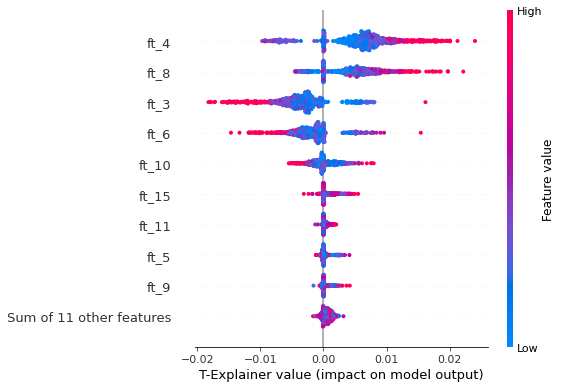


--- 288.27 seconds ---


In [263]:
# T-Exp beeswarm plot -- xgb_model -- 20-FT dataset -- optimize_h

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(xgb_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


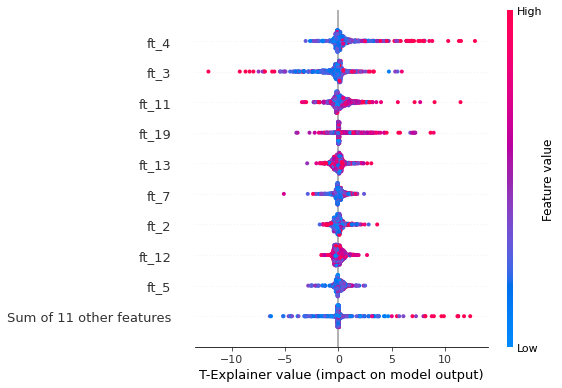


--- 2343.86 seconds ---


In [129]:
# T-Exp beeswarm plot -- nn3_model -- 20-FT dataset -- optimize_h_v2

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(nn3_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


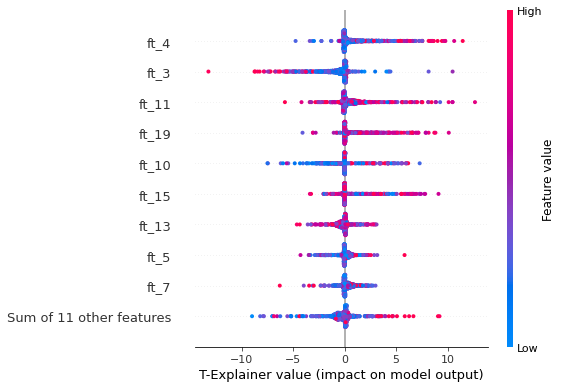


--- 135.84 seconds ---


In [405]:
# T-Exp beeswarm plot -- nn3_model -- 20-FT dataset -- optimize_h_v3

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(nn3_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


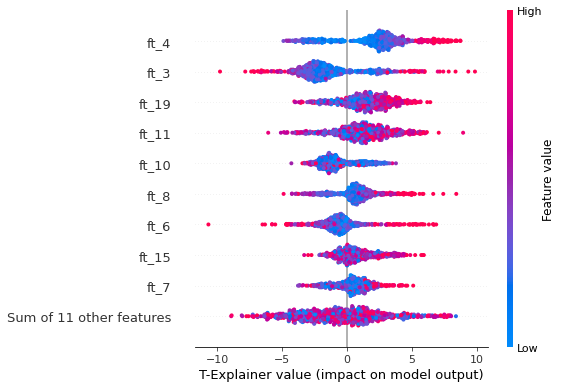


--- 1999.69 seconds ---


In [264]:
# T-Exp beeswarm plot -- nn3_model -- 20-FT dataset -- optimize_h

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(nn3_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


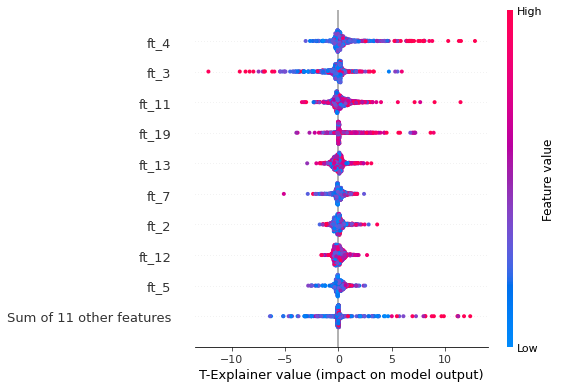


--- 2342.95 seconds ---


In [130]:
# T-Exp beeswarm plot -- nn3_model -- 20-FT dataset -- optimize_h_v2

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(nn3_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


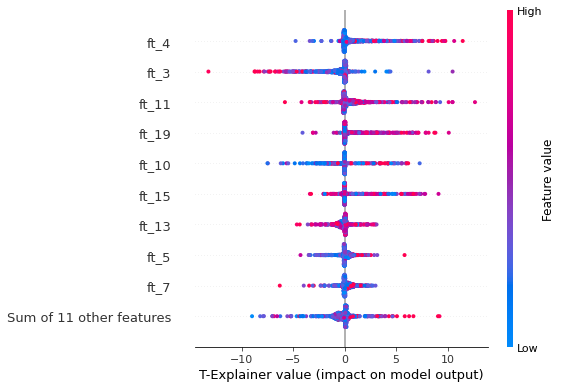


--- 126.74 seconds ---


In [406]:
# T-Exp beeswarm plot -- nn3_model -- 20-FT dataset -- optimize_h_v3

h_min_dist= get_minimum_distance(train_ox)

taylor_plots_sh_beeswarm(nn3_model_ox, train_ox, labels_train_ox, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


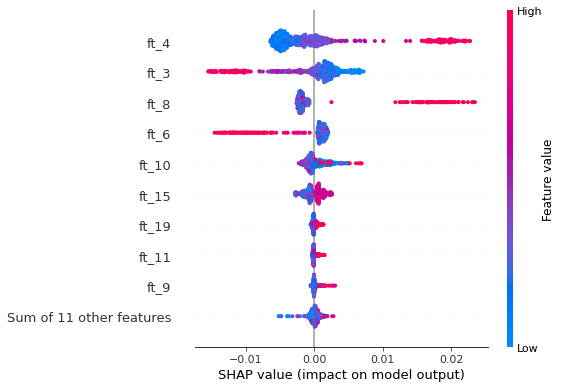

In [265]:
# Tests using TreeSHAP -- xgb_model -- 20-FT dataset

explainer= shap.TreeExplainer(xgb_model_ox)
shap_values= explainer(train_ox)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

Permutation explainer: 801it [02:53,  4.36it/s]                         
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


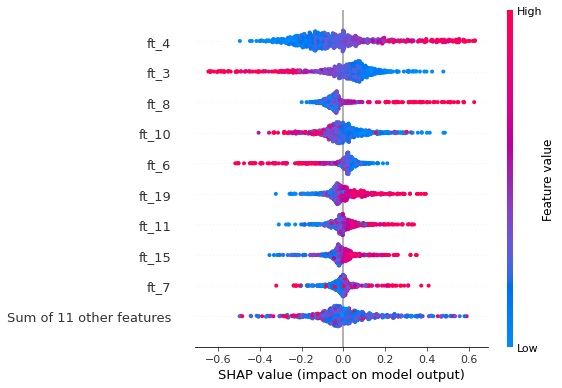

In [266]:
# Tests using TreeSHAP -- nn3_model -- 20-FT dataset

explainer= shap.Explainer(nn3_model_ox.predict, train_ox)
shap_values= explainer(train_ox)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

# Real datasets 

# Breast cancer Wisconsin dataset

In [231]:
from sklearn.datasets import load_breast_cancer

data_cancer= load_breast_cancer(as_frame= True)

data_cancer.data.head()

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [298]:
data_cancer.target.head()

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [232]:
# Normalization

# All dataset is numeric
scaler= MinMaxScaler(feature_range=(0, 1))
norm_x_cancer= scaler.fit_transform(np.asarray(data_cancer.data))
norm_x_cancer= pd.DataFrame(norm_x_cancer, columns=data_cancer.data.columns)

norm_x_cancer.head()

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [233]:
labels_cancer= pd.DataFrame(data_cancer.target)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [234]:
# Check for null values

null_values= norm_x_cancer.isnull().values.any()

if (null_values == True):
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [235]:
train_bc, test_bc, labels_train_bc, labels_test_bc= sklearn.model_selection.train_test_split(norm_x_cancer,
                                                                                             labels_cancer,
                                                                                             train_size=0.80,
                                                                                             random_state=1234)

In [236]:
train_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
518,0.279190,0.287792,0.280976,0.148293,0.624447,0.450034,0.113051,0.263569,0.327778,0.475358,...,0.253291,0.329158,0.243538,0.120306,0.491514,0.260801,0.099521,0.376632,0.200473,0.222288
551,0.196365,0.430504,0.191417,0.099639,0.388463,0.191890,0.113027,0.112177,0.489899,0.327717,...,0.145500,0.432836,0.136411,0.061787,0.247837,0.146414,0.124920,0.220378,0.316184,0.165814
111,0.267358,0.373690,0.265082,0.142906,0.421594,0.311392,0.249531,0.299254,0.340909,0.436816,...,0.192102,0.358475,0.192191,0.084103,0.379912,0.191819,0.176997,0.379725,0.130298,0.195592
64,0.269724,0.477849,0.268813,0.150795,0.537781,0.327649,0.264292,0.341600,0.426768,0.335720,...,0.325863,0.571695,0.305742,0.172803,0.752361,0.367523,0.321406,0.589691,0.358368,0.315230
443,0.169861,0.291173,0.159146,0.083733,0.259908,0.077419,0.046696,0.055219,0.662626,0.162595,...,0.107079,0.300906,0.094327,0.044509,0.176781,0.036994,0.031837,0.076357,0.223536,0.080808


In [237]:
# Set and train a RF ML model

xgb_model_bc= xgb.XGBRFClassifier(learning_rate= 0.01,
                                  n_estimators= 500,
                                  max_depth= 6,
                                  gamma= 0.1,
                                  subsample= 0.9,
                                  objective= 'binary:logistic',
                                  eval_metric='logloss')

eval_set_bc= [(train_bc, labels_train_bc), (test_bc, labels_test_bc)]

xgb_model_bc.fit(train_bc, labels_train_bc, eval_set=eval_set_bc, verbose=False)

acc_all_bc= sklearn.metrics.accuracy_score(labels_test_bc, xgb_model_bc.predict(test_bc))
acc_all_bc

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


0.9122807017543859

In [238]:
# Create the 3-hyden layers Neural Net classifier model

nn3_model_bc= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                            learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model_bc.fit(train_bc, labels_train_bc.values.ravel())

acc_nn3_bc= sklearn.metrics.accuracy_score(labels_test_bc.values.ravel(), nn3_model_bc.predict(test_bc))
acc_nn3_bc

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


0.9649122807017544

In [239]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train_bc= torch.from_numpy(train_bc.values)
tensor_labels_bc= torch.from_numpy(labels_train_bc.values.ravel().astype(int))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [240]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.02
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

descriptor_bc= dict()

n_bc, m_bc= get_n_m_sizes(train_bc, labels_train_bc)
h_min_dist_bc= get_minimum_distance(train_bc)

# T-Exp explanation settings
descriptor_bc['h_min']= h_min_dist_bc
descriptor_bc['h_max']= 1
descriptor_bc['jacobian_eps']= 1e-3
descriptor_bc['max_itr']= 30
descriptor_bc['finite_diff_version']= 2

# perturbation settings used for the stability metrics
descriptor_bc['num_samples']= 50
descriptor_bc['num_perts']= 10
descriptor_bc['pert_max_distance']= (h_min_dist_bc/2)
descriptor_bc['num_runs']= 25
descriptor_bc['feature_metadata']= ['c'] * n_bc
descriptor_bc['p_norm']= 2
descriptor_bc['eps_norm']= 1e-6
descriptor_bc['eps_eval_add']= 1e-2
descriptor_bc['top_k']= 0
descriptor_bc['mask']= generate_mask(tensor_train_bc[0].reshape(-1), descriptor_bc['top_k'])

In [241]:
# XGBoost -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_bc['e_x']= True
descriptor_bc['angle']= False

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [322]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 330.20146072105183,
 'std(t_exp_ris_max)': 51.484341658758545,
 'shap_ris_max': 1589.2531357970756,
 'std(shap_ris_max)': 177.88245028953182,
 'lime_ris_max': 159.64013954946248,
 'std(lime_ris_max)': 32.04027069007603,
 't_exp_ris_mean': 7.2121647062013245,
 'std(t_exp_ris_mean)': 11.295622099781523,
 'shap_ris_mean': 28.83120224041628,
 'std(shap_ris_mean)': 70.357408785479,
 'lime_ris_mean': 25.226506740730347,
 'std(lime_ris_mean)': 17.4842311351761,
 't_exp_ros_max': 2136455.9324073535,
 'std(t_exp_ros_max)': 370020.8029469354,
 'shap_ros_max': 131007496.0,
 'std(shap_ros_max)': 13030653.901741274,
 'lime_ros_max': 10764474.165493006,
 'std(lime_ros_max)': 1830321.0534477297,
 't_exp_ros_mean': 27132.00498678374,
 'std(t_exp_ros_mean)': 43443.684886677336,
 'shap_ros_mean': 223823.25036853028,
 'std(shap_ros_mean)': 1398466.484547177,
 'lime_ros_mean': 179116.0437395428,
 'std(lime_ros_mean)': 296679.4681449783}

In [323]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model_bc, train_bc, labels_train_bc, 
                                                              test_bc, labels_test_bc,
                                                              perturbation, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.00555379, 0.00600412, 0.00540487, 0.00547017, 0.00557159,
       0.00538291, 0.00565543, 0.00613149, 0.00542439, 0.00540585,
       0.00539005, 0.00539691, 0.0053792 , 0.00551724, 0.00538383,
       0.00548247, 0.00537344, 0.00538361, 0.00544776, 0.00538291,
       0.00570733, 0.00611723, 0.00627245, 0.00563476, 0.0056442 ,
       0.00540421, 0.0055207 , 0.00636235, 0.00539679, 0.00541943]), array([0.00554842, 0.00579424, 0.0054169 , 0.00604964, 0.00552005,
       0.00538891, 0.00567257, 0.00728106, 0.00539559, 0.00540769,
       0.00547568, 0.00539529, 0.00545445, 0.00634823, 0.0053979 ,
       0.00545444, 0.00541787, 0.00538905, 0.00545205, 0.00541235,
       0.00651481, 0.00612586, 0.00732686, 0.00781506, 0.00580412,
       0.00544495, 0.00572111, 0.00688181, 0.00538993, 0.00543793]), array([0.00539104, 0.00539502, 0.0053902 , 0.00539252, 0.0053923 ,
       0.00539555, 0.00538829, 0.00539099, 0.00539355, 0.00539002,
       0.00539672, 0.005391

In [324]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bc, train_bc, labels_train_bc, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.955780079885652e-18, 3.9645296e-09, 0.00015300550095786534)


In [325]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.3984352, 1.0, 0.65739363, 0.34)


In [338]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [224]:
# optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_bc['e_x']= True
descriptor_bc['angle']= False

In [225]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 4633.989694613127,
 'std(t_exp_ris_max)': 460.72568847167867,
 'shap_ris_max': 54960.988187921,
 'std(shap_ris_max)': 8295.499740370651,
 'lime_ris_max': 2354.9214069285886,
 'std(lime_ris_max)': 294.5518489476874,
 't_exp_ris_mean': 14.569195050836163,
 'std(t_exp_ris_mean)': 125.94161547160213,
 'shap_ris_mean': 1097.3877200496447,
 'std(shap_ris_mean)': 3154.995981872876,
 'lime_ris_mean': 24.127042329750847,
 'std(lime_ris_mean)': 100.51888286893896,
 't_exp_ros_max': 59204.80499296432,
 'std(t_exp_ros_max)': 7327.220814896171,
 'shap_ros_max': 126967976.13720006,
 'std(shap_ros_max)': 12680472.350282155,
 'lime_ros_max': 146411.82661379865,
 'std(lime_ros_max)': 20755.84701282404,
 't_exp_ros_mean': 444.63082960868434,
 'std(t_exp_ros_mean)': 2524.588576567068,
 'shap_ros_mean': 201234.45281953522,
 'std(shap_ros_mean)': 1635235.0375089454,
 'lime_ros_mean': 1180.4384116782144,
 'std(lime_ros_mean)': 4333.48454012434,
 'itGd_ris_max': 29.870415479241853,
 'std(it

In [206]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model_bc, train_bc, labels_train_bc, 
                                                              test_bc, labels_test_bc,
                                                              perturbation, descriptor_bc, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.41653097, 0.52691444, 0.41092297, 0.48917603, 0.42572603,
       0.45934254, 0.48461736, 0.49206217, 0.42522974, 0.45661368,
       0.48209159, 0.43565037, 0.49024076, 0.47387373, 0.43820689,
       0.48170988, 0.4511053 , 0.42460915, 0.42924551, 0.46211839,
       0.54725528, 0.55722339, 0.51585904, 0.4808788 , 0.640199  ,
       0.44373904, 0.53649805, 0.53976023, 0.49347146, 0.43359913]), array([0.40159604, 0.41017658, 0.39895587, 0.41013886, 0.40140745,
       0.40802673, 0.41787077, 0.41104406, 0.40244466, 0.41802164,
       0.43374948, 0.40480195, 0.40974283, 0.40906393, 0.41811593,
       0.41121378, 0.40231265, 0.40704609, 0.40580144, 0.41285446,
       0.41598494, 0.41181725, 0.42122755, 0.41768219, 0.42034121,
       0.40178462, 0.41183611, 0.41854967, 0.41013886, 0.40095485]), array([0.40008556, 0.39946211, 0.40091318, 0.3994996 , 0.40050992,
       0.39969112, 0.39951987, 0.40056608, 0.39992181, 0.4001748 ,
       0.40011712, 0.399152

In [207]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bc, train_bc, labels_train_bc, descriptor_bc, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (6.7716784016025e-15, 0.179016521583903, 0.025990657786653982, 4.498373121439329e-15, 3.5757548e-06, 3.3660322e-06, 2.9555172e-06)


In [208]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (4.862503773073211, 0.98, 0.9107550163685083, 1.0)


In [242]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.01
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

In [126]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 253.47772087113353,
 'std(t_exp_ris_max)': 40.42857680167717,
 'shap_ris_max': 2526.0740538495534,
 'std(shap_ris_max)': 276.6425076761998,
 'lime_ris_max': 424.0777204358302,
 'std(lime_ris_max)': 84.33472292491595,
 't_exp_ris_mean': 7.645989819544643,
 'std(t_exp_ris_mean)': 14.911152620640959,
 'shap_ris_mean': 33.72313764689946,
 'std(shap_ris_mean)': 107.63143733536316,
 'lime_ris_mean': 51.273414366284754,
 'std(lime_ris_mean)': 44.74445708727358,
 't_exp_ros_max': 543903.0446588898,
 'std(t_exp_ros_max)': 100110.94615519962,
 'shap_ros_max': 10358502.0,
 'std(shap_ros_max)': 1079334.9,
 'lime_ros_max': 5035702.495490452,
 'std(lime_ros_max)': 953875.7520430323,
 't_exp_ros_mean': 13594.453153008302,
 'std(t_exp_ros_mean)': 25680.13531297382,
 'shap_ros_mean': 60349.926,
 'std(shap_ros_mean)': 137050.38,
 'lime_ros_mean': 158148.28239929085,
 'std(lime_ros_mean)': 224975.49884212797}

In [127]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(xgb_model_bc, train_bc, labels_train_bc, 
                                                              test_bc, labels_test_bc,
                                                              perturbation, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.00407813, 0.00458337, 0.0039826 , 0.00405639, 0.00409856,
       0.00396408, 0.00409331, 0.00454776, 0.00399858, 0.00398495,
       0.00396436, 0.00397826, 0.00396222, 0.00402488, 0.00396703,
       0.00401042, 0.00395544, 0.00396389, 0.0039891 , 0.00395771,
       0.00412566, 0.00466806, 0.00436449, 0.00418582, 0.00428994,
       0.00398385, 0.0040293 , 0.00476105, 0.00396657, 0.00401592]), array([0.00409968, 0.00438735, 0.00399205, 0.00495501, 0.00405913,
       0.00397409, 0.0040845 , 0.00529159, 0.00397449, 0.00397162,
       0.0040215 , 0.0039726 , 0.00401237, 0.00445506, 0.00397148,
       0.00400049, 0.00399696, 0.00397206, 0.00401961, 0.00399214,
       0.00488079, 0.00442752, 0.00485551, 0.00637964, 0.00450161,
       0.00402202, 0.00414937, 0.00518915, 0.00396455, 0.00403329]), array([0.00397867, 0.00398174, 0.00398318, 0.0039767 , 0.00397579,
       0.0039783 , 0.00397568, 0.00397269, 0.00397723, 0.00398624,
       0.00397541, 0.003973

In [128]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bc, train_bc, labels_train_bc, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.955780079885652e-18, 3.9645296e-09, 0.00016858007409084995)


In [129]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.3984352, 1.0, 0.65739363, 0.34)


In [ ]:
xgb_model_bc.predict()

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


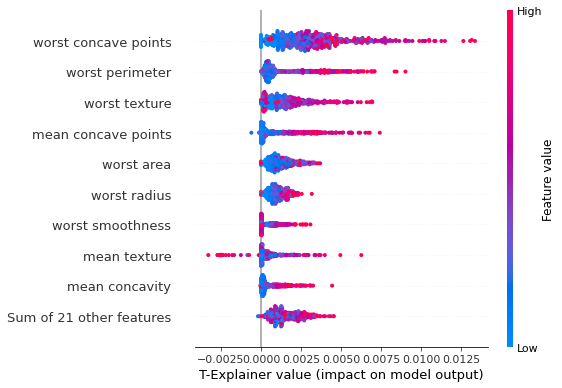


--- 353.66 seconds ---


In [314]:
# T-Exp beeswarm plot -- xgb_model -- BCancer dataset -- optimize_h

h_min_dist= get_minimum_distance(norm_x_cancer)

taylor_plots_sh_beeswarm(xgb_model_bc, norm_x_cancer, labels_cancer, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


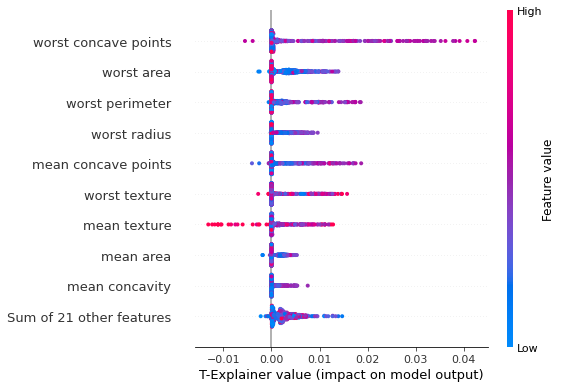


--- 213.37 seconds ---


In [407]:
# T-Exp beeswarm plot -- xgb_model -- BCancer dataset -- optimize_h_v3

h_min_dist= get_minimum_distance(norm_x_cancer)

taylor_plots_sh_beeswarm(xgb_model_bc, norm_x_cancer, labels_cancer, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


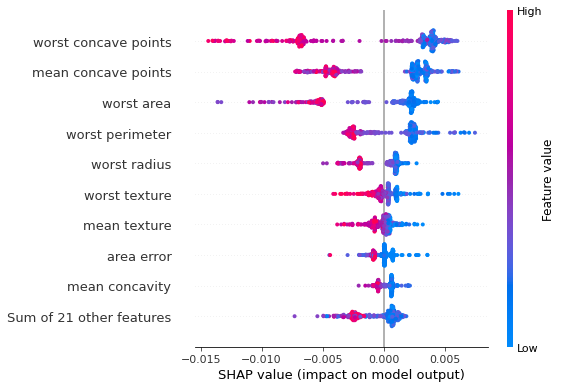

In [268]:
# Tests using TreeSHAP -- xgb_model -- BCancer dataset

explainer= shap.TreeExplainer(xgb_model_bc)
shap_values= explainer(train_bc)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

Permutation explainer: 456it [01:34,  4.13it/s]                         
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


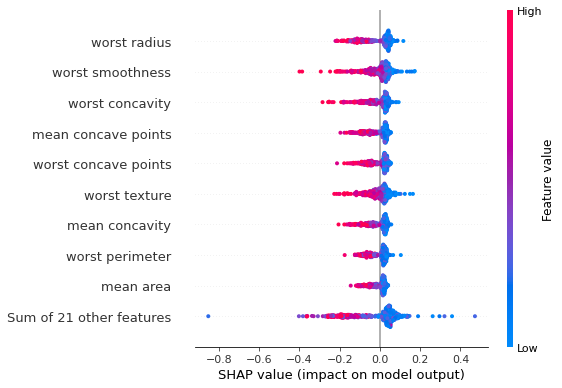

In [302]:
# Tests using TreeSHAP -- xgb_model -- BCancer dataset

explainer= shap.Explainer(nn3_model_bc.predict, train_bc)
shap_values= explainer(train_bc)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

In [336]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [247]:
descriptor_bc['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 3739.4249627342947,
 'std(t_exp_ris_max)': 371.73473979897824,
 'shap_ris_max': 50375.874859566655,
 'std(shap_ris_max)': 9066.683024054902,
 'lime_ris_max': 836.2139162314398,
 'std(lime_ris_max)': 118.3002687405224,
 't_exp_ris_mean': 18.09585610277694,
 'std(t_exp_ris_mean)': 161.3076028664519,
 'shap_ris_mean': 1438.121562002123,
 'std(shap_ris_mean)': 4724.113874017268,
 'lime_ris_mean': 24.93484792547482,
 'std(lime_ris_mean)': 45.16019906939629,
 't_exp_ros_max': 90067.32218610683,
 'std(t_exp_ros_max)': 11865.979244230026,
 'shap_ros_max': 33995577.40505182,
 'std(shap_ros_max)': 3459755.7242481387,
 'lime_ros_max': 661011.7930388456,
 'std(lime_ros_max)': 95127.02703280028,
 't_exp_ros_mean': 722.4133087850221,
 'std(t_exp_ros_mean)': 4765.199820833068,
 'shap_ros_mean': 148471.63395678587,
 'std(shap_ros_mean)': 1053641.9333975052,
 'lime_ros_mean': 3423.1703251670733,
 'std(lime_ros_mean)': 14898.55940423881,
 'itGd_ris_max': 20.658046667904856,
 'std(itGd_

In [211]:
# evaluate prediction gap on important features
print('PGI -- (T-Exp, SHAP, LIME) --', eval_pred_faithfulness(nn3_model_bc, train_bc, labels_train_bc, 
                                                              test_bc, labels_test_bc,
                                                              perturbation, descriptor_bc, is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


PGI -- (T-Exp, SHAP, LIME) -- (array([0.1585874 , 0.23141498, 0.15561563, 0.20781703, 0.17008876,
       0.21391404, 0.23097763, 0.21253464, 0.16554517, 0.20148541,
       0.21178382, 0.1705233 , 0.19169009, 0.18582559, 0.16871797,
       0.20600572, 0.1695935 , 0.16842205, 0.16284175, 0.17626458,
       0.24181934, 0.25828073, 0.2272803 , 0.19874853, 0.30713621,
       0.184346  , 0.25475358, 0.25125177, 0.22563426, 0.15974293]), array([0.14916397, 0.16255338, 0.14893767, 0.17181282, 0.14929598,
       0.1605544 , 0.16768285, 0.1646278 , 0.15276591, 0.1582914 ,
       0.16615532, 0.1533128 , 0.16515583, 0.15525521, 0.15778222,
       0.15842341, 0.15382198, 0.15242646, 0.16266653, 0.167796  ,
       0.17128479, 0.17045502, 0.16208192, 0.16381689, 0.16764513,
       0.15953605, 0.17592393, 0.16655135, 0.15768793, 0.15327508]), array([0.15004161, 0.15034769, 0.15063648, 0.1511668 , 0.15050175,
       0.14996452, 0.15071062, 0.14980864, 0.15042252, 0.15048587,
       0.15007012, 0.150283

In [212]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bc, train_bc, labels_train_bc, descriptor_bc, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (6.7716784016025e-15, 0.1690520149244013, 0.02707709349069937, 4.498373121439329e-15, 3.5757548e-06, 3.3660322e-06, 2.9555172e-06)


In [213]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


AEF -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (4.862503773073211, 0.98, 0.9107550163685083, 1.0)


# new tests -- comparing approximation methods

In [243]:
# 3H-NN -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# Breast Cancer Dataset

In [244]:
descriptor_bc['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 366471.77503270784,
 'std(t_exp_ris_max)': 36461.257921373755,
 'shap_ris_max': 85064.54788136047,
 'std(shap_ris_max)': 14810.686116034343,
 'lime_ris_max': 7093.509558996185,
 'std(lime_ris_max)': 713.851363230905,
 't_exp_ris_mean': 1283.2932086272554,
 'std(t_exp_ris_mean)': 12590.107056289977,
 'shap_ris_mean': 2154.938749589132,
 'std(shap_ris_mean)': 5755.999399393933,
 'lime_ris_mean': 41.419465982519014,
 'std(lime_ris_mean)': 202.8730787424375,
 't_exp_ros_max': 3753831273.493467,
 'std(t_exp_ros_max)': 373501289.7946741,
 'shap_ros_max': 669779580.8056887,
 'std(shap_ros_max)': 84885714.49253921,
 'lime_ros_max': 1763733.0426324387,
 'std(lime_ros_max)': 184804.7926346939,
 't_exp_ros_mean': 9095146.765783314,
 'std(t_exp_ros_mean)': 90491784.92015544,
 'shap_ros_mean': 1638701.6201667455,
 'std(shap_ros_mean)': 10398673.687809752,
 'lime_ros_mean': 4603.849535577869,
 'std(lime_ros_mean)': 27508.317839657742,
 'itGd_ris_max': 24.98376959473698,
 'std(itGd_

In [245]:
descriptor_bc['finite_diff_version']= 3

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bc, train_bc, labels_train_bc, descriptor_bc, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (7.604014723466001e-15, 0.19627275345803857, 0.02734890569536092, 4.498373121439329e-15, 3.5757548e-06, 3.3660322e-06, 2.9555172e-06)


In [246]:
descriptor_bc['finite_diff_version']= 3
descriptor_bc['eps_eval_add']= 1e-2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc, 
                                                                                         is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (10.595817262324358, 0.0, 9.370634522484929, 0.0)


In [247]:
# changing the approximation method

descriptor_bc['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 3739.4249627342947,
 'std(t_exp_ris_max)': 371.73473979897824,
 'shap_ris_max': 50375.874859566655,
 'std(shap_ris_max)': 9066.683024054902,
 'lime_ris_max': 836.2139162314398,
 'std(lime_ris_max)': 118.3002687405224,
 't_exp_ris_mean': 18.09585610277694,
 'std(t_exp_ris_mean)': 161.3076028664519,
 'shap_ris_mean': 1438.121562002123,
 'std(shap_ris_mean)': 4724.113874017268,
 'lime_ris_mean': 24.93484792547482,
 'std(lime_ris_mean)': 45.16019906939629,
 't_exp_ros_max': 90067.32218610683,
 'std(t_exp_ros_max)': 11865.979244230026,
 'shap_ros_max': 33995577.40505182,
 'std(shap_ros_max)': 3459755.7242481387,
 'lime_ros_max': 661011.7930388456,
 'std(lime_ros_max)': 95127.02703280028,
 't_exp_ros_mean': 722.4133087850221,
 'std(t_exp_ros_mean)': 4765.199820833068,
 'shap_ros_mean': 148471.63395678587,
 'std(shap_ros_mean)': 1053641.9333975052,
 'lime_ros_mean': 3423.1703251670733,
 'std(lime_ros_mean)': 14898.55940423881,
 'itGd_ris_max': 20.658046667904856,
 'std(itGd_

In [248]:
descriptor_bc['finite_diff_version']= 2

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bc, train_bc, labels_train_bc, descriptor_bc, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (6.7716784016025e-15, 0.18226673105643826, 0.026180241850775988, 4.498373121439329e-15, 3.5757548e-06, 3.3660322e-06, 2.9555172e-06)


In [ ]:
descriptor_bc['finite_diff_version']= 2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc, 
                                                                                         is_model_NN=True))

In [ ]:
# XRFC -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# Breast Cancer Dataset

In [251]:
descriptor_bc['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 952.6820984479526,
 'std(t_exp_ris_max)': 142.65962339573824,
 'shap_ris_max': 2851.1410118283848,
 'std(shap_ris_max)': 297.2316246068183,
 'lime_ris_max': 377.9085602036924,
 'std(lime_ris_max)': 75.21459987244079,
 't_exp_ris_mean': 18.83687027673748,
 'std(t_exp_ris_mean)': 40.161929561681,
 'shap_ris_mean': 30.074602840922047,
 'std(shap_ris_mean)': 82.87442042976956,
 'lime_ris_mean': 50.47189127973402,
 'std(lime_ris_mean)': 39.78152992704897,
 't_exp_ros_max': 14241898.9290845,
 'std(t_exp_ros_max)': 1510990.9697153915,
 'shap_ros_max': 3222051.8,
 'std(shap_ros_max)': 420368.9,
 'lime_ros_max': 11305183.396554261,
 'std(lime_ros_max)': 1539800.6359084048,
 't_exp_ros_mean': 51672.19234704533,
 'std(t_exp_ros_mean)': 196247.17133589034,
 'shap_ros_mean': 46023.164,
 'std(shap_ros_mean)': 83266.59,
 'lime_ros_mean': 154410.29076766994,
 'std(lime_ros_mean)': 266035.1075934605}

In [252]:
descriptor_bc['finite_diff_version']= 3

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bc, train_bc, labels_train_bc, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (7.086665519440217e-18, 3.9645296e-09, 0.0001543582404402905)


In [253]:
descriptor_bc['finite_diff_version']= 3

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.00713782646352739, 0.6725, 0.014003775, 0.6375)


In [254]:
# changing the approximation method

descriptor_bc['finite_diff_version']= 2

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bc, train_bc, labels_train_bc, perturbation, descriptor_bc)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 270.13858434137967,
 'std(t_exp_ris_max)': 37.821742756611464,
 'shap_ris_max': 2073.548713094592,
 'std(shap_ris_max)': 231.46742300112763,
 'lime_ris_max': 472.6984165771961,
 'std(lime_ris_max)': 87.31577327894671,
 't_exp_ris_mean': 7.25090810794465,
 'std(t_exp_ris_mean)': 15.02732609405744,
 'shap_ris_mean': 29.0672967321433,
 'std(shap_ris_mean)': 57.89752902090828,
 'lime_ris_mean': 48.7768437513309,
 'std(lime_ris_mean)': 41.33137803259121,
 't_exp_ros_max': 987796.7834171187,
 'std(t_exp_ros_max)': 153858.65619740714,
 'shap_ros_max': 1687270.6,
 'std(shap_ros_max)': 329136.25,
 'lime_ros_max': 11183964.036363594,
 'std(lime_ros_max)': 1628528.6713474053,
 't_exp_ros_mean': 13445.322912537284,
 'std(t_exp_ros_mean)': 23375.31354361727,
 'shap_ros_mean': 41809.965,
 'std(shap_ros_mean)': 66942.21,
 'lime_ros_mean': 168359.06435449258,
 'std(lime_ros_mean)': 316752.9661273853}

In [255]:
descriptor_bc['finite_diff_version']= 2

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bc, train_bc, labels_train_bc, descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.955780079885652e-18, 3.9645296e-09, 0.00014579231148688373)


In [256]:
descriptor_bc['finite_diff_version']= 2

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bc, 
                                                                                         train_bc, 
                                                                                         labels_train_bc, 
                                                                                         descriptor_bc))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) -- (0.0071378264891744396, 0.6725, 0.014003775, 0.6375)


# end new tests

# Banknote Authentication dataset

In [271]:
colnames=['variance', 'skewness', 'curtosis', 'image_entropy', 'target']
synth_bna= pd.read_csv('datasets/data_banknote_authentication.txt', names=colnames, header=None)

# split synth into features (x) and target (y)
x_syn_bna= synth_bna.loc[:,synth_bna.columns[0:4]]
y_syn_bna= synth_bna.loc[:,synth_bna.columns[4:5]]

x_syn_bna.head()

,variance,skewness,curtosis,image_entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [277]:
norm_x_bna= scaler.fit_transform(np.asarray(x_syn_bna))
norm_x_bna= pd.DataFrame(norm_x_bna, columns=x_syn_bna.columns)

norm_x_bna.head()

,variance,skewness,curtosis,image_entropy
0,0.769004,0.839643,0.106783,0.736628
1,0.835659,0.820982,0.121804,0.644326
2,0.786629,0.416648,0.310608,0.786951
3,0.757105,0.871699,0.054921,0.450440
4,0.531578,0.348662,0.424662,0.687362


In [281]:
labels_bna= pd.DataFrame(y_syn_bna)

labels_bna.head()

,target
0,0
1,0
2,0
3,0
4,0


In [284]:
#Check for null values
null_values = norm_x_bna.isnull().values.any()
if null_values == True:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


In [285]:
train_bna, test_bna, labels_train_bna, labels_test_bna= sklearn.model_selection.train_test_split(norm_x_bna,
                                                                                             labels_bna,
                                                                                             train_size=0.80,
                                                                                             random_state=1234)

In [276]:
# Set and train a RF ML model

xgb_model_bna= xgb.XGBRFClassifier(learning_rate= 0.01,
                                  n_estimators= 500,
                                  max_depth= 6,
                                  gamma= 0.1,
                                  subsample= 0.9,
                                  objective= 'binary:logistic',
                                  eval_metric='logloss')

eval_set_bna= [(train_bna, labels_train_bna), (test_bna, labels_test_bna)]

xgb_model_bna.fit(train_bna, labels_train_bna, eval_set=eval_set_bna, verbose=False)

acc_all_bna= sklearn.metrics.accuracy_score(labels_test_bna, xgb_model_bna.predict(test_bna))
acc_all_bna

1.0

In [286]:
# Create the 3-hyden layers Neural Net classifier model

nn3_model_bna= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                            learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model_bna.fit(train_bna, labels_train_bna.values.ravel())

acc_nn3_bna= sklearn.metrics.accuracy_score(labels_test_bna.values.ravel(), nn3_model_bna.predict(test_bna))
acc_nn3_bna

1.0

In [289]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train_bna= torch.from_numpy(train_bna.values)
tensor_labels_bna= torch.from_numpy(labels_train_bna.values.ravel().astype(int))

In [290]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.01
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

descriptor_bna= dict()

n_bna, m_bna= get_n_m_sizes(train_bna, labels_train_bna)
h_min_dist_bna= get_minimum_distance(train_bna)

# T-Exp explanation settings
descriptor_bna['h_min']= h_min_dist_bna
descriptor_bna['h_max']= 1
descriptor_bna['jacobian_eps']= 1e-3
descriptor_bna['max_itr']= 30
descriptor_bna['finite_diff_version']= 2

# perturbation settings used for the stability metrics
descriptor_bna['num_samples']= 50
descriptor_bna['num_perts']= 10
descriptor_bna['pert_max_distance']= (h_min_dist_bna/2)
descriptor_bna['num_runs']= 25
descriptor_bna['feature_metadata']= ['c'] * n_bna
descriptor_bna['p_norm']= 2
descriptor_bna['eps_norm']= 1e-6
descriptor_bna['eps_eval_add']= 1e-2
descriptor_bna['top_k']= 0
descriptor_bna['mask']= generate_mask(tensor_train_bna[0].reshape(-1), descriptor_bna['top_k'])

In [293]:
# XGBoost -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_bna['e_x']= True
descriptor_bna['angle']= False

In [313]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna)

RIS/ROS -- (T-Exp, SHAP, LIME)


{'t_exp_ris_max': 39043.63914905262,
 'std(t_exp_ris_max)': 4155.140651621059,
 'shap_ris_max': 52098.616907598764,
 'std(shap_ris_max)': 5186.507768728417,
 'lime_ris_max': 3620.9321477534513,
 'std(lime_ris_max)': 488.9185267430551,
 't_exp_ris_mean': 249.91787065433263,
 'std(t_exp_ris_mean)': 769.7167497610241,
 'shap_ris_mean': 158.91314660597735,
 'std(shap_ris_mean)': 1336.3000667309398,
 'lime_ris_mean': 94.4828868952485,
 'std(lime_ris_mean)': 225.36494883665716,
 't_exp_ros_max': 240841745.1512557,
 'std(t_exp_ros_max)': 33164983.35747266,
 'shap_ros_max': 3664381.5,
 'std(shap_ros_max)': 365775.56580669107,
 'lime_ros_max': 27843219.48581889,
 'std(lime_ros_max)': 2911657.4101048266,
 't_exp_ros_mean': 621661.3424977678,
 'std(t_exp_ros_mean)': 3746389.367609058,
 'shap_ros_mean': 17477.81120940116,
 'std(shap_ros_mean)': 121630.02990511773,
 'lime_ros_mean': 107719.20955622316,
 'std(lime_ros_mean)': 493956.60961612826}

In [314]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bna, train_bna, labels_train_bna, descriptor_bna))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.613217783960923e-16, 7.456263e-09, 0.0003148605419887442)


In [308]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [315]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 175.28527887207977,
 'std(t_exp_ris_max)': 18.18918711033964,
 'shap_ris_max': 134241.0798081607,
 'std(shap_ris_max)': 13752.304952995137,
 'lime_ris_max': 97.56875731429103,
 'std(lime_ris_max)': 17.762451691474222,
 't_exp_ris_mean': 3.0931125636073102,
 'std(t_exp_ris_mean)': 3.2759427929700684,
 'shap_ris_mean': 468.77561816005,
 'std(shap_ris_mean)': 3704.386106064268,
 'lime_ris_mean': 9.341462186487083,
 'std(lime_ris_mean)': 4.968493227176058,
 't_exp_ros_max': 429.3067628471119,
 'std(t_exp_ros_max)': 53.32745560462965,
 'shap_ros_max': 190296.01068478278,
 'std(shap_ros_max)': 19054.296428700247,
 'lime_ros_max': 849.0165150995942,
 'std(lime_ros_max)': 141.02647925592996,
 't_exp_ros_mean': 4.052450067483831,
 'std(t_exp_ros_mean)': 15.22520464457862,
 'shap_ros_mean': 543.3640227344173,
 'std(shap_ros_mean)': 4655.423068625401,
 'lime_ros_mean': 13.432471021418092,
 'std(lime_ros_mean)': 27.059783965769356,
 'itGd_ris_max': 12.3723635015334,
 'std(itGd_ri

In [316]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bna, train_bna, labels_train_bna, descriptor_bna, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (2.3898437090739062e-14, 4.443059973708341e-16, 0.03258736626903901, 1.4002901083489727e-14, 1.630337e-05, 1.618439e-05, 1.6193168e-05)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


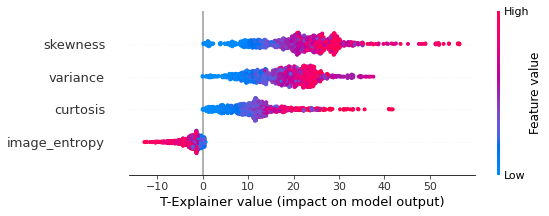


--- 520.19 seconds ---


In [313]:
# T-Exp beeswarm plot -- nn3_model -- BNA dataset

h_min_dist= get_minimum_distance(train_bna)

taylor_plots_sh_beeswarm(nn3_model_bna, train_bna, labels_train_bna, h_min=h_min_dist, h_max=1, eps=1e-3, 
                         max_itr=30, 
                         finite_diff_version=2, e_x=True, angle=False, verbose=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
Exact explainer: 1098it [00:13, 20.89it/s]                          
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


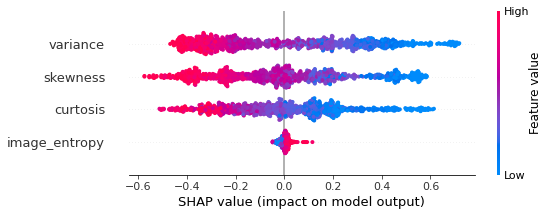

In [295]:
# Tests using TreeSHAP -- nn3_model -- BNA dataset

explainer= shap.Explainer(nn3_model_bna.predict, train_bna)
shap_values= explainer(train_bna)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

# new tests -- comparing approximation methods

In [243]:
# 3H-NN -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# Banknote Dataset

In [ ]:
descriptor_bna['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


In [ ]:
descriptor_bna['finite_diff_version']= 3

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bna, train_bna, labels_train_bna, descriptor_bna, 
                                                     is_model_NN=True))

In [ ]:
descriptor_bna['finite_diff_version']= 3
descriptor_bna['eps_eval_add']= 1e-2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bna, 
                                                                                         train_bna, 
                                                                                         labels_train_bna, 
                                                                                         descriptor_bna, 
                                                                                         is_model_NN=True))

In [ ]:
# changing the approximation method

descriptor_bna['finite_diff_version']= 2

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna, is_model_NN=True)

In [ ]:
descriptor_bna['finite_diff_version']= 2

# RES -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_bna, train_bna, labels_train_bna, descriptor_bna, 
                                                     is_model_NN=True))

In [ ]:
descriptor_bna['finite_diff_version']= 2

# FAE -- evaluate the mean faithfulness of an additive explanator
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(nn3_model_bna, 
                                                                                         train_bna, 
                                                                                         labels_train_bna, 
                                                                                         descriptor_bna, 
                                                                                         is_model_NN=True))

In [ ]:
# XRFC -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp
# Banknote Dataset

In [ ]:
descriptor_bna['finite_diff_version']= 3

# RIS/ROS -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna)

In [ ]:
descriptor_bna['finite_diff_version']= 3

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bna, train_bna, labels_train_bna, descriptor_bna))

In [ ]:
descriptor_bna['finite_diff_version']= 3

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bna, 
                                                                                         train_bna, 
                                                                                         labels_train_bna, 
                                                                                         descriptor_bna))

In [ ]:
# changing the approximation method

descriptor_bna['finite_diff_version']= 2

# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_bna, train_bna, labels_train_bna, perturbation, descriptor_bna)

In [ ]:
descriptor_bna['finite_diff_version']= 2

# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_bna, train_bna, labels_train_bna, descriptor_bna))

In [ ]:
descriptor_bna['finite_diff_version']= 2

# evaluate the mean faithfulness of an additive explanator -- SHAP
print('FAE -- (T-Exp, T-Exp ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model_bna, 
                                                                                         train_bna, 
                                                                                         labels_train_bna, 
                                                                                         descriptor_bna))

# end new tests

# EEG Eye State dataset

In [256]:
synth_eeg= pd.read_csv('datasets/EEG_Eye_State.arff')

# split synth into features (x) and target (y)
x_syn_eeg= synth_eeg.loc[:,synth_eeg.columns[0:14]]
y_syn_eeg= synth_eeg.loc[:,synth_eeg.columns[14:15]]

x_syn_eeg.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [260]:
norm_x_eeg= scaler.fit_transform(np.asarray(x_syn_eeg))
norm_x_eeg= pd.DataFrame(norm_x_eeg, columns=x_syn_eeg.columns)

norm_x_eeg.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,0.010702,0.236931,0.556326,0.002648,0.515557,0.005053,0.003558,0.027383,0.010837,0.498575,0.264230,0.426286,0.029886,0.004237
1,0.010687,0.236004,0.557117,0.002649,0.513684,0.005054,0.003559,0.026619,0.010795,0.496148,0.263219,0.426071,0.029865,0.004224
2,0.010697,0.236416,0.557379,0.002661,0.512514,0.005046,0.003558,0.023390,0.010783,0.495197,0.262931,0.426610,0.029838,0.004231
3,0.010701,0.237446,0.557556,0.002660,0.514035,0.005043,0.003559,0.023579,0.010820,0.497940,0.264086,0.427799,0.029862,0.004241
4,0.010692,0.237446,0.556854,0.002653,0.514971,0.005054,0.003556,0.022437,0.010795,0.499735,0.264664,0.427909,0.029865,0.004244


In [272]:
#Check for null values
null_values = norm_x_eeg.isnull().values.any()
if null_values == True:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


In [273]:
labels_eeg= pd.DataFrame(y_syn_eeg)

labels_eeg.head()

,eyeDetection
0,0
1,0
2,0
3,0
4,0


In [291]:
train_eeg, test_eeg, labels_train_eeg, labels_test_eeg= sklearn.model_selection.train_test_split(norm_x_eeg,
                                                                                             labels_eeg,
                                                                                             train_size=0.80,
                                                                                             random_state=1234)

In [292]:
# Set and train a RF ML model

xgb_model_eeg= xgb.XGBRFClassifier(learning_rate= 0.01,
                                  n_estimators= 500,
                                  max_depth= 6,
                                  gamma= 0.1,
                                  subsample= 0.9,
                                  objective= 'binary:logistic',
                                  eval_metric='logloss')

eval_set_eeg= [(train_eeg, labels_train_eeg), (test_eeg, labels_test_eeg)]

xgb_model_eeg.fit(train_eeg, labels_train_eeg, eval_set=eval_set_eeg, verbose=False)

acc_all_eeg= sklearn.metrics.accuracy_score(labels_test_eeg, xgb_model_eeg.predict(test_eeg))
acc_all_eeg

0.798064085447263

In [296]:
# Create the 3-hyden layers Neural Net classifier model

nn3_model_eeg= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                            learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model_eeg.fit(train_eeg, labels_train_eeg.values.ravel())

acc_nn3_eeg= sklearn.metrics.accuracy_score(labels_test_eeg.values.ravel(), nn3_model_eeg.predict(test_eeg))
acc_nn3_eeg

0.5594125500667557

In [298]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train_eeg= torch.from_numpy(train_eeg.values)
tensor_labels_eeg= torch.from_numpy(labels_train_eeg.values.ravel().astype(int))

In [303]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.01
perturbation_flip_percentage= 0.0001
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

descriptor_eeg= dict()

n_eeg, m_eeg= get_n_m_sizes(train_eeg, labels_train_eeg)
h_min_dist_eeg= get_minimum_distance(train_eeg)

# T-Exp explanation settings
descriptor_eeg['h_min']= h_min_dist_eeg
descriptor_eeg['h_max']= 1
descriptor_eeg['jacobian_eps']= 1e-3
descriptor_eeg['max_itr']= 30
descriptor_eeg['finite_diff_version']= 2

# perturbation settings used for the stability metrics
descriptor_eeg['num_samples']= 50
descriptor_eeg['num_perts']= 10
descriptor_eeg['pert_max_distance']= (h_min_dist_eeg/2)
descriptor_eeg['num_runs']= 25
descriptor_eeg['feature_metadata']= ['c'] * n_eeg
descriptor_eeg['p_norm']= 2
descriptor_eeg['eps_norm']= 1e-6
descriptor_eeg['eps_eval_add']= 1e-2
descriptor_eeg['top_k']= 0
descriptor_eeg['mask']= generate_mask(tensor_train_eeg[0].reshape(-1), descriptor_eeg['top_k'])

In [306]:
# XGBoost -- optimize_h -- dot product e_x=True -- USING derivative_adjustment_ft_imp

descriptor_eeg['e_x']= True
descriptor_eeg['angle']= False

In [317]:
# DONE -- evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(xgb_model_eeg, train_eeg, labels_train_eeg, perturbation, descriptor_eeg)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 285.9381047334234,
 'std(t_exp_ris_max)': 37.337337835134136,
 'shap_ris_max': 2148.2552066143376,
 'std(shap_ris_max)': 219.06145150877646,
 'lime_ris_max': 3.0345865111519688,
 'std(lime_ris_max)': 0.40116947015721405,
 't_exp_ris_mean': 2.7990136867360773,
 'std(t_exp_ris_mean)': 4.371503390016493,
 'shap_ris_mean': 23.077344066857595,
 'std(shap_ris_mean)': 98.21577267219347,
 'lime_ris_mean': 0.9255847681595374,
 'std(lime_ris_mean)': 0.13161106717275936,
 't_exp_ros_max': 3038654.4069516067,
 'std(t_exp_ros_max)': 310371.0758969488,
 'shap_ros_max': 38216212.0,
 'std(shap_ros_max)': 5175587.5,
 'lime_ros_max': 323992.70014814456,
 'std(lime_ros_max)': 50289.43821080591,
 't_exp_ros_mean': 12606.061665012974,
 'std(t_exp_ros_mean)': 32581.947492071482,
 'shap_ros_mean': 175325.73,
 'std(shap_ros_mean)': 904948.06,
 'lime_ros_mean': 5231.578916954651,
 'std(lime_ros_mean)': 6688.509198740653}

In [318]:
# DONE -- evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(xgb_model_eeg, train_eeg, labels_train_eeg, descriptor_eeg))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (5.330258490943897e-15, 3.3897316e-09, 0.00018447590525137264)


In [307]:
#### USING A 3-HYDEN LAYERS NEURAL NETWORK

In [319]:
# evaluate relative input/output stability
print('RIS/ROS -- (T-Exp, SHAP, LIME)')
relative_stability(nn3_model_eeg, train_eeg, labels_train_eeg, perturbation, descriptor_eeg, is_model_NN=True)

RIS/ROS -- (T-Exp, SHAP, LIME)


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


{'t_exp_ris_max': 1.347833101389645,
 'std(t_exp_ris_max)': 0.06513581910798036,
 'shap_ris_max': 0.0,
 'std(shap_ris_max)': 0.0,
 'lime_ris_max': 3.639304995773755,
 'std(lime_ris_max)': 0.4444039805973975,
 't_exp_ris_mean': 1.0093179276962703,
 'std(t_exp_ris_mean)': 0.01777402041445567,
 'shap_ris_mean': 0.0,
 'std(shap_ris_mean)': 0.0,
 'lime_ris_mean': 0.9328871443833086,
 'std(lime_ris_mean)': 0.11102396867384888,
 't_exp_ros_max': 4875204.904735375,
 'std(t_exp_ros_max)': 615544.1793169975,
 'shap_ros_max': 0.0,
 'std(shap_ros_max)': 0.0,
 'lime_ros_max': 3396383.9602419212,
 'std(lime_ros_max)': 437134.52034946444,
 't_exp_ros_mean': 36974.44769376562,
 'std(t_exp_ros_mean)': 65566.74233136555,
 'shap_ros_mean': 0.0,
 'std(shap_ros_mean)': 0.0,
 'lime_ros_mean': 29049.674009829163,
 'std(lime_ros_mean)': 47869.92191617223,
 'itGd_ris_max': 17.939288352406056,
 'std(itGd_ris_max)': 2.8714863299359945,
 'iXGd_ris_max': 7.107070543623581,
 'std(iXGd_ris_max)': 1.505997704550923,


In [320]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (T-Exp, SHAP, LIME) --', run_stability(nn3_model_eeg, train_eeg, labels_train_eeg, descriptor_eeg, 
                                                     is_model_NN=True))

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


RES -- (T-Exp, SHAP, LIME) -- (2.0837626417148116e-17, 0.0, 7.955164981705229e-06, 3.513727074984646e-17, 1.1185795e-08, 1.0143825e-08, 1.0924816e-08)
